In [2]:
# 데이터 처리 및 분석
import pandas as pd
import ast
import numpy as np
from datetime import datetime, timedelta
import warnings
import re

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import platform

# ── 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# ── 출력 설정 ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
# EDA
- 사용파일: 룰루레몬_master.csv

In [3]:
# =============
# 파일 로드
# =============
df_lulu_review_origin = pd.read_csv("../data/final/룰루레몬_master.csv", encoding='utf-8')
display(df_lulu_review_origin.shape)
display(df_lulu_review_origin.head())
display(df_lulu_review_origin.info())

(11460, 31)

,collect_date,platform,review_id,product_id,product_name,review_date,year,month,content,rating,helpful_count,has_image,purchase_option,purchase_option_color,purchase_option_size,women_size_yn,user_height,user_weight,user_height_group,user_weight_group,product_url,brand,cat1,cat2,cat3,gender,original_price,discount_price,color_count,is_new,is_best
0,2026-04-17,자사몰,361263497.0,prod11870322,멘즈 ShowZero™ 클래식 핏 폴로 셔츠,2025-10-05,2025,10,골프복 상의로 아주 좋습니다. 재질도 좋고 핏도 아주 좋아요. 활동성이 좋아서 골프...,5,0,0,L,unknown,L,0,NaN,NaN,unknown,75-79kg,NaN,룰루레몬,상의,반팔티셔츠,골프,Men,138000.0,138000.0,10.0,True,False
1,2026-04-17,자사몰,354639167.0,prod11870322,멘즈 ShowZero™ 클래식 핏 폴로 셔츠,2025-08-19,2025,8,기능이 좋습니다 상품이 너무 편하고 착용감이 좋아요 땀이 많이 나고 자국도 안생기고...,5,0,0,unknown,unknown,unknown,0,NaN,NaN,unknown,unknown,NaN,룰루레몬,상의,반팔티셔츠,골프,Men,138000.0,138000.0,10.0,True,False
2,2026-04-17,자사몰,354121464.0,prod11870322,멘즈 ShowZero™ 클래식 핏 폴로 셔츠,2025-08-12,2025,8,디자인도 깔끔하고 편합니다 디자인이 깔끔하여 한달전에 구매해서\n편하고 가벼워서 계...,5,0,0,unknown,unknown,unknown,0,NaN,NaN,unknown,unknown,NaN,룰루레몬,상의,반팔티셔츠,골프,Men,138000.0,138000.0,10.0,True,False
3,2026-04-17,자사몰,353645777.0,prod11870322,멘즈 ShowZero™ 클래식 핏 폴로 셔츠,2025-08-07,2025,8,원단이 좋습니다. 옷이 너무 디자인이 깔끔하고 원단이 좋습니다. ^^ 나중에 다른색...,5,0,0,unknown,unknown,unknown,0,NaN,NaN,unknown,unknown,NaN,룰루레몬,상의,반팔티셔츠,골프,Men,138000.0,138000.0,10.0,True,False
4,2026-04-17,자사몰,349934726.0,prod11870322,멘즈 ShowZero™ 클래식 핏 폴로 셔츠,2025-06-17,2025,6,"세련된 색감, 쾌적한 착용감, 엣지있는 디자인 착용감이 편안하고 시원해요 핏이 박시...",4,0,0,unknown,unknown,unknown,0,NaN,NaN,unknown,unknown,NaN,룰루레몬,상의,반팔티셔츠,골프,Men,138000.0,138000.0,10.0,True,False


<class 'pandas.DataFrame'>
RangeIndex: 11460 entries, 0 to 11459
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   collect_date           11460 non-null  str    
 1   platform               11460 non-null  str    
 2   review_id              11460 non-null  float64
 3   product_id             11460 non-null  str    
 4   product_name           11460 non-null  str    
 5   review_date            11460 non-null  str    
 6   year                   11460 non-null  int64  
 7   month                  11460 non-null  int64  
 8   content                11460 non-null  str    
 9   rating                 11460 non-null  int64  
 10  helpful_count          11460 non-null  int64  
 11  has_image              11460 non-null  int64  
 12  purchase_option        11460 non-null  str    
 13  purchase_option_color  11460 non-null  str    
 14  purchase_option_size   11460 non-null  str    
 15  women_size_yn

None

In [27]:
import copy
df_lulu_review = copy.deepcopy(df_lulu_review_origin)

In [28]:
df_lulu_review = df_lulu_review[df_lulu_review['year'] >= 2024]

---
## 구매 빈도 분석 (리뷰 수 기반)

### 분석 전제
- 이 데이터는 **리뷰 1행 = 고객 1명이 특정 상품을 구매 후 리뷰를 남긴 기록**
- 따라서 **카테고리별 리뷰 수 ≈ 구매 빈도의 proxy(대리 지표)**로 활용 가능

### 해석 시 주의사항
1. **리뷰 작성률 편향**: 모든 구매자가 리뷰를 남기지 않음. 고가 상품·만족/불만족이 극단적인 상품에서 리뷰율이 높아질 수 있어 실제 구매량보다 과대/과소 추정될 수 있음
2. **동일 상품 중복 리뷰**: 같은 product_id에 리뷰가 여러 개면 그 상품이 많이 팔린 것이지만, 한 명이 여러 옵션(색상/사이즈)을 구매해 리뷰를 여러 번 남겼을 가능성도 있음
3. **수집 기간 영향**: 오래된 상품일수록 리뷰가 누적되어 최신 상품보다 빈도가 높게 나올 수 있음

### 평균가격 vs 구매빈도를 함께 보는 이유
- **고빈도 + 고가** → 핵심 매출 카테고리 (집중 관리 필요)
- **고빈도 + 저가** → 진입 상품군 (신규 고객 유입 역할)
- **저빈도 + 고가** → 프리미엄 틈새 카테고리
- **저빈도 + 저가** → 재고·마케팅 재검토 필요

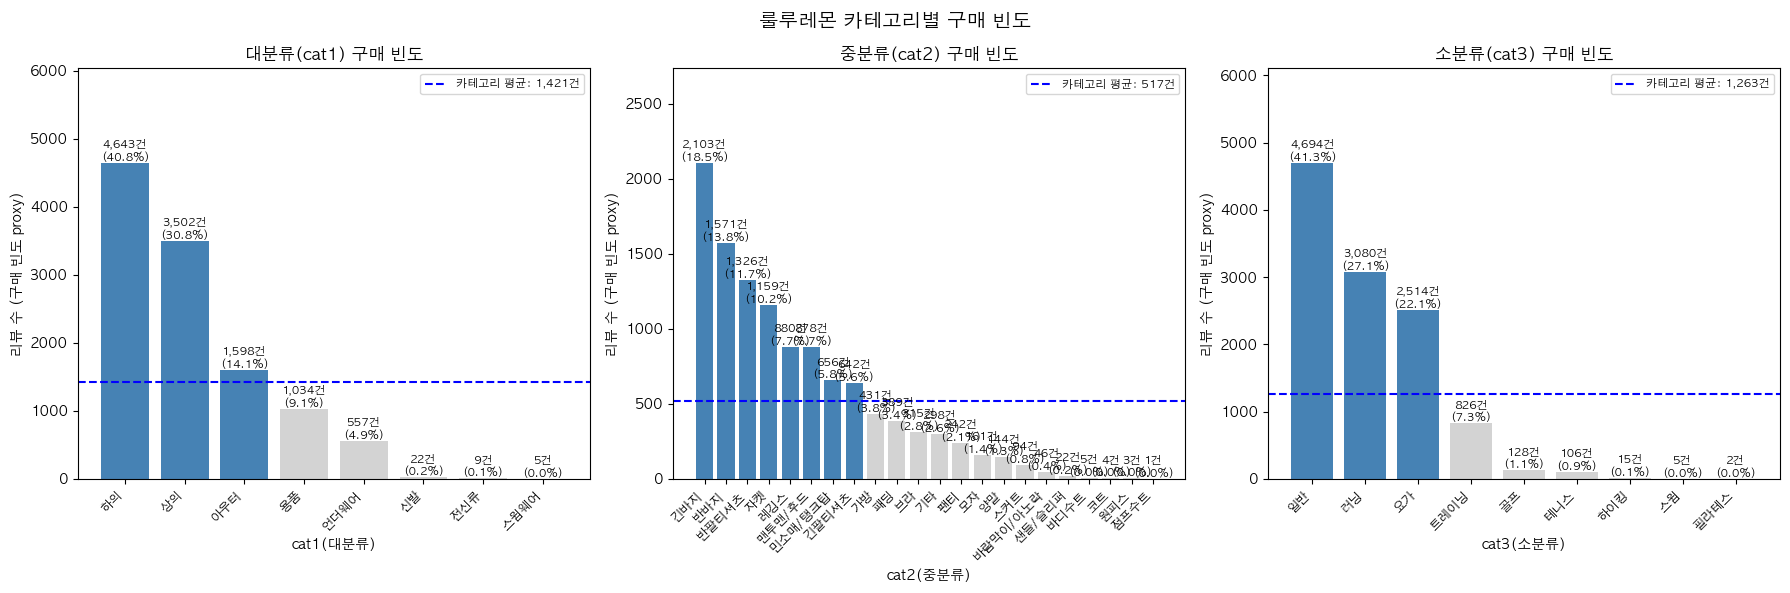

In [29]:
# ===============================
# cat1·cat2·cat3 구매 빈도 (전체)
# ===============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
total = len(df_lulu_review)

for ax, (cat_col, label) in zip(axes, [('cat1', '대분류'), ('cat2', '중분류'), ('cat3', '소분류')]):
    counts = (
        df_lulu_review
        .groupby(cat_col)
        .size()
        .sort_values(ascending=False)
    )
    overall_count_mean = counts.mean()
    colors = ['steelblue' if v >= overall_count_mean else 'lightgray' for v in counts.values]

    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.axhline(
        overall_count_mean,
        color='blue',
        linestyle='--',
        linewidth=1.5,
        label=f'카테고리 평균: {overall_count_mean:,.0f}건'
    )

    for bar in bars:
        height = bar.get_height()
        pct = height / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:,}건\n({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=8
        )

    # 바 위 텍스트(2줄)가 잘리지 않도록 y축 상단 여유 확보
    ax.set_ylim(0, counts.max() * 1.3)

    ax.set_title(f'{label}({cat_col}) 구매 빈도')
    ax.set_xlabel(f'{cat_col}({label})')
    ax.set_ylabel('리뷰 수 (구매 빈도 proxy)')

    # x축 레이블 겹침 방지
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=9)

    ax.legend(fontsize=8)

plt.suptitle('룰루레몬 카테고리별 구매 빈도', fontsize=14)
plt.tight_layout()
plt.show()

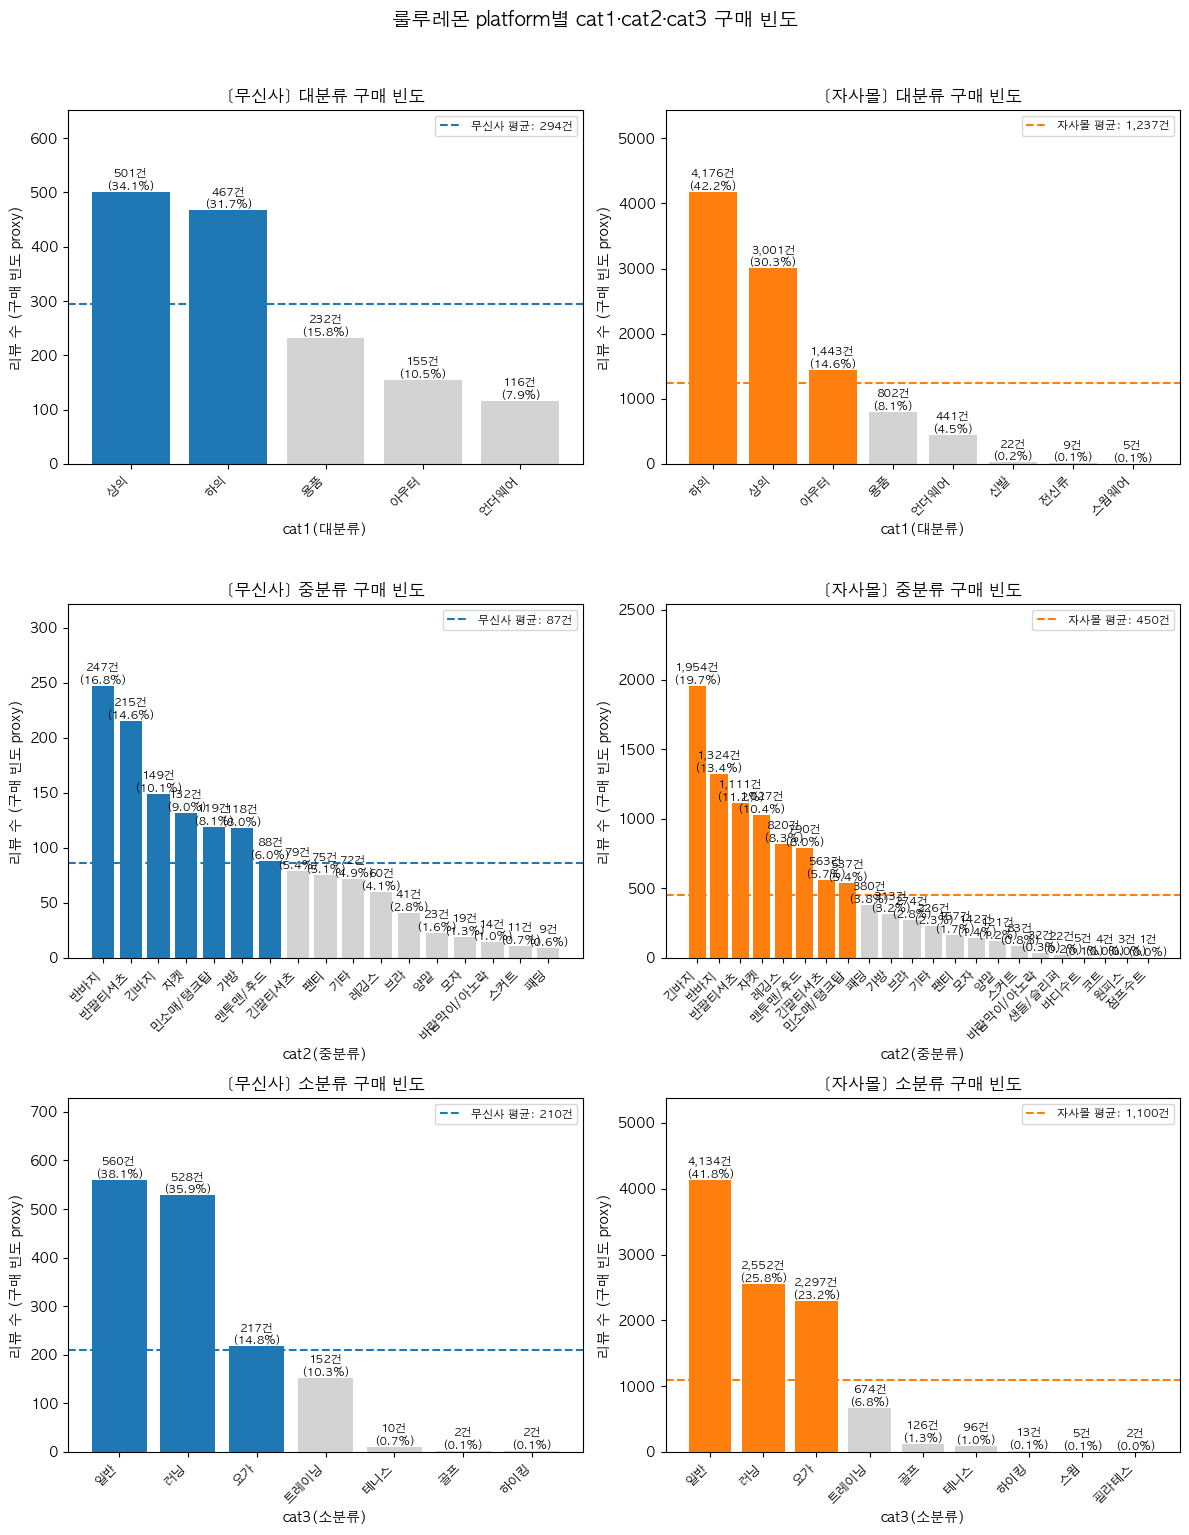

In [30]:
import matplotlib.pyplot as plt

# ===============================
# platform별 cat1·cat2·cat3 구매 빈도
# ===============================

platform_color_map = {
    '무신사': '#1f77b4',   # 파란색
    '자사몰': '#ff7f0e'    # 주황색
}

platform_list = sorted(df_lulu_review['platform'].unique())
n_platform = len(platform_list)

fig, axes = plt.subplots(3, n_platform, figsize=(6 * n_platform, 15))

if n_platform == 1:
    axes = axes.reshape(3, 1)

for col_idx, platform_val in enumerate(platform_list):
    df_sub = df_lulu_review[df_lulu_review['platform'] == platform_val]
    platform_total = len(df_sub)

    base_color = platform_color_map.get(platform_val, 'gray')

    for row_idx, (cat_col, label) in enumerate([
        ('cat1', '대분류'),
        ('cat2', '중분류'),
        ('cat3', '소분류')
    ]):
        ax = axes[row_idx][col_idx]

        counts = (
            df_sub
            .groupby(cat_col)
            .size()
            .sort_values(ascending=False)
        )

        platform_count_mean = counts.mean()

        # 🔥 평균 기준 색상 분기
        colors = [
            base_color if v >= platform_count_mean else 'lightgray'
            for v in counts.values
        ]

        bars = ax.bar(
            counts.index,
            counts.values,
            color=colors
        )

        # 평균선은 플랫폼 색상 유지
        ax.axhline(
            platform_count_mean,
            color=base_color,
            linestyle='--',
            linewidth=1.5,
            label=f'{platform_val} 평균: {platform_count_mean:,.0f}건'
        )

        # 값 + 비율 표시
        for bar in bars:
            height = bar.get_height()
            pct = height / platform_total * 100

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:,}건\n({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=8
            )

        ax.set_ylim(0, counts.max() * 1.3)

        ax.set_title(f'[{platform_val}] {label} 구매 빈도')
        ax.set_xlabel(f'{cat_col}({label})')
        ax.set_ylabel('리뷰 수 (구매 빈도 proxy)')

        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(
            counts.index,
            rotation=45,
            ha='right',
            fontsize=9
        )

        ax.legend(fontsize=8)

plt.suptitle(
    '룰루레몬 platform별 cat1·cat2·cat3 구매 빈도',
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

---
## 카테고리별 리뷰 단어 빈도 분석
- **분석 목적**: cat1 / cat2 / cat3 별로 리뷰 본문에서 자주 등장하는 단어를 추출해 각 카테고리 소비자가 어떤 표현·특징·불만을 많이 언급하는지 파악
- **방법**: 한국어 형태소 분석(Kiwi) → 명사·형용사 추출 → 단어 빈도 집계
- **보조 분석**: TF-IDF로 카테고리별 "차별적으로 자주 등장하는 단어" 추출

/Users/kimsunyeong/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/bin/python: No module named pip


✔ Kiwi 로드 완료 (tag 비교: str)
단어 빈도 집계 중... (수십 초 소요)
✔ 집계 완료: 195행
✔ 저장: ../data/lulu_category_word_freq.csv


,category_level,category_name,word,count,rank
0,cat1,상의,기능,324,1
1,cat1,상의,재질,300,2
2,cat1,상의,라인,290,3
3,cat1,상의,색깔,232,4
4,cat1,상의,원단,227,5
5,cat1,스윔웨어,리조트,4,1
6,cat1,스윔웨어,실내,3,2
7,cat1,스윔웨어,여행,3,3
8,cat1,스윔웨어,수영장,2,4
9,cat1,스윔웨어,길이,2,5


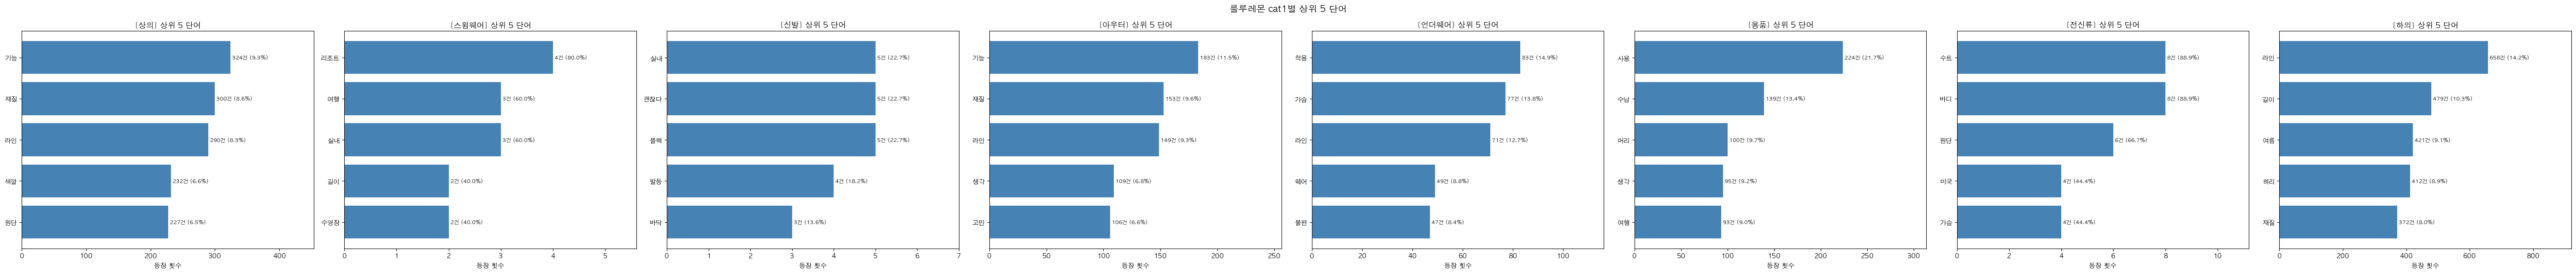


  cat1 카테고리별 상위 단어 텍스트 그래프

  [상의]
  기능       █████████████████████████ (324)
  재질       ███████████████████████   (300)
  라인       ██████████████████████    (290)
  색깔       █████████████████         (232)
  원단       █████████████████         (227)

  [스윔웨어]
  리조트      █████████████████████████ (4)
  실내       ██████████████████        (3)
  여행       ██████████████████        (3)
  수영장      ████████████              (2)
  길이       ████████████              (2)

  [신발]
  블랙       █████████████████████████ (5)
  괜찮다      █████████████████████████ (5)
  실내       █████████████████████████ (5)
  발등       ████████████████████      (4)
  바닥       ███████████████           (3)

  [아우터]
  기능       █████████████████████████ (183)
  재질       ████████████████████      (153)
  라인       ████████████████████      (149)
  생각       ██████████████            (109)
  고민       ██████████████            (106)

  [언더웨어]
  착용       █████████████████████████ (83)
  가슴       ███████████████████████   (77)
  라

In [ ]:
# ─────────────────────────────────────────────────────
# 카테고리별 리뷰 단어 빈도 분석
# (설치 → 전처리 → 형태소분석 → 빈도집계 → 시각화 → 텍스트그래프)
# ─────────────────────────────────────────────────────

import subprocess, sys, re, os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

subprocess.run([sys.executable, '-m', 'pip', 'install', 'kiwipiepy', '-q'], check=False)

# ── 설정 ──────────────────────────────────────────────
TOP_N     = 5
SAVE_PATH = '../data/lulu_category_word_freq.csv'
MAX_BAR   = 25

# ── 불용어 (확장) ──────────────────────────────────────
STOPWORDS = {
    # 조사·어미 파편
    '이', '가', '을', '를', '은', '는', '의', '에', '도', '로', '으로',
    '와', '과', '에서', '부터', '까지', '에게', '이랑', '랑', '나',
    # 의미 없는 동사·형용사
    '하', '하다', '합니다', '있', '있다', '있습니다', '되', '되다', '됩니다',
    '없', '없다', '없습니다', '같', '같다', '같습니다', '이다', '오다', '가다',
    '좋', '좋다', '좋습니다', '나쁘', '나쁘다', '나쁩니다',
    '크', '크다', '큽니다', '작', '작다', '작습니다', '입', '입다', '입습니다',
    '구매하다', '않', '않다', '않습니다', '신', '신다', '신습니다', '다르다', '다릅니다',
    '운동할때', '운동할 때', '운동',
    # 의존명사·불완전명사
    '것', '수', '때', '점', '분', '번', '거', '걸', '게', '데',
    '곳', '줄', '법', '만큼', '정도', '경우', '부분', '면', '때', '때도', '때나',
    # 지시어·대명사
    '이거', '그거', '저거', '이게', '그게', '저게', '여기', '거기',
    '이렇게', '그렇게', '이런', '그런', '저런',
    '제', '저', '나', '우리', '다들',
    # 시간·순서
    '이번', '저번', '처음', '다음', '마지막',
    # 부사
    '더', '너무', '정말', '진짜', '그냥', '좀', '잘', '많이', '매우',
    '아주', '완전', '약간', '조금', '살짝', '꽤', '한번', '다시',
    '또', '항상', '늘', '계속', '바로', '특히', '그리고', '하지만',
    '근데', '그런데', '그래서', '그러나', '생각보다',
    # 브랜드·쇼핑 관련
    '상품', '제품', '구매', '구입', '주문', '배송', '포장', '택배',
    '룰루레몬', 'lululemon', '리뷰', '후기', '추천', '비추',
    '재구매', '가격', '할인', '사이즈', '색상', '컬러',
    # 범용 형용사 (분석 의미 낮음)
    '좋다', '나쁘다', '예쁘다', '이쁘다',
    '크다', '작다', '많다', '적다', '높다', '낮다', "만족하다",
    # 기타 단음절·무의미
    '한', '그', '다', '안', '못', '및', '등', '전', '후',
    '내', '외', '중', '간', '상', '하', '각', '모든', '것같습니다', '것 같습니다',
    # 카테고리 공통 키워드 (전 카테고리에 고루 등장해 변별력 없음)
    '편하다', '편안', '만족', '소재', '가볍다', '부드럽다',
    '디자인', '핏이', '느낌', '착용감', '기준', '발을', '발에',
    '너무너무', '최고', '마음', '몸에', '다리',
    '속옷', '겨울', '슬리퍼',
    # 브랜드/시리즈/소재명
    "룰루레몬", "룰루", "레몬", "룰루 레몬", "lululemon", "Align", "Nulu", "Nulux", "Luon", "Luxtreme",
    "Everlux", "Warpstreme", "WovenAir", "Softstreme", "SmoothCover",
    "Ultralu", "Utilitech", "Rulu", "SenseKnit", "ShowZero",
    "ABC", "Restfeel", "Zero", "Tucks",
    # 대표 라인명
    "스쿠바", "스위프틀리", "디파인", "얼라인", "원더", "트레인",
    "패스트", "프리", "라이선스", "투", "트레인", "댄스", "스튜디오",
    "데이드리프트", "비캄", "소프트", "저지", "홀드", "타이트",
    "에너지", "클라우드", "라이크", "그루브", "뉴", "벤처",
    "에브리웨어", "에브리데이", "원더러스트", "인비지웨어",
    "올웨이즈", "스테디", "스테이트", "레스트필",
    # 제품 카테고리명
    "셔츠", "티셔츠", "탱크탑", "탱크", "롱슬리브", "숏슬리브",
    "슬리브리스", "브라", "브라탑", "팬츠", "바지", "타이츠",
    "레깅스", "조거", "쇼츠", "스커트", "원피스", "드레스",
    "자켓", "재킷", "후디", "후드", "풀집", "하프집", "크루넥",
    "폴로", "트라우저", "카디건", "베스트", "패딩", "코트",
    "파카", "점프수트", "바디수트", "언더웨어", "팬티", "박서",
    "브리프", "삭스", "양말", "모자", "캡", "햇", "비니",
    "바이저", "헤드밴드", "백팩", "토트백", "숄더백", "슬링백",
    "벨트백", "크로스바디", "파우치", "더플백", "보틀", "텀블러",
    "매트", "타월", "슬라이드", "글러브", '가방',
    # 핏/기장/형태
    "핏", "슬림", "클래식", "릴랙스", "릴랙스드", "오버사이즈드",
    "와이드", "스트레이트", "플레어드", "크롭", "미드라이즈",
    "하이라이즈", "슈퍼", "웨이스트", "렝스", "힙", "레귤러",
    "쇼터", "아시아", "업데이트", "업데이티드", "롱라인",
    "하이넥", "스쿱넥", "스퀘어넥", "브이넥", "레이서백",
    "스트래피", "스트랩", "스파게티", "프런트", "백", "크루",
    "넥", "후드", "카라", "칼라드", "집업", "신치", "풀온",
    "패커블", "컨버터블", "리버서블", "투인원", "쓰리인원",
    # 기능/용도
    "러닝", "요가", "골프", "테니스", "트레이닝", "하이킹", '수영',
    "워크아웃", "스포츠", "퍼포먼스", "UV", "프로텍티브",
    "워터프루프", "워터", "리펠런트", "라이트웨이트",
    "윈드브레이커", "다운", "인설레이티드", "서멀", "쿨링",
    "브리더블", "메쉬", "벤틸레이티드", "퍼포레이티드",
    "리플렉티브", "하이", "미디엄", "라이트", "서포트",
    # 컬렉션/기획성 단어
    "루나", "이어", "SLNSH", "컬렉션", "프라이드", "워드마크",
    "로고", "그래픽", "테크", "캔버스", "메탈", "하드웨어",
    "스트라이프", "리브드", "브러시드", "피케", "트윌",
    "나일론", "코튼", "울", "플리스", "저지", "립스탑",
    "새틴", "메쉬", "니트", "실크어필", "실키어필",a
    # 사이즈/스펙 표현
    "A컵", "B컵", "C컵", "D컵", "DD컵", "DDD컵", "컵",
    "아시아핏", "레귤러핏", "업데이트핏",
    "L", "oz", "mm", "팩", "로고", "워드마크"
}

# ── 형태소 분석기 로드 ─────────────────────────────────
try:
    from kiwipiepy import Kiwi
    _kiwi    = Kiwi()
    USE_KIWI = True
    # 태그 비교 방식 확인 (버전별 차이 대응)
    _test    = _kiwi.tokenize('테스트')
    _tag_key = 'name' if hasattr(_test[0].tag, 'name') else 'str'
    print(f"✔ Kiwi 로드 완료 (tag 비교: {_tag_key})")
except Exception:
    USE_KIWI = False
    print("⚠ Kiwi 없음 → fallback 모드 (정규식 + 어미 제거)")

# 명사 + 형용사로 확장
TARGET_TAGS = {'NNG', 'NNP', 'VA'}

def _tag_str(tag) -> str:
    """kiwipiepy 버전 무관하게 태그 문자열 반환"""
    return tag.name if hasattr(tag, 'name') else str(tag)

# ── 전처리 ─────────────────────────────────────────────
def preprocess(text: str) -> str:
    text = str(text)
    text = re.sub(r'[^\w\s가-힣]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# ── 토크나이저 ─────────────────────────────────────────
def tokenize(text: str) -> list:
    text = preprocess(text)
    if USE_KIWI:
        words = []
        for t in _kiwi.tokenize(text):
            if _tag_str(t.tag) in TARGET_TAGS and len(t.form) > 1:
                lemma = getattr(t, 'lemma', t.form)  # lemma 우선 사용
                words.append(lemma)
    else:
        words = re.findall(r'[가-힣]{2,}', text)

    return [w for w in words if len(w) > 1 and w not in STOPWORDS]

# ── 카테고리별 단어 빈도 집계 ──────────────────────────
def build_word_freq(df: pd.DataFrame, cat_col: str) -> pd.DataFrame:
    records = []
    for cat_name, group in df.groupby(cat_col):
        all_words = []
        for text in group['content']:
            all_words.extend(tokenize(text))
        for rank, (word, count) in enumerate(Counter(all_words).most_common(TOP_N), 1):
            records.append({
                'category_level': cat_col,
                'category_name' : cat_name,
                'word'          : word,
                'count'         : count,
                'rank'          : rank,
            })
    return pd.DataFrame(records)

print("단어 빈도 집계 중... (수십 초 소요)")
df_cat1_freq = build_word_freq(df_lulu_review, 'cat1')
df_cat2_freq = build_word_freq(df_lulu_review, 'cat2')
df_cat3_freq = build_word_freq(df_lulu_review, 'cat3')
df_word_freq = pd.concat([df_cat1_freq, df_cat2_freq, df_cat3_freq], ignore_index=True)
print(f"✔ 집계 완료: {len(df_word_freq)}행")

os.makedirs(os.path.dirname(os.path.abspath(SAVE_PATH)), exist_ok=True)
df_word_freq.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
print(f"✔ 저장: {SAVE_PATH}")
display(df_word_freq.head(20))

# ── 시각화: cat1 상위 단어 가로 barplot ───────────────
cat1_list = df_cat1_freq['category_name'].unique()
n         = len(cat1_list)

fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for ax, cat_name in zip(axes, cat1_list):
    sub   = df_cat1_freq[df_cat1_freq['category_name'] == cat_name].sort_values('count')
    total = df_lulu_review[df_lulu_review['cat1'] == cat_name]['content'].count()

    bars = ax.barh(sub['word'], sub['count'], color='steelblue')
    for bar in bars:
        w   = bar.get_width()
        pct = w / total * 100
        ax.text(
            w, bar.get_y() + bar.get_height() / 2,
            f' {w:,}건 ({pct:.1f}%)',
            va='center', fontsize=8,
        )

    ax.set_xlim(0, sub['count'].max() * 1.4)
    ax.set_title(f'[{cat_name}] 상위 {TOP_N} 단어')
    ax.set_xlabel('등장 횟수')

plt.suptitle(f'룰루레몬 cat1별 상위 {TOP_N} 단어', fontsize=14)
plt.tight_layout()
plt.show()

# ── 텍스트 그래프 출력 ─────────────────────────────────
def print_text_bar(df_freq: pd.DataFrame, cat_col: str):
    print(f"\n{'='*52}")
    print(f"  {cat_col} 카테고리별 상위 단어 텍스트 그래프")
    print(f"{'='*52}")
    for cat_name, group in df_freq.groupby('category_name'):
        print(f"\n  [{cat_name}]")
        max_count = group['count'].max()
        for _, row in group.sort_values('count', ascending=False).iterrows():
            bar_len = int(row['count'] / max_count * MAX_BAR)
            print(f"  {row['word']:<8} {'█' * bar_len:<{MAX_BAR}} ({row['count']:,})")

print_text_bar(df_cat1_freq, 'cat1')
print_text_bar(df_cat2_freq, 'cat2')
print_text_bar(df_cat3_freq, 'cat3')

/Users/kimsunyeong/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/bin/python: No module named pip


✔ Kiwi 로드 완료 (tag 비교: str)
단어 빈도 집계 중...
✔ 집계 완료


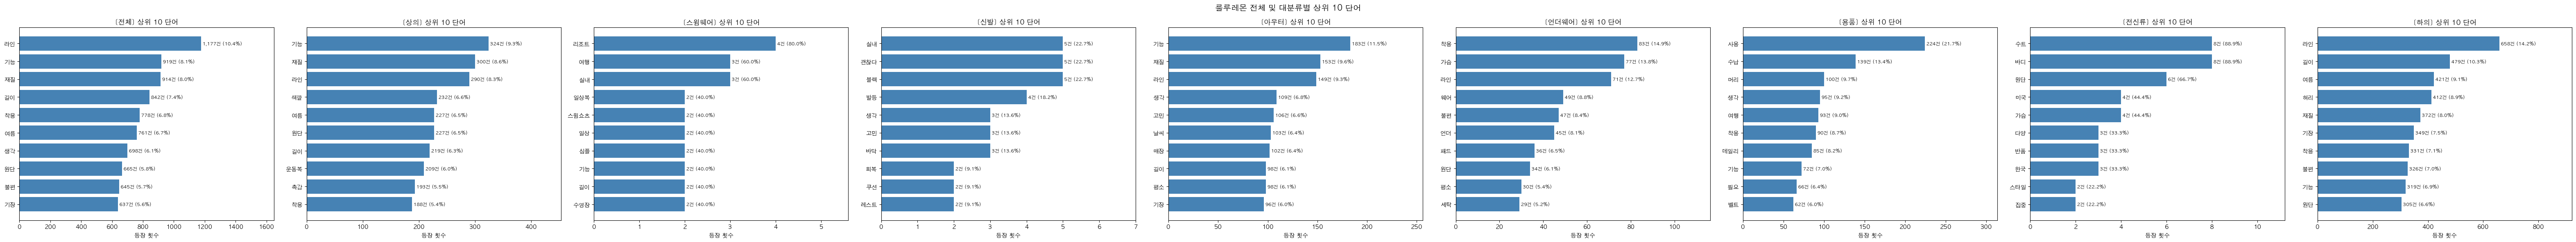


  [전체] 상위 10 단어
  라인       █████████████████████████ (1,177)
  기능       ███████████████████       (919)
  재질       ███████████████████       (914)
  길이       █████████████████         (842)
  착용       ████████████████          (778)
  여름       ████████████████          (761)
  생각       ██████████████            (698)
  원단       ██████████████            (665)
  불편       █████████████             (645)
  기장       █████████████             (637)

  [상의] 상위 10 단어
  기능       █████████████████████████ (324)
  재질       ███████████████████████   (300)
  라인       ██████████████████████    (290)
  색깔       █████████████████         (232)
  원단       █████████████████         (227)
  여름       █████████████████         (227)
  길이       ████████████████          (219)
  운동복      ████████████████          (209)
  촉감       ██████████████            (193)
  착용       ██████████████            (188)

  [스윔웨어] 상위 10 단어
  리조트      █████████████████████████ (4)
  실내       ██████████████████        (3)
  여

In [80]:
# ─────────────────────────────────────────────────────
# 리뷰 단어 빈도 분석
# ─────────────────────────────────────────────────────

import subprocess, sys, re, os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

subprocess.run([sys.executable, '-m', 'pip', 'install', 'kiwipiepy', '-q'], check=False)

# ── 설정 ──────────────────────────────────────────────
TOP_N     = 10  # 전체/대분류 모두 상위 10개
SAVE_PATH = '../data/lulu_word_freq.csv'
MAX_BAR   = 25

# ── 불용어 ──────────────────────────────────────────────
# STOPWORDS

# ── 형태소 분석기 로드 ─────────────────────────────────
try:
    from kiwipiepy import Kiwi
    _kiwi    = Kiwi()
    USE_KIWI = True
    _test    = _kiwi.tokenize('테스트')
    _tag_key = 'name' if hasattr(_test[0].tag, 'name') else 'str'
    print(f"✔ Kiwi 로드 완료 (tag 비교: {_tag_key})")
except Exception:
    USE_KIWI = False
    print("⚠ Kiwi 없음 → fallback 모드")

TARGET_TAGS = {'NNG', 'NNP', 'VA'}

def _tag_str(tag) -> str:
    return tag.name if hasattr(tag, 'name') else str(tag)

def preprocess(text: str) -> str:
    text = str(text)
    text = re.sub(r'[^\w\s가-힣]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def tokenize(text: str) -> list:
    text = preprocess(text)
    if USE_KIWI:
        words = []
        for t in _kiwi.tokenize(text):
            if _tag_str(t.tag) in TARGET_TAGS and len(t.form) > 1:
                lemma = getattr(t, 'lemma', t.form)
                words.append(lemma)
    else:
        words = re.findall(r'[가-힣]{2,}', text)
    return [w for w in words if len(w) > 1 and w not in STOPWORDS]

# ── 전체 단어 빈도 집계 ────────────────────────────────
print("단어 빈도 집계 중...")

# 전체
all_words = []
for text in df_lulu_review['content']:
    all_words.extend(tokenize(text))
counter_all = Counter(all_words)

# 대분류(cat1)별
cat1_counters = {}
for cat_name, group in df_lulu_review.groupby('cat1'):
    words = []
    for text in group['content']:
        words.extend(tokenize(text))
    cat1_counters[cat_name] = Counter(words)

print("✔ 집계 완료")

# ── 시각화 ─────────────────────────────────────────────
cat1_list = list(cat1_counters.keys())
n_cats    = len(cat1_list)

# 전체 + 대분류 서브플롯
fig, axes = plt.subplots(1, n_cats + 1, figsize=(7 * (n_cats + 1), 6))

# (1) 전체
top_all = counter_all.most_common(TOP_N)
words_all, counts_all = zip(*top_all)
sub_df = pd.DataFrame({'word': words_all, 'count': counts_all}).sort_values('count')
total = len(df_lulu_review)
bars = axes[0].barh(sub_df['word'], sub_df['count'], color='steelblue')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w, bar.get_y() + bar.get_height() / 2,
                 f' {w:,}건 ({w/total*100:.1f}%)', va='center', fontsize=8)
axes[0].set_xlim(0, sub_df['count'].max() * 1.4)
axes[0].set_title(f'[전체] 상위 {TOP_N} 단어')
axes[0].set_xlabel('등장 횟수')

# (2) 대분류별
for i, cat_name in enumerate(cat1_list):
    ax = axes[i + 1]
    top_n = cat1_counters[cat_name].most_common(TOP_N)
    if not top_n:
        ax.set_visible(False)
        continue
    words_n, counts_n = zip(*top_n)
    sub_df = pd.DataFrame({'word': words_n, 'count': counts_n}).sort_values('count')
    cat_total = len(df_lulu_review[df_lulu_review['cat1'] == cat_name])
    bars = ax.barh(sub_df['word'], sub_df['count'], color='steelblue')
    for bar in bars:
        w = bar.get_width()
        ax.text(w, bar.get_y() + bar.get_height() / 2,
                f' {w:,}건 ({w/cat_total*100:.1f}%)', va='center', fontsize=8)
    ax.set_xlim(0, sub_df['count'].max() * 1.4)
    ax.set_title(f'[{cat_name}] 상위 {TOP_N} 단어')
    ax.set_xlabel('등장 횟수')

plt.suptitle(f'룰루레몬 전체 및 대분류별 상위 {TOP_N} 단어', fontsize=14)
plt.tight_layout()
plt.show()

# ── 텍스트 그래프 출력 ─────────────────────────────────
print(f"\n{'='*52}")
print(f"  [전체] 상위 {TOP_N} 단어")
print(f"{'='*52}")
max_c = counter_all.most_common(1)[0][1]
for word, cnt in counter_all.most_common(TOP_N):
    bar_len = int(cnt / max_c * MAX_BAR)
    print(f"  {word:<8} {'█' * bar_len:<{MAX_BAR}} ({cnt:,})")

for cat_name, counter in cat1_counters.items():
    print(f"\n{'='*52}")
    print(f"  [{cat_name}] 상위 {TOP_N} 단어")
    print(f"{'='*52}")
    max_c = counter.most_common(1)[0][1]
    for word, cnt in counter.most_common(TOP_N):
        bar_len = int(cnt / max_c * MAX_BAR)
        print(f"  {word:<8} {'█' * bar_len:<{MAX_BAR}} ({cnt:,})")

In [79]:
# ─────────────────────────────────────────────────────
# TF-IDF 기반 카테고리별 특징 단어 추출
# (단순 빈도가 높은 단어가 아니라, 해당 카테고리에서만 두드러지는 단어 탐지)
# ─────────────────────────────────────────────────────
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-learn', '-q'], check=False)
from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_SAVE_PATH = '../data/lulu_category_tfidf.csv'

def build_tfidf_keywords(df, cat_col, top_n=TOP_N):
    # 카테고리별 리뷰를 하나의 문서로 합침
    cat_docs = (
        df.groupby(cat_col)['content']
        .apply(lambda texts: ' '.join(preprocess(str(t)) for t in texts))
    )
    vec = TfidfVectorizer(
        tokenizer=tokenize,
        token_pattern=None,
        max_features=5000,
    )
    tfidf_matrix  = vec.fit_transform(cat_docs)
    feature_names = vec.get_feature_names_out()

    records = []
    for idx, cat_name in enumerate(cat_docs.index):
        scores    = tfidf_matrix[idx].toarray().flatten()
        top_idx   = scores.argsort()[::-1][:top_n]
        for rank, i in enumerate(top_idx, 1):
            if scores[i] > 0:
                records.append({
                    'category_level': cat_col,
                    'category_name' : cat_name,
                    'word'          : feature_names[i],
                    'tfidf_score'   : round(float(scores[i]), 4),
                    'rank'          : rank,
                })
    return pd.DataFrame(records)

print("TF-IDF 분석 중...")
df_tfidf_cat1 = build_tfidf_keywords(df_lulu_review, 'cat1')
df_tfidf_cat2 = build_tfidf_keywords(df_lulu_review, 'cat2')
df_tfidf_cat3 = build_tfidf_keywords(df_lulu_review, 'cat3')
df_tfidf = pd.concat([df_tfidf_cat1, df_tfidf_cat2, df_tfidf_cat3], ignore_index=True)

df_tfidf.to_csv(TFIDF_SAVE_PATH, index=False, encoding='utf-8-sig')
print(f"✔ TF-IDF 저장 완료: {TFIDF_SAVE_PATH}")
display(df_tfidf.head(30))

# ── TF-IDF 텍스트 그래프 ───────────────────────────────
def print_tfidf_bar(df_tfidf_all, cat_col):
    sub = df_tfidf_all[df_tfidf_all['category_level'] == cat_col]
    print(f"\n{'='*52}")
    print(f"  {cat_col} TF-IDF 특징 단어 텍스트 그래프")
    print(f"{'='*52}")
    for cat_name, group in sub.groupby('category_name'):
        print(f"\n  [{cat_name}]")
        max_score = group['tfidf_score'].max()
        for _, row in group.sort_values('tfidf_score', ascending=False).iterrows():
            bar_len = int(row['tfidf_score'] / max_score * MAX_BAR)
            bar     = '█' * bar_len
            print(f"  {row['word']:<8} {bar:<{MAX_BAR}} ({row['tfidf_score']:.4f})")

print_tfidf_bar(df_tfidf, 'cat1')
print_tfidf_bar(df_tfidf, 'cat2')
print_tfidf_bar(df_tfidf, 'cat3')

/Users/kimsunyeong/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/bin/python: No module named pip


TF-IDF 분석 중...
✔ TF-IDF 저장 완료: ../data/lulu_category_tfidf.csv


,category_level,category_name,word,tfidf_score,rank
0,cat1,상의,기능,0.2239,1
1,cat1,상의,라인,0.2228,2
2,cat1,상의,색깔,0.2016,3
3,cat1,상의,재질,0.1855,4
4,cat1,상의,원단,0.1756,5
5,cat1,스윔웨어,리조트,0.5670,1
6,cat1,스윔웨어,스윔쇼츠,0.2835,2
7,cat1,스윔웨어,실내,0.2125,3
8,cat1,스윔웨어,동남아,0.2050,4
9,cat1,스윔웨어,수영장,0.2050,5



  cat1 TF-IDF 특징 단어 텍스트 그래프

  [상의]
  기능       █████████████████████████ (0.2239)
  라인       ████████████████████████  (0.2228)
  색깔       ██████████████████████    (0.2016)
  재질       ████████████████████      (0.1855)
  원단       ███████████████████       (0.1756)

  [스윔웨어]
  리조트      █████████████████████████ (0.5670)
  스윔쇼츠     ████████████              (0.2835)
  실내       █████████                 (0.2125)
  동남아      █████████                 (0.2050)
  수영장      █████████                 (0.2050)

  [신발]
  발등       █████████████████████████ (0.2816)
  실내       █████████████████████     (0.2432)
  블랙       ███████████████████       (0.2172)
  제니       █████████████████         (0.1947)
  레스트      █████████████████         (0.1947)

  [아우터]
  기능       █████████████████████████ (0.2530)
  라인       ██████████████████████    (0.2306)
  재질       ██████████████████        (0.1880)
  매장       █████████████████         (0.1773)
  기장       ████████████████          (0.1669)

  [언더웨어]
  가슴  

---
## 부정리뷰 키워드 분석
- **목적**: 평점 1~2점 리뷰에서 자주 등장하는 단어를 추출해 고객 불만 포인트(페인포인트) 파악
- **분석 단위**: ① 브랜드 전체 ② cat1(대분류)별
> ⚠ 위 단어 빈도 분석 셀(`tokenize`, `STOPWORDS` 등)을 먼저 실행해야 합니다.

부정리뷰(rating≤2): 152건 / 전체 11,370건 (1.3%)

[cat1별 부정리뷰 분포]
  상의: 61건 (40.1%)
  하의: 42건 (27.6%)
  아우터: 20건 (13.2%)
  용품: 18건 (11.8%)
  언더웨어: 10건 (6.6%)
  전신류: 1건 (0.7%)

키워드 집계 중...
✔ 고유 단어: 627개 / 총 등장: 1,408회


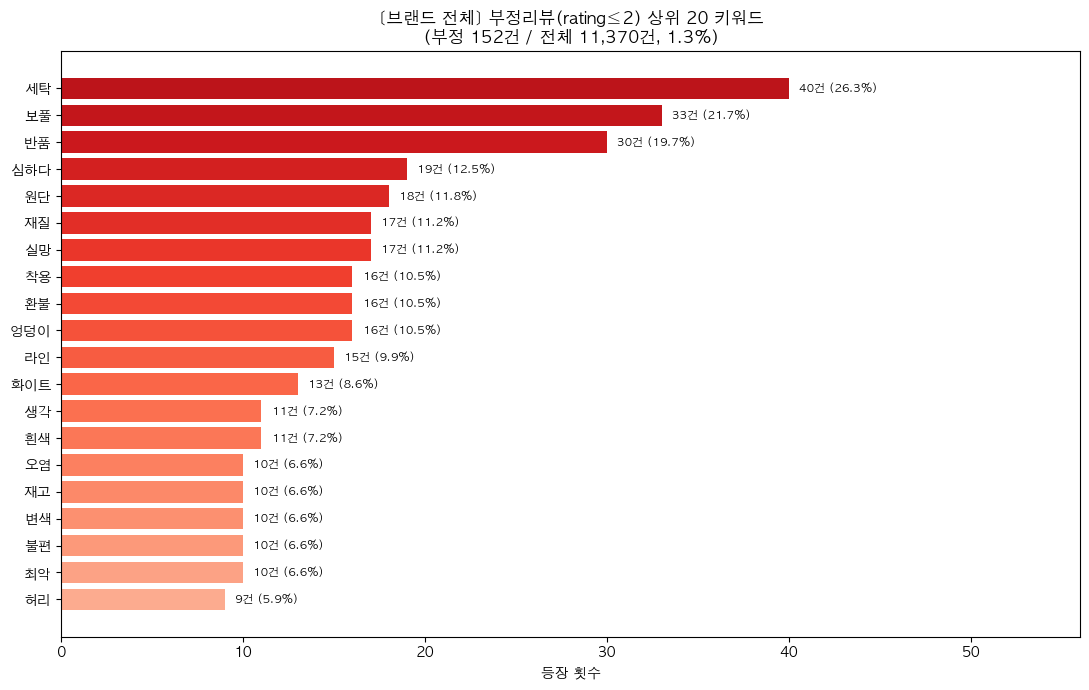

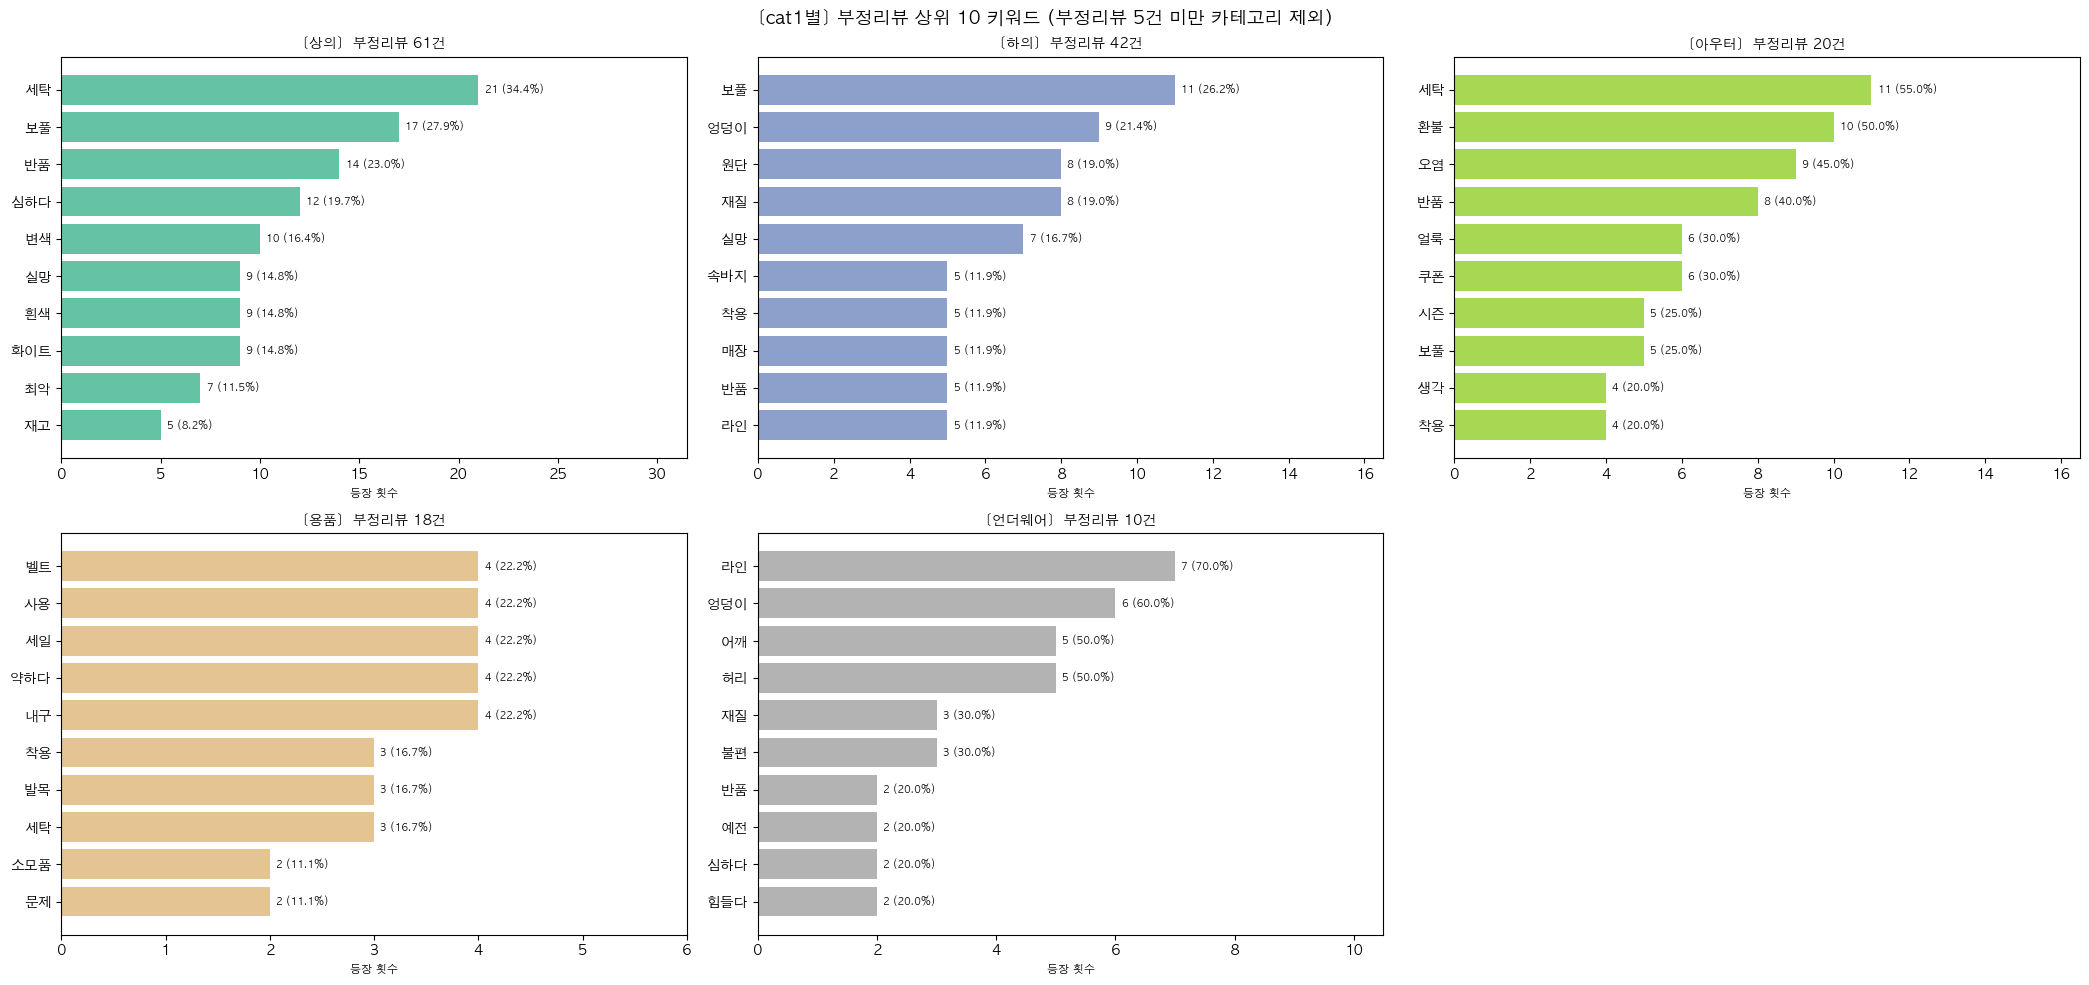

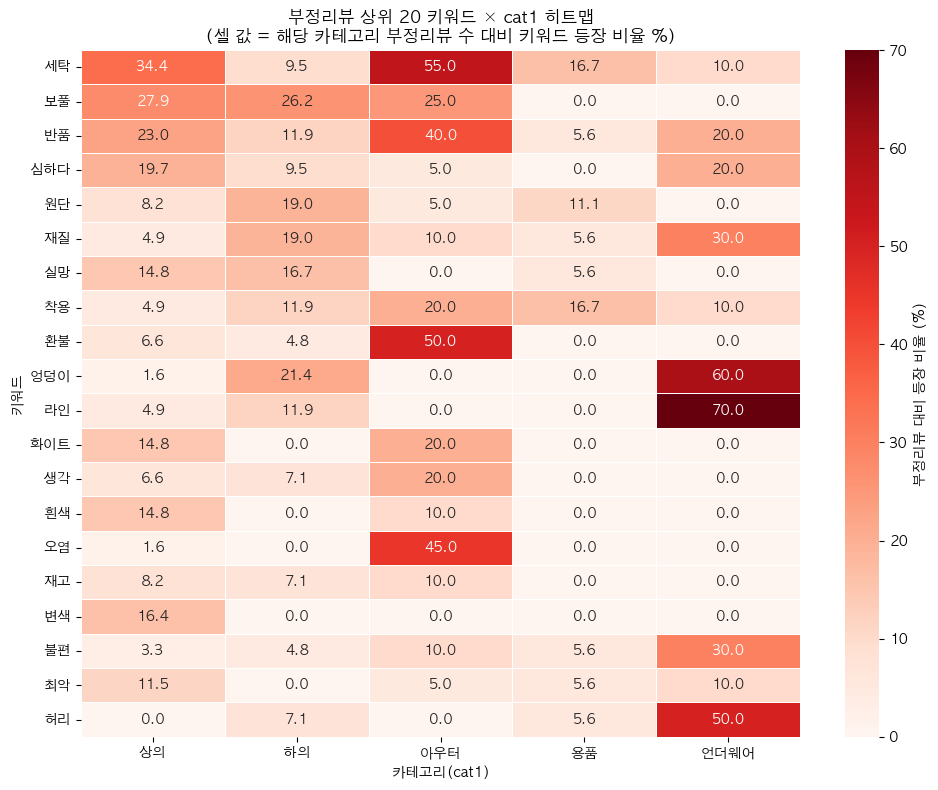


  브랜드 전체 부정리뷰 Top10 키워드
   1. 세탁       ██████████████████████████████ 40회 (26.3%)
   2. 보풀       ████████████████████████       33회 (21.7%)
   3. 반품       ██████████████████████         30회 (19.7%)
   4. 심하다      ██████████████                 19회 (12.5%)
   5. 원단       █████████████                  18회 (11.8%)
   6. 재질       ████████████                   17회 (11.2%)
   7. 실망       ████████████                   17회 (11.2%)
   8. 착용       ████████████                   16회 (10.5%)
   9. 환불       ████████████                   16회 (10.5%)
  10. 엉덩이      ████████████                   16회 (10.5%)


In [81]:
# ─────────────────────────────────────────────────────
# 부정리뷰 키워드 분석
# → rating ≤ 2 리뷰에서 Kiwi 명사 추출 → 브랜드 전체 + cat1별 시각화
# ─────────────────────────────────────────────────────
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

NEG_RATING  = 2
TOP_ALL     = 20   # 전체 브랜드 표시 개수
TOP_CAT     = 10   # 카테고리별 표시 개수
MIN_NEG_CNT = 5    # 카테고리별 부정리뷰 최소 건수 (미달 시 제외)

# 부정리뷰 필터링
df_neg = df_lulu_review[
    (df_lulu_review['rating'] <= NEG_RATING) &
    df_lulu_review['content'].notna()
].copy()
total_rev = len(df_lulu_review)
total_neg = len(df_neg)
print(f'부정리뷰(rating≤{NEG_RATING}): {total_neg:,}건 / 전체 {total_rev:,}건 ({total_neg/total_rev*100:.1f}%)')

# cat1별 부정리뷰 분포 출력
cat1_neg_dist = df_neg['cat1'].value_counts()
print('\n[cat1별 부정리뷰 분포]')
for cat, n in cat1_neg_dist.items():
    print(f'  {cat}: {n}건 ({n/total_neg*100:.1f}%)')

# ── 전체 키워드 집계
print('\n키워드 집계 중...')
all_neg_words = []
for text in df_neg['content']:
    all_neg_words.extend(tokenize(text))
neg_counter = Counter(all_neg_words)
print(f'✔ 고유 단어: {len(neg_counter):,}개 / 총 등장: {sum(neg_counter.values()):,}회')

# ── cat1별 키워드 집계 (최소 건수 이상 카테고리만)
cat1_valid = [c for c, n in cat1_neg_dist.items() if n >= MIN_NEG_CNT]
cat1_neg_counters = {}
for cat in cat1_valid:
    words = []
    for text in df_neg[df_neg['cat1']==cat]['content']:
        words.extend(tokenize(text))
    cat1_neg_counters[cat] = Counter(words)

# ═══════════════════════════════════════════════════════
# [Fig1] 브랜드 전체 부정리뷰 Top N 키워드
# ═══════════════════════════════════════════════════════
top_all = neg_counter.most_common(TOP_ALL)
w_all, c_all = zip(*top_all) if top_all else ([], [])

fig, ax = plt.subplots(figsize=(11, 7))
colors_bar = plt.cm.Reds_r(np.linspace(0.2, 0.7, len(w_all)))
bars = ax.barh(list(w_all)[::-1], list(c_all)[::-1], color=colors_bar[::-1])
xlim = max(c_all) * 1.40
ax.set_xlim(0, xlim)
ax.set_title(
    f'[브랜드 전체] 부정리뷰(rating≤{NEG_RATING}) 상위 {TOP_ALL} 키워드\n'
    f'(부정 {total_neg:,}건 / 전체 {total_rev:,}건, {total_neg/total_rev*100:.1f}%)',
    fontsize=12)
ax.set_xlabel('등장 횟수')
for bar in bars:
    w = bar.get_width()
    pct = w / total_neg * 100
    ax.text(w + xlim*0.01, bar.get_y()+bar.get_height()/2,
            f'{w:,}건 ({pct:.1f}%)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# [Fig2] cat1별 부정리뷰 Top N 키워드
# ═══════════════════════════════════════════════════════
n_cats = len(cat1_valid)
ncols  = min(n_cats, 3)
nrows  = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes_flat = np.array(axes).flatten()
fig.suptitle(f'[cat1별] 부정리뷰 상위 {TOP_CAT} 키워드 (부정리뷰 {MIN_NEG_CNT}건 미만 카테고리 제외)',
             fontsize=13, fontweight='bold')

cat1_colors = plt.cm.Set2(np.linspace(0,1,n_cats))
for i, cat in enumerate(cat1_valid):
    ax = axes_flat[i]
    cnt = cat1_neg_counters[cat]
    neg_n = cat1_neg_dist[cat]
    top_n = cnt.most_common(TOP_CAT)
    if not top_n:
        ax.set_visible(False)
        continue
    w_list, c_list = zip(*top_n)
    bars = ax.barh(list(w_list)[::-1], list(c_list)[::-1], color=cat1_colors[i])
    xlim_c = max(c_list) * 1.50
    ax.set_xlim(0, xlim_c)
    ax.set_title(f'[{cat}]  부정리뷰 {neg_n}건', fontsize=10)
    ax.set_xlabel('등장 횟수', fontsize=8)
    for bar in bars:
        w = bar.get_width()
        pct = w / neg_n * 100
        ax.text(w + xlim_c*0.01, bar.get_y()+bar.get_height()/2,
                f'{w:,} ({pct:.1f}%)', va='center', fontsize=7)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# [Fig3] 키워드 × cat1 히트맵
# → 전체 상위 20 키워드가 각 카테고리의 부정리뷰에서 차지하는 비율(%)
# ═══════════════════════════════════════════════════════
top20_words = [w for w, _ in neg_counter.most_common(TOP_ALL)]
hm_data = {}
for cat in cat1_valid:
    neg_n = cat1_neg_dist[cat]
    hm_data[cat] = [cat1_neg_counters[cat].get(w, 0) / neg_n * 100 for w in top20_words]
df_hm = pd.DataFrame(hm_data, index=top20_words)

fig, ax = plt.subplots(figsize=(max(10, len(cat1_valid)*2), 8))
sns.heatmap(df_hm, annot=True, fmt='.1f', cmap='Reds', ax=ax,
            linewidths=0.5, cbar_kws={'label': '부정리뷰 대비 등장 비율 (%)'})
ax.set_title(
    f'부정리뷰 상위 {TOP_ALL} 키워드 × cat1 히트맵\n'
    '(셀 값 = 해당 카테고리 부정리뷰 수 대비 키워드 등장 비율 %)',
    fontsize=12)
ax.set_xlabel('카테고리(cat1)'); ax.set_ylabel('키워드')
plt.tight_layout()
plt.show()

# ── 텍스트 요약 출력
print(f'\n{'='*55}')
print('  브랜드 전체 부정리뷰 Top10 키워드')
print(f'{'='*55}')
max_c = neg_counter.most_common(1)[0][1]
for rank, (word, cnt) in enumerate(neg_counter.most_common(10), 1):
    bar_len = int(cnt / max_c * 30)
    print(f'  {rank:2}. {word:<8} {"█"*bar_len:<30} {cnt:,}회 ({cnt/total_neg*100:.1f}%)')


---
# 클로드 자동 분석

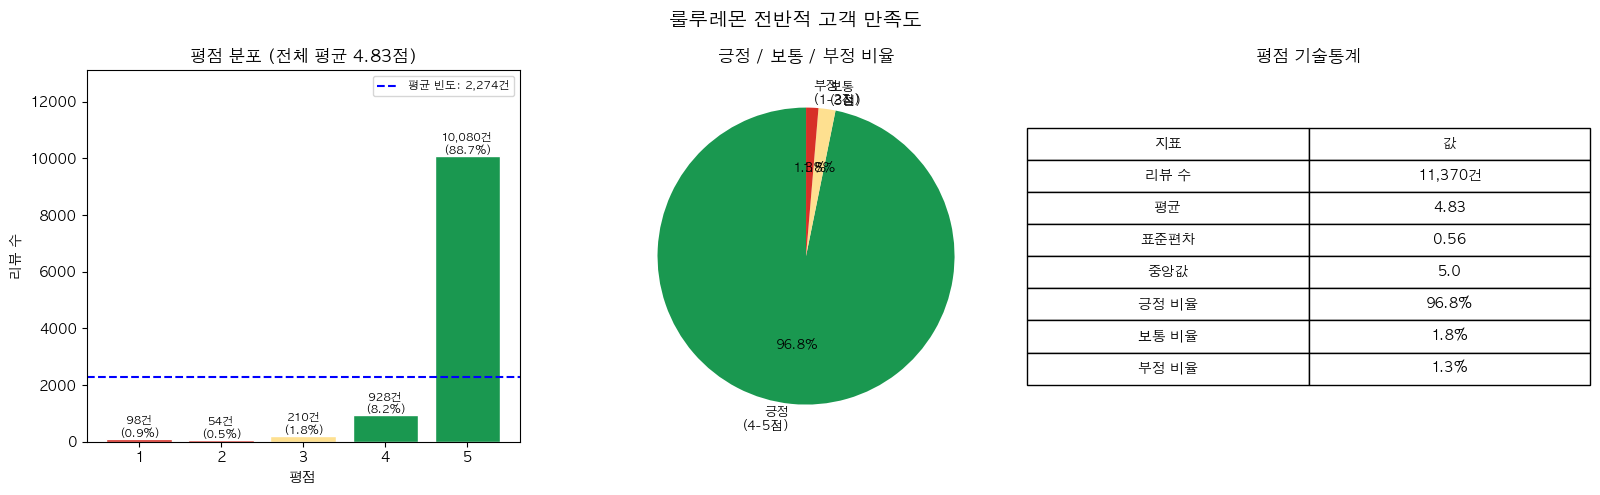

In [33]:
# ─────────────────────────────────────────────────────
# [1-1] 전반적 고객 만족도: 평점 분포 & 긍/부정 비율
# → 룰루레몬 전체 리뷰에서 고객이 얼마나 만족하는지 파악
# ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
overall_mean  = df_lulu_review['rating'].mean()
total         = len(df_lulu_review)
rating_counts = df_lulu_review['rating'].value_counts().sort_index()

# (1) 평점별 리뷰 수 막대
bar_colors = ['#d73027' if r <= 2 else '#fee090' if r == 3 else '#1a9850'
              for r in rating_counts.index]
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='white')
axes[0].axhline(rating_counts.mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f'평균 빈도: {rating_counts.mean():,.0f}건')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:,}건\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0, rating_counts.max() * 1.3)
axes[0].set_xticks(rating_counts.index)
axes[0].set_title(f'평점 분포 (전체 평균 {overall_mean:.2f}점)')
axes[0].set_xlabel('평점')
axes[0].set_ylabel('리뷰 수')
axes[0].legend(fontsize=8)

# (2) 긍/보통/부정 파이차트
pos = (df_lulu_review['rating'] >= 4).sum()
neu = (df_lulu_review['rating'] == 3).sum()
neg = (df_lulu_review['rating'] <= 2).sum()
axes[1].pie([pos, neu, neg],
            labels=[f'긍정\n(4-5점)', f'보통\n(3점)', f'부정\n(1-2점)'],
            autopct='%1.1f%%', colors=['#1a9850', '#fee090', '#d73027'],
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title('긍정 / 보통 / 부정 비율')

# (3) 기술통계 테이블
axes[2].axis('off')
stats = df_lulu_review['rating'].describe()
rows  = [['리뷰 수', f"{int(stats['count']):,}건"],
         ['평균',    f"{stats['mean']:.2f}"],
         ['표준편차', f"{stats['std']:.2f}"],
         ['중앙값',  f"{stats['50%']:.1f}"],
         ['긍정 비율', f"{pos/total*100:.1f}%"],
         ['보통 비율', f"{neu/total*100:.1f}%"],
         ['부정 비율', f"{neg/total*100:.1f}%"]]
tbl = axes[2].table(cellText=rows, colLabels=['지표', '값'],
                    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 2.0)
axes[2].set_title('평점 기술통계')

plt.suptitle('룰루레몬 전반적 고객 만족도', fontsize=14)
plt.tight_layout()
plt.show()

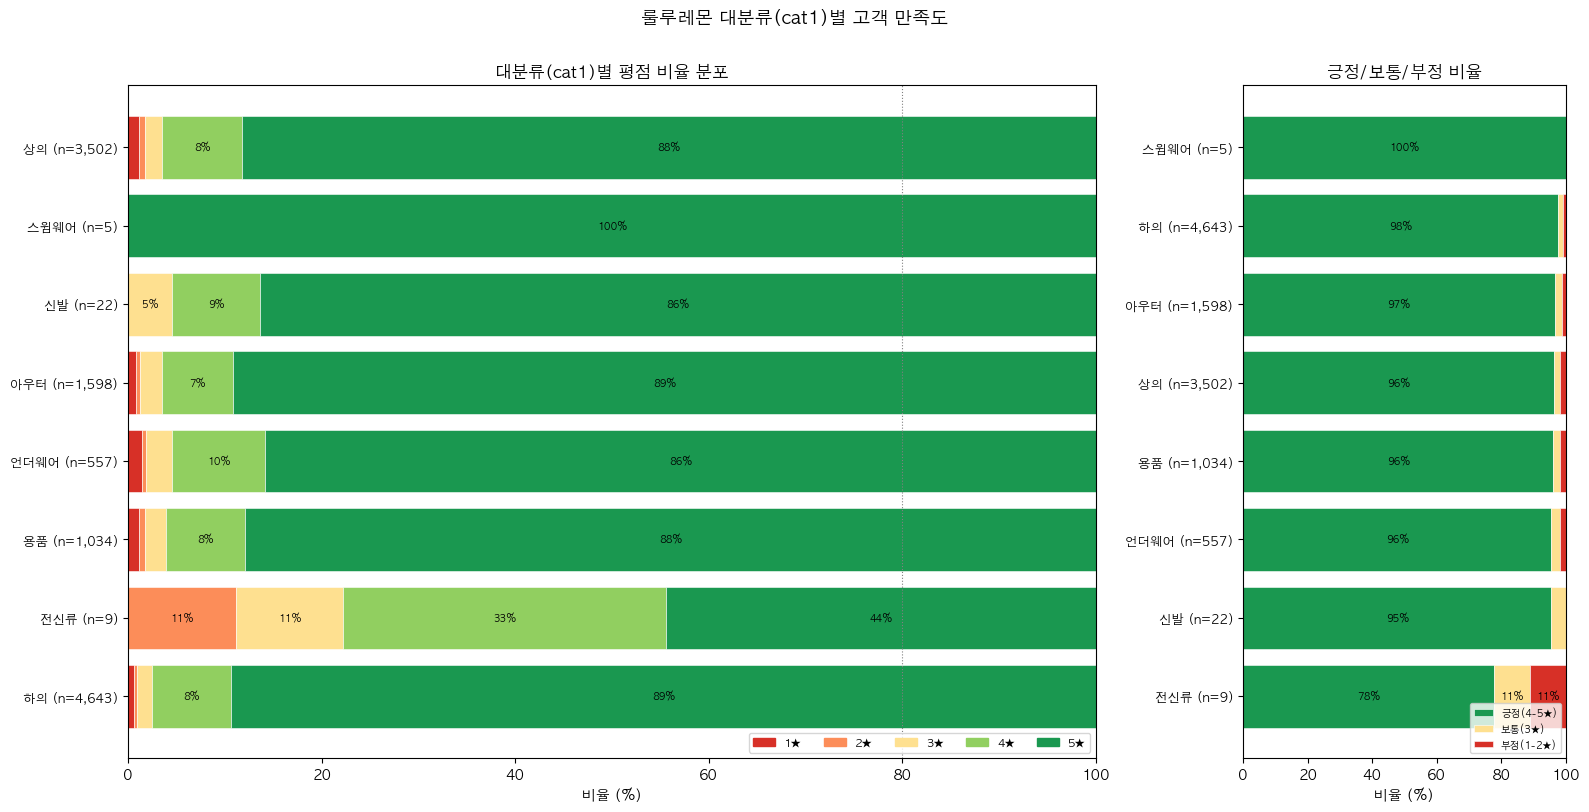

[cat1 만족도 요약]


,리뷰수,평균평점,긍정비율,부정비율
cat1,,,,
스윔웨어,5,5.000000,100.0%,0.0%
하의,4643,4.854404,97.5%,0.9%
아우터,1598,4.836671,96.6%,1.3%
상의,3502,4.818389,96.5%,1.7%
신발,22,4.818182,95.5%,0.0%
용품,1034,4.811412,96.1%,1.7%
언더웨어,557,4.780969,95.5%,1.8%
전신류,9,4.111111,77.8%,11.1%


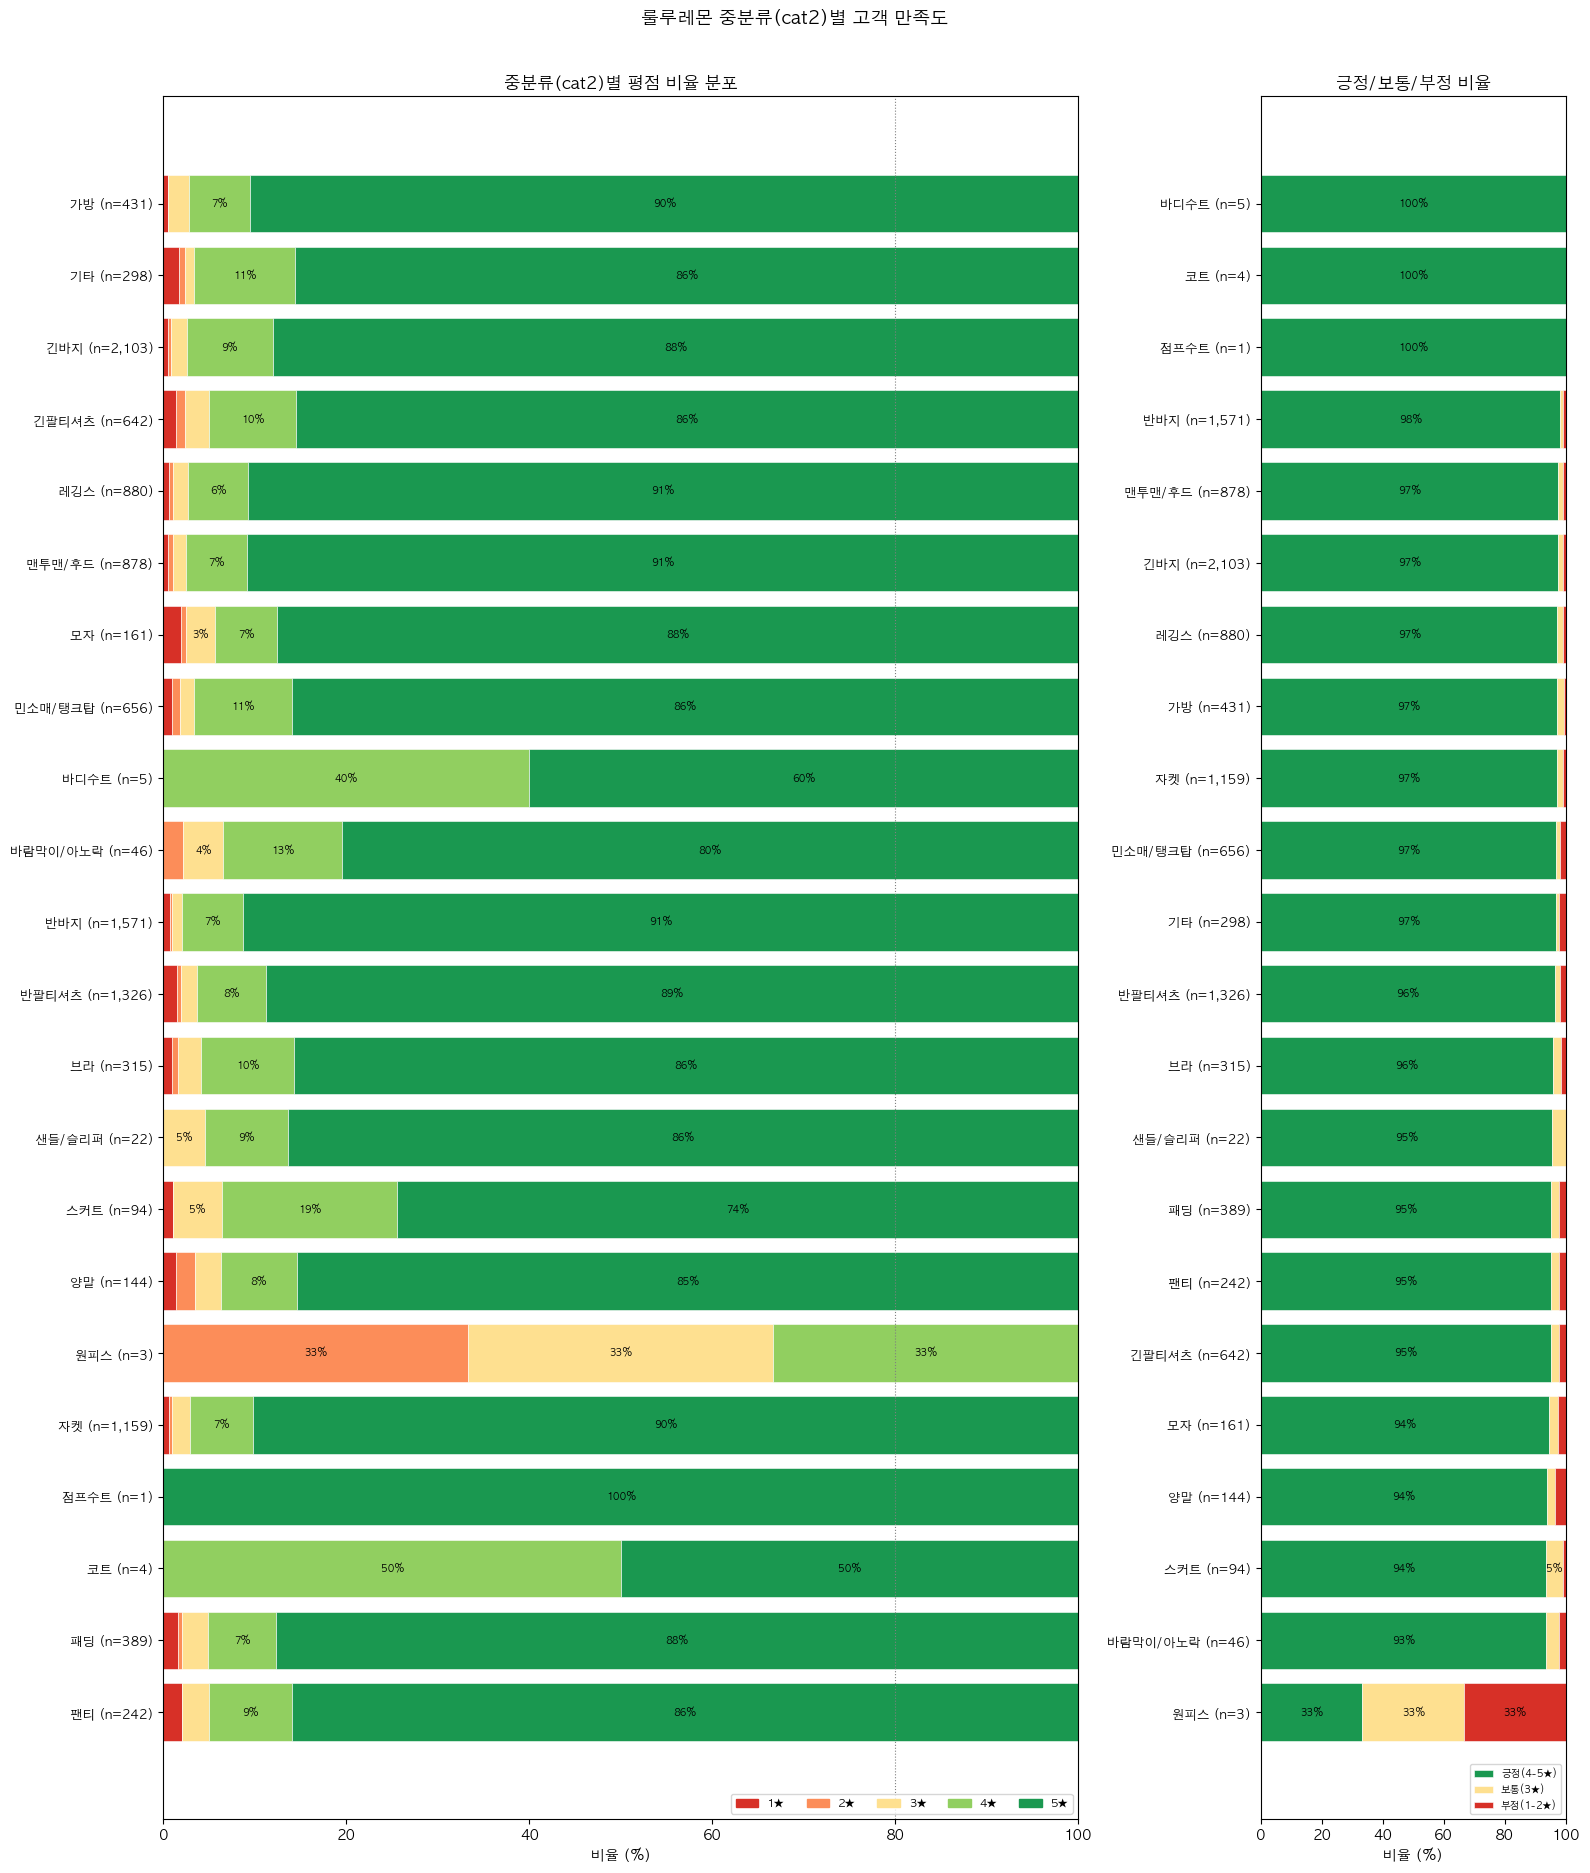

[cat2 만족도 요약]


,리뷰수,평균평점,긍정비율,부정비율
cat2,,,,
점프수트,1,5.000000,100.0%,0.0%
반바지,1571,4.877148,98.0%,1.0%
맨투맨/후드,878,4.869021,97.5%,1.0%
가방,431,4.867749,97.2%,0.5%
레깅스,880,4.864773,97.3%,1.0%
자켓,1159,4.857636,97.2%,0.9%
긴바지,2103,4.842130,97.4%,0.8%
반팔티셔츠,1326,4.819005,96.4%,1.9%
샌들/슬리퍼,22,4.818182,95.5%,0.0%


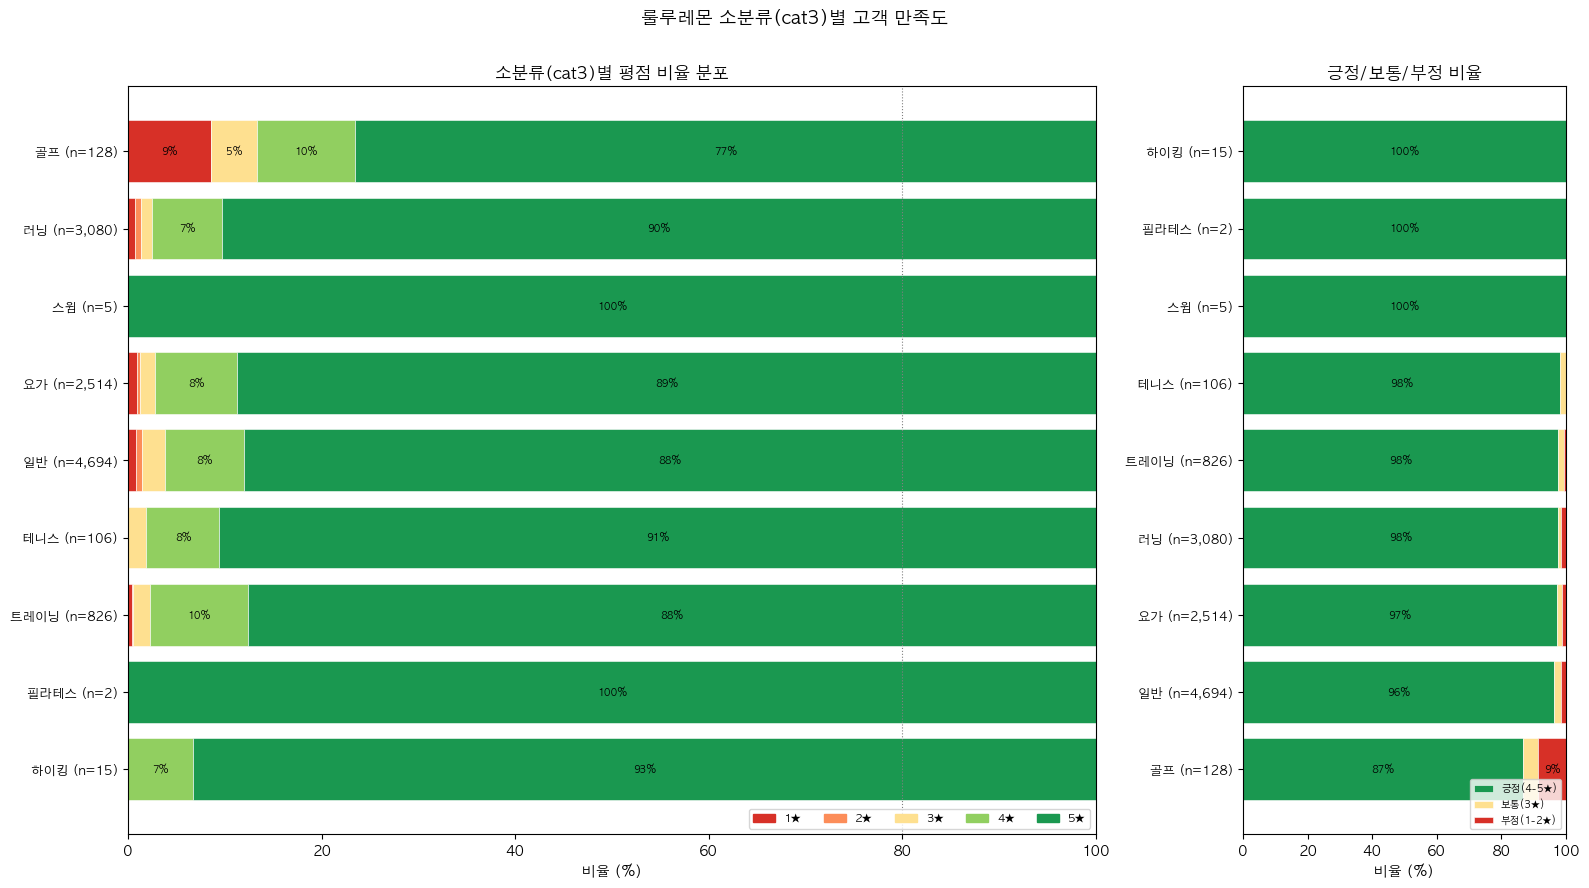

[cat3 만족도 요약]


,리뷰수,평균평점,긍정비율,부정비율
cat3,,,,
스윔,5,5.000000,100.0%,0.0%
필라테스,2,5.000000,100.0%,0.0%
하이킹,15,4.933333,100.0%,0.0%
테니스,106,4.886792,98.1%,0.0%
러닝,3080,4.857792,97.5%,1.3%
트레이닝,826,4.845036,97.7%,0.5%
요가,2514,4.837709,97.2%,1.2%
일반,4694,4.819770,96.2%,1.4%
골프,128,4.460938,86.7%,8.6%


In [38]:
# ─────────────────────────────────────────────────────
# [1-2] 카테고리별 고객 만족도: 평점 분포 & 긍/부정 비율
# → 룰루레몬 카테고리별 고객이 얼마나 만족하는지 파악
# ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# 평점별 색상 (1★=짙은빨강 ~ 5★=짙은초록)
RATING_COLORS = {1: "#d73027", 2: "#fc8d59", 3: "#fee090", 4: "#91cf60", 5: "#1a9850"}
RATING_LABELS = {1: "1★", 2: "2★", 3: "3★", 4: "4★", 5: "5★"}

def category_satisfaction_chart(cat_col, label):
    """카테고리별 평점 비율 수평 스택바 + 긍/보통/부정 요약"""
    # 카테고리 × 평점 비율 계산
    ct     = df_lulu_review.groupby([cat_col, "rating"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

    n_cats = len(ct_pct)
    fig_h  = max(4, n_cats * 0.75 + 2)
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_h),
                             gridspec_kw={"width_ratios": [3, 1]})

    # ── (좌) 수평 스택바: 각 카테고리별 평점 비율 ─────
    lefts = np.zeros(n_cats)
    for rating in [1, 2, 3, 4, 5]:
        vals = ct_pct[rating].values
        axes[0].barh(ct_pct.index, vals, left=lefts,
                     color=RATING_COLORS[rating], label=RATING_LABELS[rating],
                     edgecolor="white", linewidth=0.4)
        for i, (v, l) in enumerate(zip(vals, lefts)):
            if v >= 3:   # 3% 이상만 수치 표시
                axes[0].text(l + v / 2, i, f"{v:.0f}%",
                             ha="center", va="center", fontsize=7)
        lefts += vals

    axes[0].set_xlim(0, 100)
    axes[0].set_xlabel("비율 (%)")
    axes[0].set_title(f"{label}({cat_col})별 평점 비율 분포")
    axes[0].set_yticks(range(n_cats))
    # y축 레이블에 리뷰 수 병기
    review_counts = ct.sum(axis=1)  # 카테고리별 총 리뷰 수
    yticklabels = [f"{cat} (n={review_counts[cat]:,})"
                   for cat in ct_pct.index]
    axes[0].set_yticklabels(yticklabels, fontsize=9)
    axes[0].invert_yaxis()
    axes[0].axvline(80, color="gray", linestyle=":", linewidth=0.8)
    legend_patches = [mpatches.Patch(color=RATING_COLORS[r], label=RATING_LABELS[r])
                      for r in [1, 2, 3, 4, 5]]
    axes[0].legend(handles=legend_patches, loc="lower right", fontsize=8, ncol=5)

    # ── (우) 긍정/보통/부정 비율 요약 스택바 ─────────
    summary = pd.DataFrame({
        "긍정(4-5★)": ct_pct[[4, 5]].sum(axis=1),
        "보통(3★)"  : ct_pct[3],
        "부정(1-2★)": ct_pct[[1, 2]].sum(axis=1),
    }).sort_values("긍정(4-5★)", ascending=True)

    lefts2 = np.zeros(len(summary))
    for col, color in zip(summary.columns, ["#1a9850", "#fee090", "#d73027"]):
        vals2 = summary[col].values
        axes[1].barh(summary.index, vals2, left=lefts2,
                     color=color, label=col, edgecolor="white", linewidth=0.4)
        for i, (v, l) in enumerate(zip(vals2, lefts2)):
            if v >= 5:
                axes[1].text(l + v / 2, i, f"{v:.0f}%",
                             ha="center", va="center", fontsize=7)
        lefts2 += vals2

    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("비율 (%)")
    axes[1].set_title("긍정/보통/부정 비율")
    axes[1].set_yticks(range(len(summary)))
    axes[1].set_yticklabels(
        [f"{cat} (n={review_counts[cat]:,})" for cat in summary.index],
        fontsize=9)
    axes[1].legend(loc="lower right", fontsize=7)

    plt.suptitle(f"룰루레몬 {label}({cat_col})별 고객 만족도", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── 수치 요약 출력 ──────────────────────────────
    print(f"[{cat_col} 만족도 요약]")
    summary_tbl = df_lulu_review.groupby(cat_col)["rating"].agg(
        리뷰수="count", 평균평점="mean",
        긍정비율=lambda x: f"{(x >= 4).mean()*100:.1f}%",
        부정비율=lambda x: f"{(x <= 2).mean()*100:.1f}%"
    ).sort_values("평균평점", ascending=False)
    display(summary_tbl)

# cat1 / cat2 / cat3 순서로 실행
category_satisfaction_chart("cat1", "대분류")
category_satisfaction_chart("cat2", "중분류")
category_satisfaction_chart("cat3", "소분류")

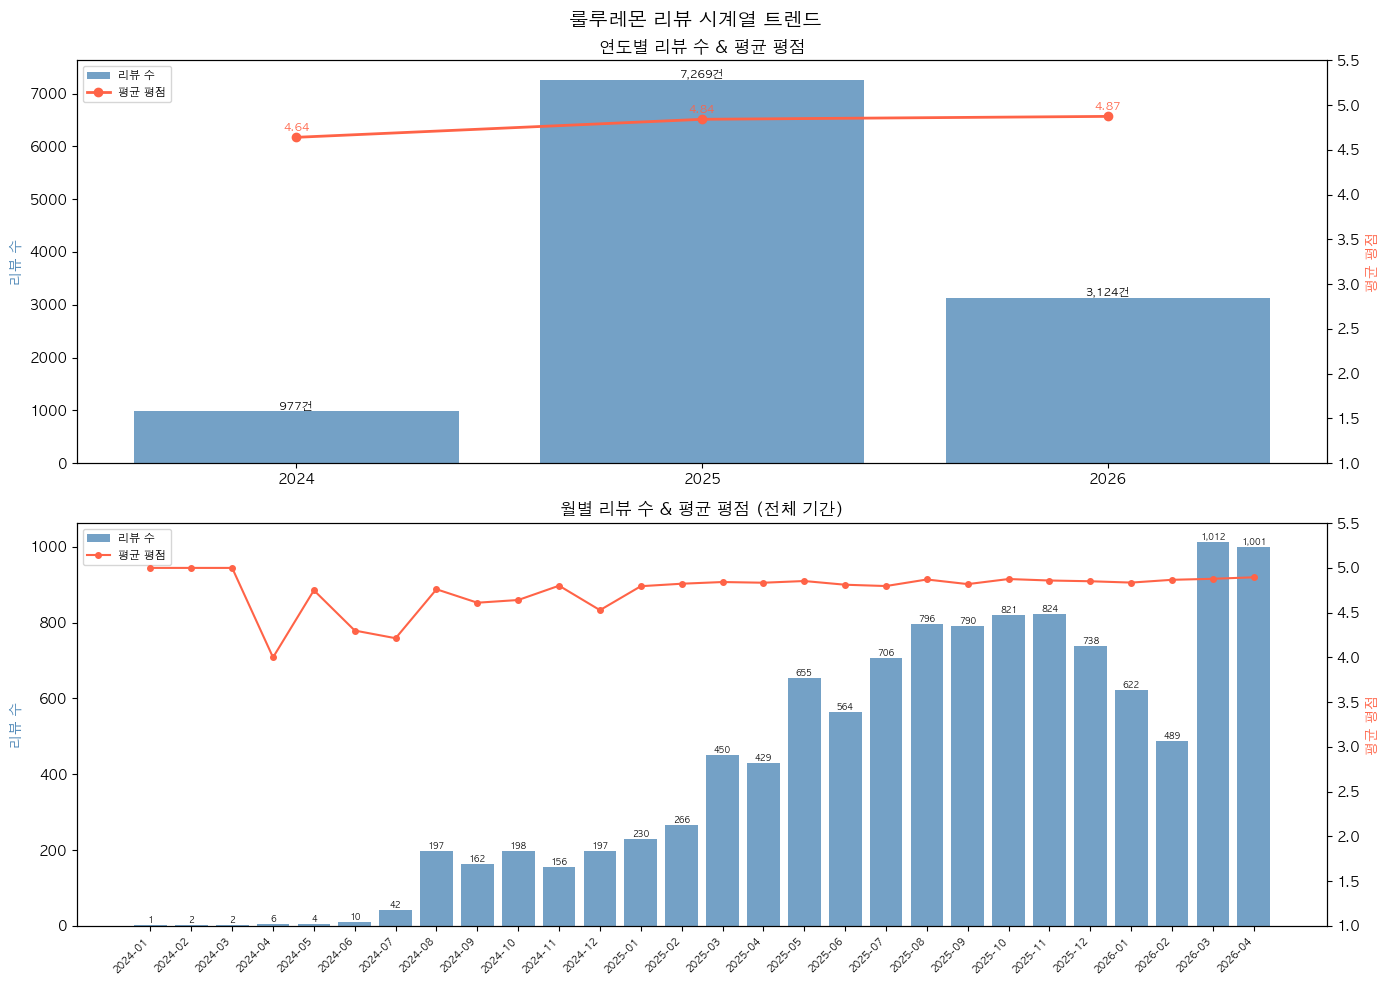

In [34]:
# ─────────────────────────────────────────────────────
# [2] 시계열 트렌드: 연도별·월별 리뷰 수 & 평균 평점 추이
# → 브랜드 관심도·만족도가 시간에 따라 어떻게 변하는지 파악
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── 연도별 집계 ────────────────────────────────────────
yearly = (df_lulu_review.groupby('year')
          .agg(review_count=('rating', 'count'), avg_rating=('rating', 'mean'))
          .reset_index())

ax1, ax2 = axes[0], axes[0].twinx()
bars = ax1.bar(yearly['year'], yearly['review_count'], color='steelblue', alpha=0.75, label='리뷰 수')
ax2.plot(yearly['year'], yearly['avg_rating'], color='tomato', marker='o', linewidth=2, label='평균 평점')

for bar, (_, row) in zip(bars, yearly.iterrows()):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h,
             f'{h:,}건', ha='center', va='bottom', fontsize=8)
for _, row in yearly.iterrows():
    ax2.text(row['year'], row['avg_rating'] + 0.05, f"{row['avg_rating']:.2f}",
             ha='center', va='bottom', fontsize=8, color='tomato')

ax1.set_title('연도별 리뷰 수 & 평균 평점')
ax1.set_ylabel('리뷰 수', color='steelblue')
ax2.set_ylabel('평균 평점', color='tomato')
ax2.set_ylim(1, 5.5)
ax1.set_xticks(yearly['year'])
ax1.set_xticklabels(yearly['year'], rotation=0)
lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0] + lines2[0], lines[1] + lines2[1], loc='upper left', fontsize=8)

# ── 월별 집계 (전체 기간) ──────────────────────────────
df_lulu_review['year_month'] = (df_lulu_review['year'].astype(str) + '-' +
                                 df_lulu_review['month'].astype(str).str.zfill(2))
monthly = (df_lulu_review.groupby('year_month')
           .agg(review_count=('rating', 'count'), avg_rating=('rating', 'mean'))
           .reset_index().sort_values('year_month'))

ax3, ax4 = axes[1], axes[1].twinx()
xs = range(len(monthly))
bars2 = ax3.bar(xs, monthly['review_count'], color='steelblue', alpha=0.75, label='리뷰 수')
ax4.plot(xs, monthly['avg_rating'], color='tomato', marker='o', markersize=4, linewidth=1.5, label='평균 평점')

for bar in bars2:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, h,
             f'{h:,}', ha='center', va='bottom', fontsize=6)

ax3.set_xticks(list(xs))
ax3.set_xticklabels(monthly['year_month'], rotation=45, ha='right', fontsize=7)
ax3.set_title('월별 리뷰 수 & 평균 평점 (전체 기간)')
ax3.set_ylabel('리뷰 수', color='steelblue')
ax4.set_ylabel('평균 평점', color='tomato')
ax4.set_ylim(1, 5.5)
lines3 = ax3.get_legend_handles_labels()
lines4 = ax4.get_legend_handles_labels()
ax3.legend(lines3[0] + lines4[0], lines3[1] + lines4[1], loc='upper left', fontsize=8)

plt.suptitle('룰루레몬 리뷰 시계열 트렌드', fontsize=14)
plt.tight_layout()
plt.show()

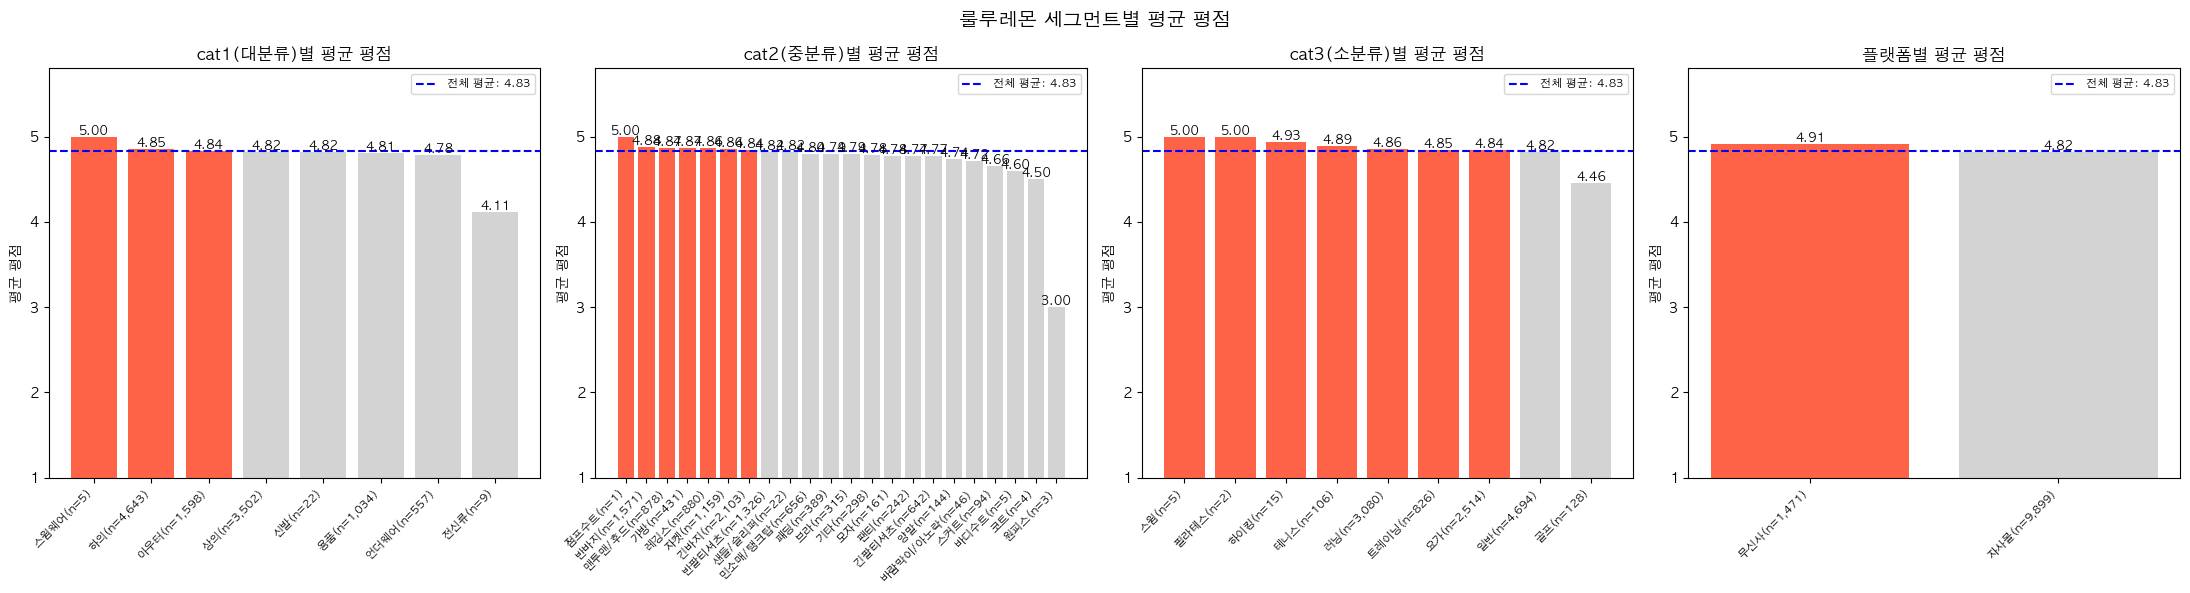

▶ 전체 평균 평점: 4.83
[cat1]
      평균평점   리뷰수
cat1            
스윔웨어  5.00     5
하의    4.85  4643
아우터   4.84  1598
상의    4.82  3502
신발    4.82    22
용품    4.81  1034
언더웨어  4.78   557
전신류   4.11     9
[cat2]
          평균평점   리뷰수
cat2                
점프수트      5.00     1
반바지       4.88  1571
맨투맨/후드    4.87   878
가방        4.87   431
레깅스       4.86   880
자켓        4.86  1159
긴바지       4.84  2103
반팔티셔츠     4.82  1326
샌들/슬리퍼    4.82    22
민소매/탱크탑   4.80   656
패딩        4.79   389
브라        4.79   315
기타        4.78   298
모자        4.78   161
팬티        4.77   242
긴팔티셔츠     4.77   642
양말        4.74   144
바람막이/아노락  4.72    46
스커트       4.66    94
바디수트      4.60     5
코트        4.50     4
원피스       3.00     3
[cat3]
      평균평점   리뷰수
cat3            
스윔    5.00     5
필라테스  5.00     2
하이킹   4.93    15
테니스   4.89   106
러닝    4.86  3080
트레이닝  4.85   826
요가    4.84  2514
일반    4.82  4694
골프    4.46   128
[platform]
          평균평점   리뷰수
platform            
무신사       4.91  1471
자사몰       4.82  9899


In [41]:
# ─────────────────────────────────────────────────────
# [3] 세그먼트별 평균 평점 비교
# → cat1/cat2/cat3, 플랫폼 기준으로 만족도 차이 파악
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
overall_rating = df_lulu_review["rating"].mean()

def rating_bar(ax, group_col, title):
    """세그먼트별 평균 평점 막대 + 전체 평균 기준선 + x축에 리뷰 수 표시"""
    grouped = df_lulu_review.groupby(group_col)["rating"].mean().sort_values(ascending=False)
    counts  = df_lulu_review.groupby(group_col)["rating"].count()   # 리뷰 수

    colors = ["tomato" if v >= overall_rating else "lightgray" for v in grouped.values]
    bars   = ax.bar(grouped.index, grouped.values, color=colors)
    ax.axhline(overall_rating, color="blue", linestyle="--", linewidth=1.5,
               label=f"전체 평균: {overall_rating:.2f}")

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

    ax.set_ylim(1, 5.8)
    ax.set_title(title)
    ax.set_ylabel("평균 평점")
    ax.set_xticks(range(len(grouped)))
    # x축 레이블에 카테고리명 + 총 리뷰 수 병기
    ax.set_xticklabels(
        [f"{cat}(n={counts[cat]:,})" for cat in grouped.index],
        rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=8)

rating_bar(axes[0], "cat1",     "cat1(대분류)별 평균 평점")
rating_bar(axes[1], "cat2",     "cat2(중분류)별 평균 평점")
rating_bar(axes[2], "cat3",     "cat3(소분류)별 평균 평점")
rating_bar(axes[3], "platform", "플랫폼별 평균 평점")

plt.suptitle("룰루레몬 세그먼트별 평균 평점", fontsize=14)
plt.tight_layout()
plt.show()

# ── 수치 요약 출력 ──────────────────────────────────────
print(f"▶ 전체 평균 평점: {overall_rating:.2f}")
for col in ["cat1", "cat2", "cat3", "platform"]:
    print(f"[{col}]")
    print(df_lulu_review.groupby(col)["rating"]
          .agg(["mean", "count"]).rename(columns={"mean":"평균평점","count":"리뷰수"})
          .sort_values("평균평점", ascending=False).round(2).to_string())

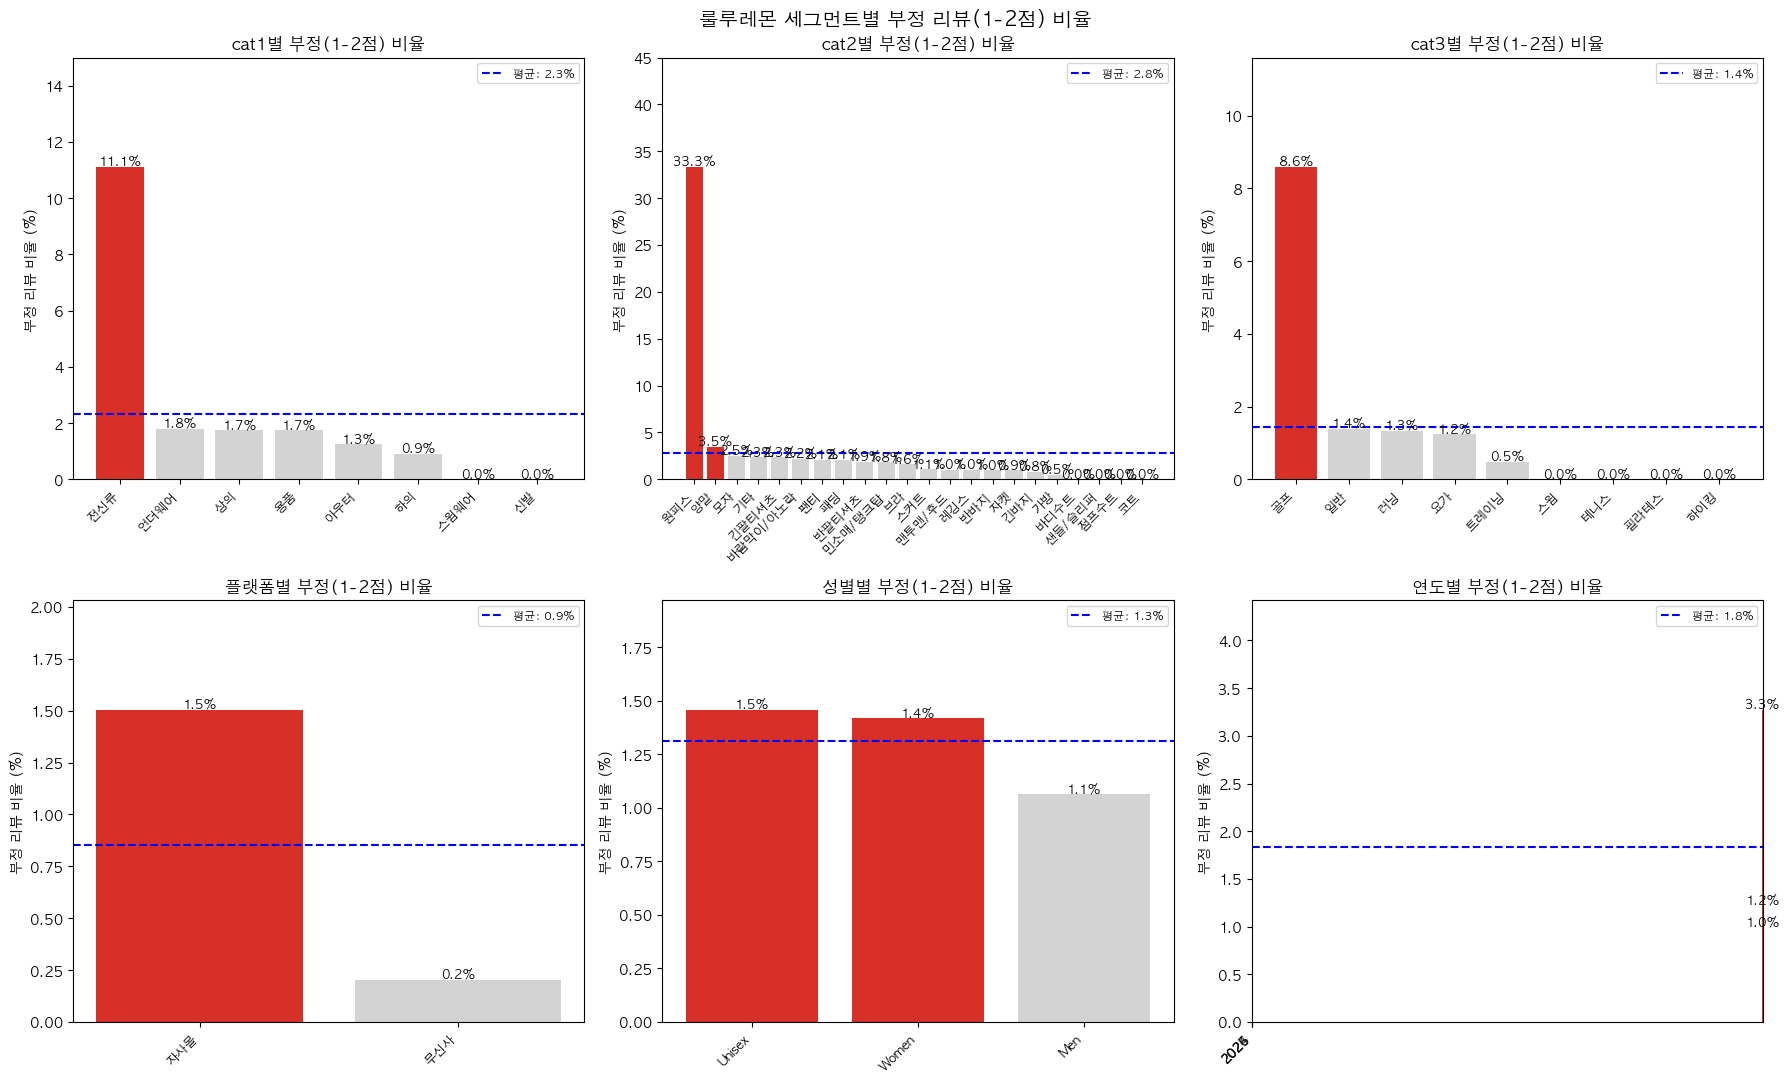


▶ 부정 리뷰 비율 상위 10개 상품 (리뷰 10건 이상)


,총리뷰수,평균평점,부정건수,부정비율
product_name,,,,
패스트 앤 프리 러닝 햇,11,3.73,3,27.27
퀵 드라이 숏슬리브 폴로 셔츠 *스트레이트 헴,27,4.00,6,22.22
"스트레치 트윌 골프 쇼츠 5""",14,3.71,3,21.43
유니섹스 파워 스트라이드 크루 삭스 *3팩,10,4.30,2,20.00
룰루레몬 펀더멘털 티셔츠,18,4.22,3,16.67
마일 메이커 런 크루 라이트웨이트 숏슬리브 셔츠,18,4.28,3,16.67
인비지웨어 미드라이즈 비키니 언더웨어 *3팩,13,4.08,2,15.38
원더모스트 Ultra-Soft Nulu 크루넥 롱슬리브 셔츠,15,4.13,2,13.33
헤비웨이트 코튼 저지 티셔츠,23,4.13,3,13.04


In [42]:
# ─────────────────────────────────────────────────────
# [4] 부정 리뷰 집중 분석
# → 어느 카테고리·플랫폼에서 불만이 집중되는지 파악
# ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

# 부정(1-2점) 비율 계산 함수
def neg_rate(df, group_col):
    g = df.groupby(group_col)['rating']
    return (g.apply(lambda x: (x <= 2).sum()) / g.count() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def neg_bar(ax, group_col, title):
    rates  = neg_rate(df_lulu_review, group_col)
    mean_r = rates.mean()
    colors = ['#d73027' if v >= mean_r else 'lightgray' for v in rates.values]
    bars   = ax.bar(rates.index, rates.values, color=colors)
    ax.axhline(mean_r, color='blue', linestyle='--', linewidth=1.5,
               label=f'평균: {mean_r:.1f}%')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, rates.max() * 1.35)
    ax.set_title(title)
    ax.set_ylabel('부정 리뷰 비율 (%)')
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=8)

neg_bar(axes[0][0], 'cat1',     'cat1별 부정(1-2점) 비율')
neg_bar(axes[0][1], 'cat2',     'cat2별 부정(1-2점) 비율')
neg_bar(axes[0][2], 'cat3',     'cat3별 부정(1-2점) 비율')
neg_bar(axes[1][0], 'platform', '플랫폼별 부정(1-2점) 비율')
neg_bar(axes[1][1], 'gender',   '성별별 부정(1-2점) 비율')
neg_bar(axes[1][2], 'year',     '연도별 부정(1-2점) 비율')

plt.suptitle('룰루레몬 세그먼트별 부정 리뷰(1-2점) 비율', fontsize=14)
plt.tight_layout()
plt.show()

# ── 부정 리뷰 상품 Top10 (product_name 기준) ──────────
print("\n▶ 부정 리뷰 비율 상위 10개 상품 (리뷰 10건 이상)")
prod_stats = (df_lulu_review.groupby('product_name')['rating']
              .agg(총리뷰수='count', 평균평점='mean',
                   부정건수=lambda x: (x <= 2).sum())
              .assign(부정비율=lambda df: df['부정건수'] / df['총리뷰수'] * 100)
              .query('총리뷰수 >= 10')
              .sort_values('부정비율', ascending=False)
              .head(10)
              .round(2))
display(prod_stats)

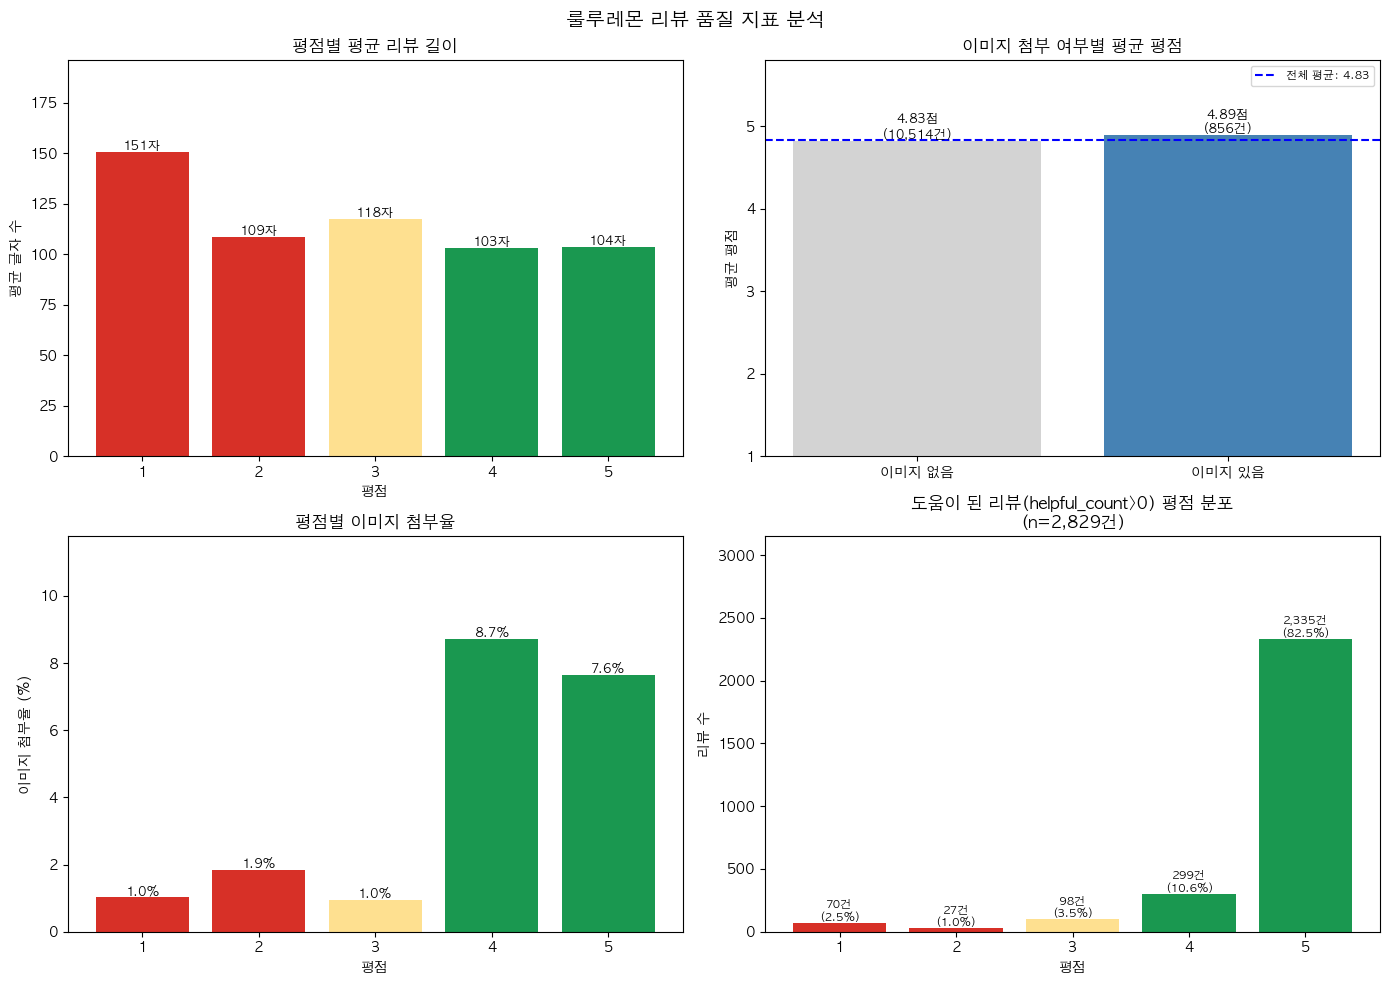


▶ 평균 리뷰 길이: 104자
▶ 이미지 첨부 리뷰 비율: 7.5%
▶ helpful_count > 0 리뷰 비율: 24.9%


In [43]:
# ─────────────────────────────────────────────────────
# [5] 리뷰 품질 지표 분석
# → 리뷰 길이, 이미지 첨부, helpful_count가 평점과 어떤 관계인지 파악
# ─────────────────────────────────────────────────────

# 리뷰 길이(글자 수) 컬럼 생성
df_lulu_review['review_len'] = df_lulu_review['content'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (1) 평점별 평균 리뷰 길이 ─────────────────────────
avg_len = df_lulu_review.groupby('rating')['review_len'].mean()
colors  = ['#d73027' if r <= 2 else '#fee090' if r == 3 else '#1a9850' for r in avg_len.index]
bars    = axes[0][0].bar(avg_len.index, avg_len.values, color=colors)
for bar in bars:
    h = bar.get_height()
    axes[0][0].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.0f}자',
                    ha='center', va='bottom', fontsize=9)
axes[0][0].set_ylim(0, avg_len.max() * 1.3)
axes[0][0].set_title('평점별 평균 리뷰 길이')
axes[0][0].set_xlabel('평점')
axes[0][0].set_ylabel('평균 글자 수')
axes[0][0].set_xticks(avg_len.index)

# ── (2) 이미지 첨부 여부별 평점 분포 ─────────────────
img_data = df_lulu_review.groupby('has_image').agg(
    avg_rating=('rating', 'mean'), count=('rating', 'count')).reset_index()
img_data['label'] = img_data['has_image'].map({0: '이미지 없음', 1: '이미지 있음'})
bars2 = axes[0][1].bar(img_data['label'], img_data['avg_rating'],
                        color=['lightgray', 'steelblue'])
axes[0][1].axhline(df_lulu_review['rating'].mean(), color='blue', linestyle='--',
                    linewidth=1.5, label=f"전체 평균: {df_lulu_review['rating'].mean():.2f}")
for bar, (_, row) in zip(bars2, img_data.iterrows()):
    h = bar.get_height()
    axes[0][1].text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:.2f}점\n({row["count"]:,}건)', ha='center', va='bottom', fontsize=9)
axes[0][1].set_ylim(1, 5.8)
axes[0][1].set_title('이미지 첨부 여부별 평균 평점')
axes[0][1].set_ylabel('평균 평점')
axes[0][1].legend(fontsize=8)

# ── (3) 평점별 이미지 첨부율 ──────────────────────────
img_rate = df_lulu_review.groupby('rating')['has_image'].mean() * 100
colors3  = ['#d73027' if r <= 2 else '#fee090' if r == 3 else '#1a9850' for r in img_rate.index]
bars3    = axes[1][0].bar(img_rate.index, img_rate.values, color=colors3)
for bar in bars3:
    h = bar.get_height()
    axes[1][0].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=9)
axes[1][0].set_ylim(0, img_rate.max() * 1.35)
axes[1][0].set_title('평점별 이미지 첨부율')
axes[1][0].set_xlabel('평점')
axes[1][0].set_ylabel('이미지 첨부율 (%)')
axes[1][0].set_xticks(img_rate.index)

# ── (4) helpful_count > 0인 리뷰의 평점 분포 ──────────
helpful = df_lulu_review[df_lulu_review['helpful_count'] > 0]
hc_by_rating = helpful['rating'].value_counts().sort_index()
hc_colors    = ['#d73027' if r <= 2 else '#fee090' if r == 3 else '#1a9850' for r in hc_by_rating.index]
bars4 = axes[1][1].bar(hc_by_rating.index, hc_by_rating.values, color=hc_colors)
for bar in bars4:
    h = bar.get_height()
    axes[1][1].text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:,}건\n({h/len(helpful)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=8)
axes[1][1].set_ylim(0, hc_by_rating.max() * 1.35)
axes[1][1].set_title(f'도움이 된 리뷰(helpful_count>0) 평점 분포\n(n={len(helpful):,}건)')
axes[1][1].set_xlabel('평점')
axes[1][1].set_ylabel('리뷰 수')
axes[1][1].set_xticks(hc_by_rating.index)

plt.suptitle('룰루레몬 리뷰 품질 지표 분석', fontsize=14)
plt.tight_layout()
plt.show()

# ── 요약 수치 출력 ──────────────────────────────────────
print(f"\n▶ 평균 리뷰 길이: {df_lulu_review['review_len'].mean():.0f}자")
print(f"▶ 이미지 첨부 리뷰 비율: {df_lulu_review['has_image'].mean()*100:.1f}%")
print(f"▶ helpful_count > 0 리뷰 비율: {(df_lulu_review['helpful_count'] > 0).mean()*100:.1f}%")

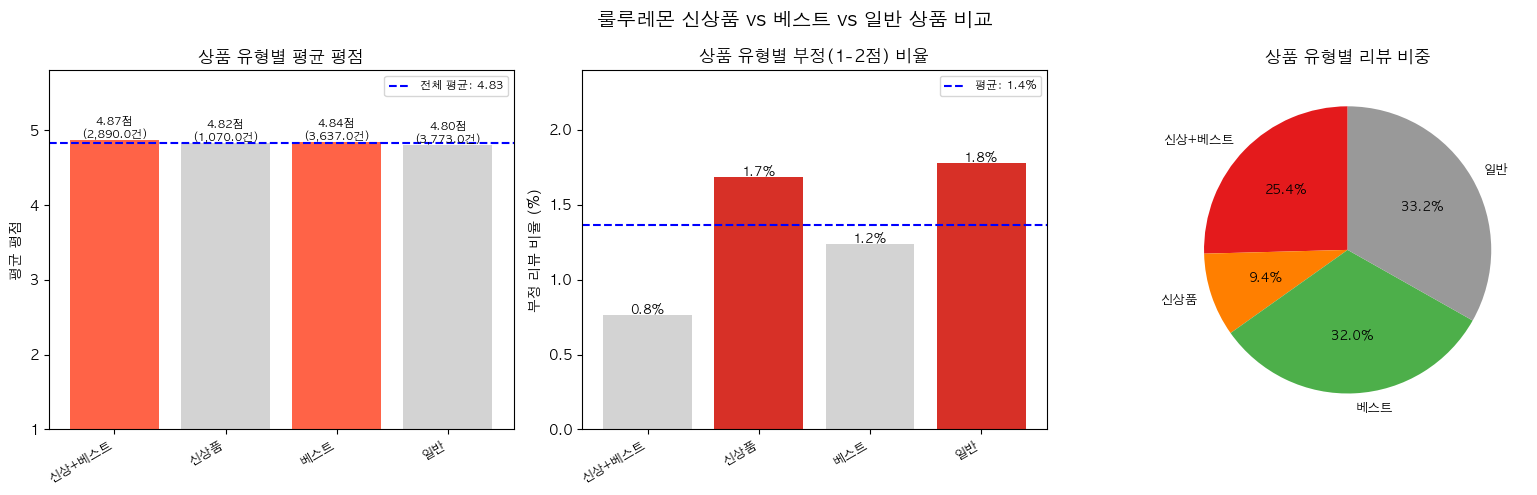

In [44]:
# ─────────────────────────────────────────────────────
# [6] 신상품(is_new) vs 베스트(is_best) 평점·구매빈도 비교
# → 신상·베스트 상품에 대한 고객 반응 차이 파악
# ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
overall_r = df_lulu_review['rating'].mean()

# ── (1) is_new / is_best 조합별 평균 평점 ─────────────
df_lulu_review['상품구분'] = df_lulu_review.apply(
    lambda r: '신상+베스트' if r['is_new'] and r['is_best']
    else ('신상품'   if r['is_new']
    else ('베스트'   if r['is_best']
    else '일반')), axis=1)

grp_order = ['신상+베스트', '신상품', '베스트', '일반']
grp_stats = (df_lulu_review.groupby('상품구분')['rating']
             .agg(평균평점='mean', 리뷰수='count')
             .reindex(grp_order).dropna())

colors = ['tomato' if v >= overall_r else 'lightgray' for v in grp_stats['평균평점']]
bars = axes[0].bar(grp_stats.index, grp_stats['평균평점'], color=colors)
axes[0].axhline(overall_r, color='blue', linestyle='--', linewidth=1.5,
                label=f'전체 평균: {overall_r:.2f}')
for bar, (idx, row) in zip(bars, grp_stats.iterrows()):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:.2f}점\n({row["리뷰수"]:,}건)', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(1, 5.8)
axes[0].set_title('상품 유형별 평균 평점')
axes[0].set_ylabel('평균 평점')
axes[0].set_xticks(range(len(grp_stats)))
axes[0].set_xticklabels(grp_stats.index, rotation=30, ha='right', fontsize=9)
axes[0].legend(fontsize=8)

# ── (2) is_new / is_best 조합별 부정 비율 ────────────
grp_neg = (df_lulu_review.groupby('상품구분')['rating']
           .apply(lambda x: (x <= 2).mean() * 100)
           .reindex(grp_order).dropna())

mean_neg = grp_neg.mean()
colors2  = ['#d73027' if v >= mean_neg else 'lightgray' for v in grp_neg.values]
bars2 = axes[1].bar(grp_neg.index, grp_neg.values, color=colors2)
axes[1].axhline(mean_neg, color='blue', linestyle='--', linewidth=1.5,
                label=f'평균: {mean_neg:.1f}%')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, grp_neg.max() * 1.35)
axes[1].set_title('상품 유형별 부정(1-2점) 비율')
axes[1].set_ylabel('부정 리뷰 비율 (%)')
axes[1].set_xticks(range(len(grp_neg)))
axes[1].set_xticklabels(grp_neg.index, rotation=30, ha='right', fontsize=9)
axes[1].legend(fontsize=8)

# ── (3) 상품 유형별 리뷰 수 비중 ──────────────────────
grp_cnt = (df_lulu_review.groupby('상품구분').size()
           .reindex(grp_order).dropna())
axes[2].pie(grp_cnt.values, labels=grp_cnt.index,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9},
            colors=['#e41a1c', '#ff7f00', '#4daf4a', '#999999'])
axes[2].set_title('상품 유형별 리뷰 비중')

plt.suptitle('룰루레몬 신상품 vs 베스트 vs 일반 상품 비교', fontsize=14)
plt.tight_layout()
plt.show()

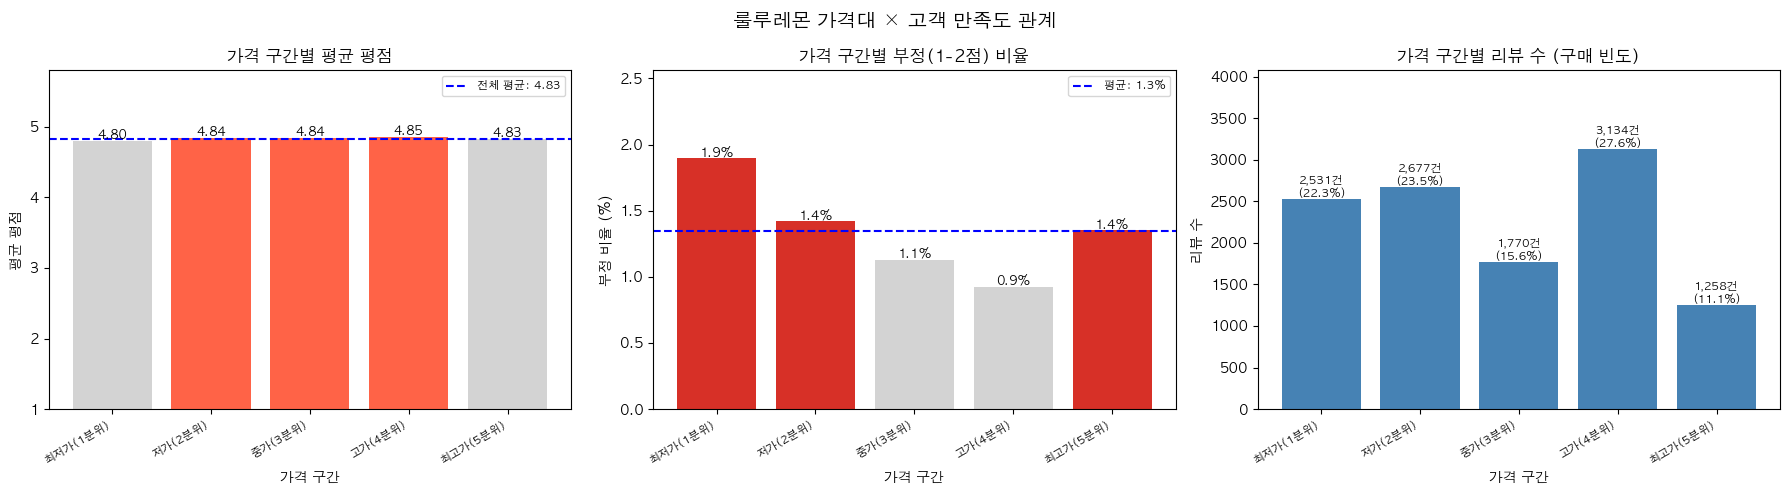


▶ 가격 구간별 원가 범위
                 최솟값       최댓값        평균
price_band                              
최저가(1분위)     13000.0   78000.0   67068.0
저가(2분위)      79000.0  109000.0   97722.0
중가(3분위)     110000.0  138000.0  132352.0
고가(4분위)     159000.0  184000.0  177764.0
최고가(5분위)    198000.0  670000.0  270416.0


In [45]:
# ─────────────────────────────────────────────────────
# [8] 가격대 × 평점 관계 분석
# → 비싼 상품을 살수록 더 만족하는지, 가격 민감도 파악
# ─────────────────────────────────────────────────────

# 원가 기준 가격 구간 분류 (5구간)
df_lulu_review['price_band'] = pd.qcut(
    df_lulu_review['original_price'], q=5,
    labels=['최저가(1분위)', '저가(2분위)', '중가(3분위)', '고가(4분위)', '최고가(5분위)'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
overall_r = df_lulu_review['rating'].mean()

# ── (1) 가격 구간별 평균 평점 ─────────────────────────
pb_rating = df_lulu_review.groupby('price_band', observed=True)['rating'].mean()
colors    = ['tomato' if v >= overall_r else 'lightgray' for v in pb_rating.values]
bars      = axes[0].bar(pb_rating.index, pb_rating.values, color=colors)
axes[0].axhline(overall_r, color='blue', linestyle='--', linewidth=1.5,
                label=f'전체 평균: {overall_r:.2f}')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.2f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(1, 5.8)
axes[0].set_title('가격 구간별 평균 평점')
axes[0].set_xlabel('가격 구간')
axes[0].set_ylabel('평균 평점')
axes[0].set_xticks(range(len(pb_rating)))
axes[0].set_xticklabels(pb_rating.index, rotation=30, ha='right', fontsize=8)
axes[0].legend(fontsize=8)

# ── (2) 가격 구간별 부정 비율 ─────────────────────────
pb_neg    = (df_lulu_review.groupby('price_band', observed=True)['rating']
             .apply(lambda x: (x <= 2).mean() * 100))
mean_neg  = pb_neg.mean()
colors2   = ['#d73027' if v >= mean_neg else 'lightgray' for v in pb_neg.values]
bars2     = axes[1].bar(pb_neg.index, pb_neg.values, color=colors2)
axes[1].axhline(mean_neg, color='blue', linestyle='--', linewidth=1.5,
                label=f'평균: {mean_neg:.1f}%')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, pb_neg.max() * 1.35)
axes[1].set_title('가격 구간별 부정(1-2점) 비율')
axes[1].set_xlabel('가격 구간')
axes[1].set_ylabel('부정 비율 (%)')
axes[1].set_xticks(range(len(pb_neg)))
axes[1].set_xticklabels(pb_neg.index, rotation=30, ha='right', fontsize=8)
axes[1].legend(fontsize=8)

# ── (3) 가격 구간별 리뷰 수 ───────────────────────────
pb_cnt   = df_lulu_review.groupby('price_band', observed=True).size()
bars3    = axes[2].bar(pb_cnt.index, pb_cnt.values, color='steelblue')
for bar in bars3:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:,}건\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[2].set_ylim(0, pb_cnt.max() * 1.3)
axes[2].set_title('가격 구간별 리뷰 수 (구매 빈도)')
axes[2].set_xlabel('가격 구간')
axes[2].set_ylabel('리뷰 수')
axes[2].set_xticks(range(len(pb_cnt)))
axes[2].set_xticklabels(pb_cnt.index, rotation=30, ha='right', fontsize=8)

plt.suptitle('룰루레몬 가격대 × 고객 만족도 관계', fontsize=14)
plt.tight_layout()
plt.show()

# ── 가격 구간별 대표 가격 범위 출력 ──────────────────
print("\n▶ 가격 구간별 원가 범위")
price_range = df_lulu_review.groupby('price_band', observed=True)['original_price'].agg(['min','max','mean'])
print(price_range.rename(columns={'min':'최솟값','max':'최댓값','mean':'평균'}).round(0).to_string())

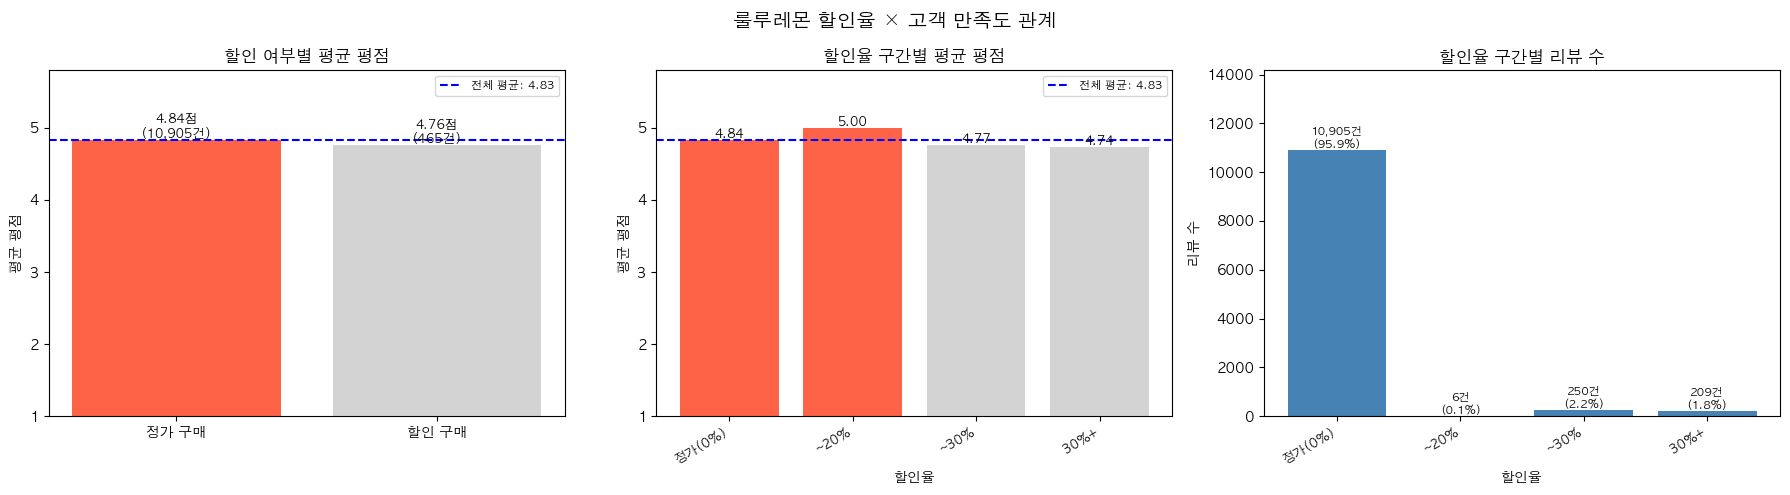


▶ 정가 구매 비율: 95.9%
▶ 할인 구매 비율: 4.1%
▶ 평균 할인율: 31.7%


In [46]:
# ─────────────────────────────────────────────────────
# [9] 할인율 분석: 할인 여부·할인율 구간별 평점 & 구매빈도
# → 정가 구매 vs 할인 구매 고객의 만족도 차이, 할인 깊이와 만족도 관계 파악
# ─────────────────────────────────────────────────────

# 할인율 계산 (원가 기준)
df_lulu_review['discount_rate'] = (
    (df_lulu_review['original_price'] - df_lulu_review['discount_price'])
    / df_lulu_review['original_price'] * 100
).round(1)

# 할인 여부 구분 (0% = 정가, 0% 초과 = 할인)
df_lulu_review['is_discounted'] = df_lulu_review['discount_rate'] > 0

# 할인율 구간 분류
df_lulu_review['discount_band'] = pd.cut(
    df_lulu_review['discount_rate'],
    bins=[-0.1, 0, 10, 20, 30, 100],
    labels=['정가(0%)', '~10%', '~20%', '~30%', '30%+'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
overall_r = df_lulu_review['rating'].mean()

# ── (1) 할인 여부별 평균 평점 ─────────────────────────
disc_stats = df_lulu_review.groupby('is_discounted')['rating'].agg(['mean', 'count']).reset_index()
disc_stats['label'] = disc_stats['is_discounted'].map({False: '정가 구매', True: '할인 구매'})
colors = ['tomato' if v >= overall_r else 'lightgray' for v in disc_stats['mean']]
bars   = axes[0].bar(disc_stats['label'], disc_stats['mean'], color=colors)
axes[0].axhline(overall_r, color='blue', linestyle='--', linewidth=1.5,
                label=f'전체 평균: {overall_r:.2f}')
for bar, (_, row) in zip(bars, disc_stats.iterrows()):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:.2f}점\n({row["count"]:,}건)', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(1, 5.8)
axes[0].set_title('할인 여부별 평균 평점')
axes[0].set_ylabel('평균 평점')
axes[0].legend(fontsize=8)

# ── (2) 할인율 구간별 평균 평점 ──────────────────────
db_rating = df_lulu_review.groupby('discount_band', observed=True)['rating'].mean()
colors2   = ['tomato' if v >= overall_r else 'lightgray' for v in db_rating.values]
bars2     = axes[1].bar(db_rating.index, db_rating.values, color=colors2)
axes[1].axhline(overall_r, color='blue', linestyle='--', linewidth=1.5,
                label=f'전체 평균: {overall_r:.2f}')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.2f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(1, 5.8)
axes[1].set_title('할인율 구간별 평균 평점')
axes[1].set_xlabel('할인율')
axes[1].set_ylabel('평균 평점')
axes[1].set_xticks(range(len(db_rating)))
axes[1].set_xticklabels(db_rating.index, rotation=30, ha='right', fontsize=9)
axes[1].legend(fontsize=8)

# ── (3) 할인율 구간별 리뷰 수 ────────────────────────
db_cnt = df_lulu_review.groupby('discount_band', observed=True).size()
bars3  = axes[2].bar(db_cnt.index, db_cnt.values, color='steelblue')
for bar in bars3:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:,}건\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[2].set_ylim(0, db_cnt.max() * 1.3)
axes[2].set_title('할인율 구간별 리뷰 수')
axes[2].set_xlabel('할인율')
axes[2].set_ylabel('리뷰 수')
axes[2].set_xticks(range(len(db_cnt)))
axes[2].set_xticklabels(db_cnt.index, rotation=30, ha='right', fontsize=9)

plt.suptitle('룰루레몬 할인율 × 고객 만족도 관계', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n▶ 정가 구매 비율: {(~df_lulu_review['is_discounted']).mean()*100:.1f}%")
print(f"▶ 할인 구매 비율: {df_lulu_review['is_discounted'].mean()*100:.1f}%")
print(f"▶ 평균 할인율: {df_lulu_review[df_lulu_review['is_discounted']]['discount_rate'].mean():.1f}%")

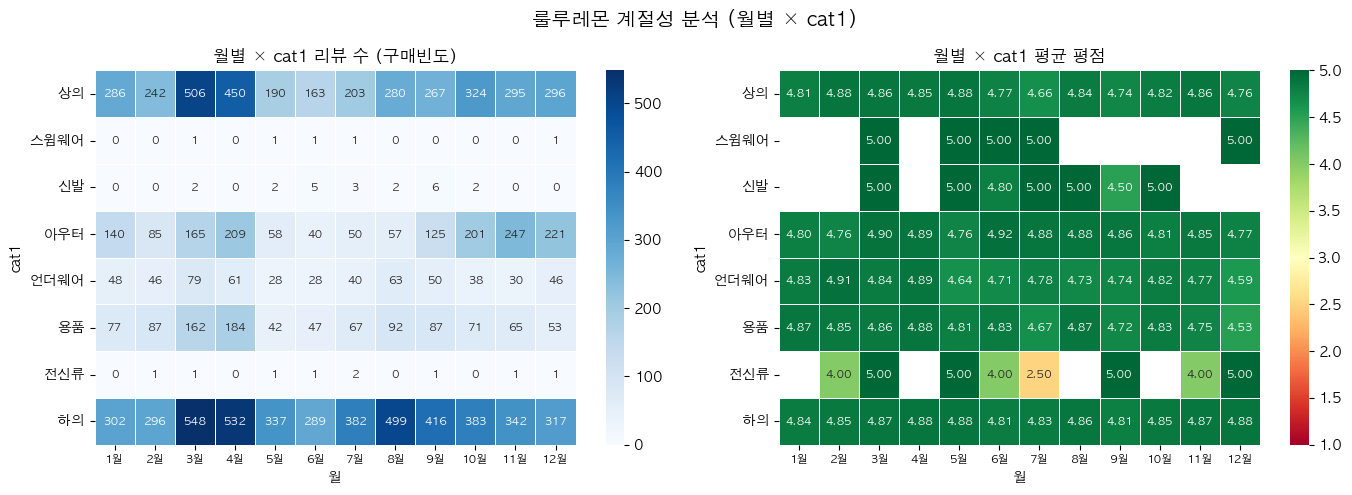


▶ 월별 리뷰 수 & 평균 평점
        리뷰수  평균평점
month            
1       853  4.83
2       757  4.85
3      1464  4.87
4      1436  4.87
5       659  4.85
6       574  4.80
7       748  4.76
8       993  4.85
9       952  4.78
10     1019  4.83
11      980  4.85
12      935  4.78


In [47]:
# ─────────────────────────────────────────────────────
# [10] 월별 × cat1 계절성 히트맵
# → 어느 계절에 어떤 카테고리 상품이 많이 팔리고, 만족도는 어떤지 파악
# ─────────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (1) 월별 × cat1 리뷰 수 (구매빈도) 히트맵 ────────
pivot_cnt = df_lulu_review.pivot_table(
    values='review_id', index='cat1', columns='month', aggfunc='count').fillna(0)
# 월 컬럼 정렬
pivot_cnt = pivot_cnt.reindex(columns=sorted(pivot_cnt.columns))

sns.heatmap(pivot_cnt, ax=axes[0], annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, annot_kws={'size': 8})
axes[0].set_title('월별 × cat1 리뷰 수 (구매빈도)')
axes[0].set_xlabel('월')
axes[0].set_ylabel('cat1')
axes[0].set_xticklabels([f'{m}월' for m in sorted(pivot_cnt.columns)], rotation=0, fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ── (2) 월별 × cat1 평균 평점 히트맵 ─────────────────
pivot_rtg = df_lulu_review.pivot_table(
    values='rating', index='cat1', columns='month', aggfunc='mean')
pivot_rtg = pivot_rtg.reindex(columns=sorted(pivot_rtg.columns))

sns.heatmap(pivot_rtg, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=1, vmax=5, linewidths=0.4, annot_kws={'size': 8})
axes[1].set_title('월별 × cat1 평균 평점')
axes[1].set_xlabel('월')
axes[1].set_ylabel('cat1')
axes[1].set_xticklabels([f'{m}월' for m in sorted(pivot_rtg.columns)], rotation=0, fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('룰루레몬 계절성 분석 (월별 × cat1)', fontsize=14)
plt.tight_layout()
plt.show()

# ── 월별 전체 리뷰 수 & 평균 평점 요약 ───────────────
print("\n▶ 월별 리뷰 수 & 평균 평점")
print(df_lulu_review.groupby('month')['rating']
      .agg(리뷰수='count', 평균평점='mean')
      .round(2).to_string())

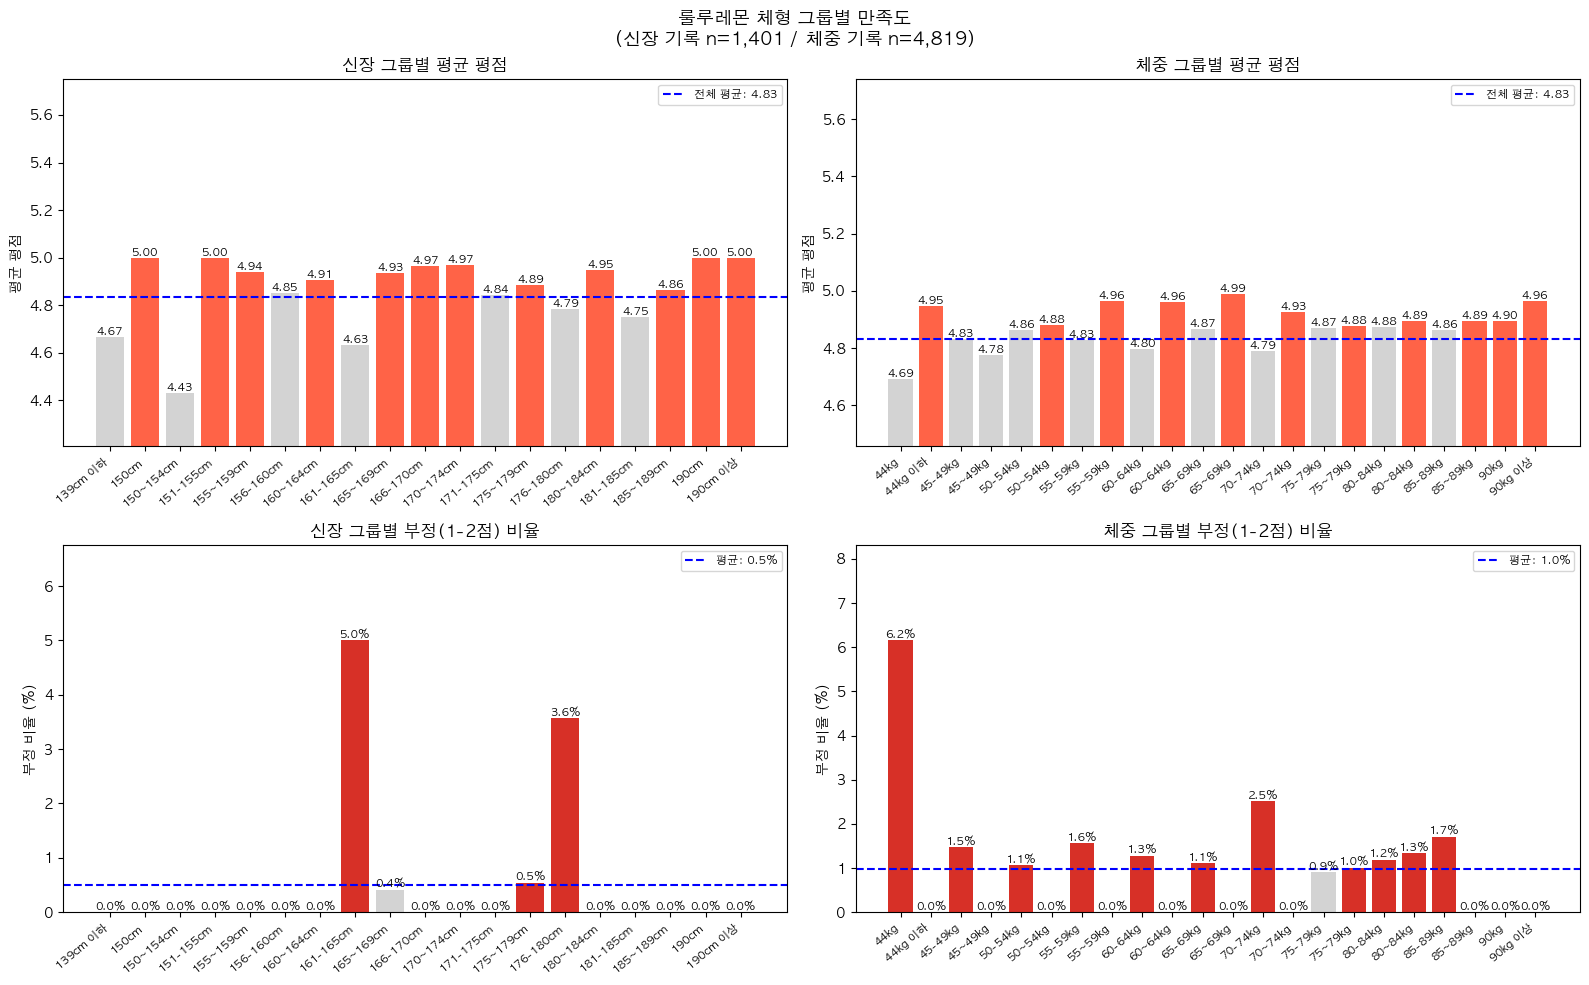

In [48]:
# ─────────────────────────────────────────────────────
# [11] 체형 정보(신장/체중 그룹) × 만족도 분석
# → 키·몸무게 그룹별로 만족도 차이가 있는지 파악 (핏/사이즈 불만 연관성)
# ─────────────────────────────────────────────────────

# unknown 제거 후 분석
df_height = df_lulu_review[df_lulu_review['user_height_group'] != 'unknown'].copy()
df_weight = df_lulu_review[df_lulu_review['user_weight_group'] != 'unknown'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
overall_r = df_lulu_review['rating'].mean()

def seg_bar(ax, df, group_col, title, ylabel='평균 평점', value_col='rating', agg_fn='mean'):
    grouped = df.groupby(group_col)[value_col].agg(agg_fn).sort_index()
    colors  = ['tomato' if v >= grouped.mean() else 'lightgray' for v in grouped.values]
    bars    = ax.bar(grouped.index, grouped.values, color=colors)
    ax.axhline(overall_r if ylabel == '평균 평점' else grouped.mean(),
               color='blue', linestyle='--', linewidth=1.5,
               label=f'{"전체" if ylabel == "평균 평점" else "그룹"} 평균: {(overall_r if ylabel == "평균 평점" else grouped.mean()):.2f}')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(grouped.min() * 0.95, grouped.max() * 1.15)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped.index, rotation=40, ha='right', fontsize=8)
    ax.legend(fontsize=8)

# (1) 신장 그룹별 평균 평점
seg_bar(axes[0][0], df_height, 'user_height_group', '신장 그룹별 평균 평점')

# (2) 체중 그룹별 평균 평점
seg_bar(axes[0][1], df_weight, 'user_weight_group', '체중 그룹별 평균 평점')

# (3) 신장 그룹별 부정 비율
ht_neg = df_height.groupby('user_height_group')['rating'].apply(
    lambda x: (x <= 2).mean() * 100).sort_index()
mean_n = ht_neg.mean()
colors3 = ['#d73027' if v >= mean_n else 'lightgray' for v in ht_neg.values]
bars3   = axes[1][0].bar(ht_neg.index, ht_neg.values, color=colors3)
axes[1][0].axhline(mean_n, color='blue', linestyle='--', linewidth=1.5, label=f'평균: {mean_n:.1f}%')
for bar in bars3:
    h = bar.get_height()
    axes[1][0].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8)
axes[1][0].set_ylim(0, ht_neg.max() * 1.35)
axes[1][0].set_title('신장 그룹별 부정(1-2점) 비율')
axes[1][0].set_ylabel('부정 비율 (%)')
axes[1][0].set_xticks(range(len(ht_neg)))
axes[1][0].set_xticklabels(ht_neg.index, rotation=40, ha='right', fontsize=8)
axes[1][0].legend(fontsize=8)

# (4) 체중 그룹별 부정 비율
wt_neg = df_weight.groupby('user_weight_group')['rating'].apply(
    lambda x: (x <= 2).mean() * 100).sort_index()
mean_n2 = wt_neg.mean()
colors4 = ['#d73027' if v >= mean_n2 else 'lightgray' for v in wt_neg.values]
bars4   = axes[1][1].bar(wt_neg.index, wt_neg.values, color=colors4)
axes[1][1].axhline(mean_n2, color='blue', linestyle='--', linewidth=1.5, label=f'평균: {mean_n2:.1f}%')
for bar in bars4:
    h = bar.get_height()
    axes[1][1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8)
axes[1][1].set_ylim(0, wt_neg.max() * 1.35)
axes[1][1].set_title('체중 그룹별 부정(1-2점) 비율')
axes[1][1].set_ylabel('부정 비율 (%)')
axes[1][1].set_xticks(range(len(wt_neg)))
axes[1][1].set_xticklabels(wt_neg.index, rotation=40, ha='right', fontsize=8)
axes[1][1].legend(fontsize=8)

plt.suptitle(f'룰루레몬 체형 그룹별 만족도\n(신장 기록 n={len(df_height):,} / 체중 기록 n={len(df_weight):,})', fontsize=13)
plt.tight_layout()
plt.show()

▶ 리뷰 수 Top 20 상품 프로파일


,리뷰수,평균평점,부정비율,긍정비율,평균가격,cat1,gender
product_name,,,,,,,
스위프틀리 테크 숏슬리브 셔츠 2.0 *웨이스트 렝스,409,4.90,0.73,98.29,93000.0,상의,Women
"그루브 Nulu 슈퍼 하이라이즈 플레어드 팬츠 30"" *아시아 핏",378,4.90,0.53,98.94,138000.0,하의,Women
스쿠바 오버사이즈드 풀집,317,4.90,0.00,98.42,184000.0,상의,Women
스쿠바 오버사이즈드 퍼넬넥 하프집,282,4.93,0.35,99.29,159000.0,상의,Women
디파인 크롭 재킷 *리브드 Nulu,174,4.90,0.57,98.28,184000.0,아우터,Women
스위프틀리 테크 롱슬리브 셔츠 2.0 *웨이스트 렝스,169,4.86,1.18,97.63,109000.0,상의,Women
"페이스 브레이커 라이너리스 쇼츠 7""",144,4.94,0.00,98.61,109000.0,하의,Men
디파인 크롭 후드 재킷 *Nulu,143,4.92,0.70,98.60,184000.0,아우터,Women
그루브 Nulu 슈퍼 하이라이즈 플레어드 팬츠 *레귤러,141,4.84,0.71,95.74,138000.0,하의,Women


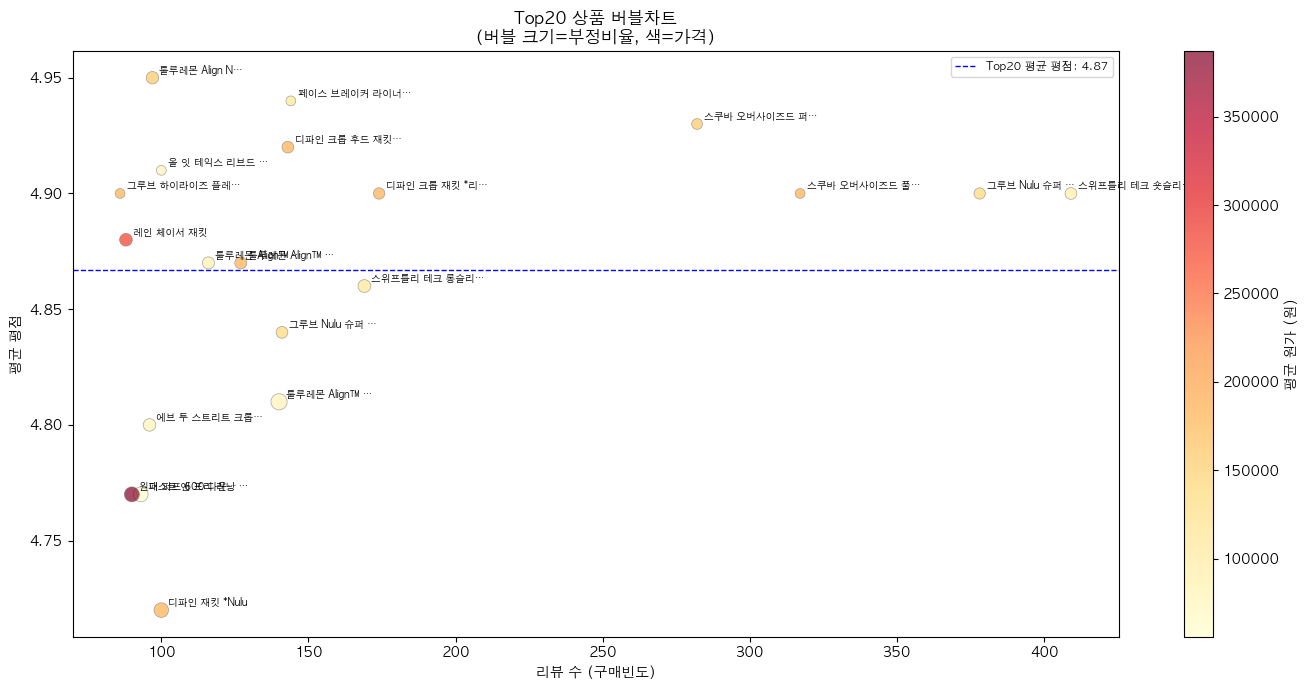

In [49]:
# ─────────────────────────────────────────────────────
# [12] 인기 상품 Top20 분석
# → 가장 많이 리뷰된 상품의 평점·부정비율·가격 종합 프로파일
# ─────────────────────────────────────────────────────

# 상품별 집계 (리뷰 20건 이상 필터)
prod_profile = (df_lulu_review.groupby('product_name')
                .agg(리뷰수=('rating', 'count'),
                     평균평점=('rating', 'mean'),
                     부정비율=('rating', lambda x: (x <= 2).mean() * 100),
                     긍정비율=('rating', lambda x: (x >= 4).mean() * 100),
                     평균가격=('original_price', 'mean'),
                     cat1=('cat1', 'first'),
                     gender=('gender', 'first'))
                .query('리뷰수 >= 20')
                .sort_values('리뷰수', ascending=False)
                .head(20)
                .round(2))

# ── 테이블 출력 ───────────────────────────────────────
print("▶ 리뷰 수 Top 20 상품 프로파일")
display(prod_profile)

# ── Top20 상품 버블차트: 리뷰수 × 평균평점 × 부정비율 ──
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    prod_profile['리뷰수'], prod_profile['평균평점'],
    s=prod_profile['부정비율'] * 30 + 50,   # 버블 크기 = 부정비율
    c=prod_profile['평균가격'], cmap='YlOrRd',
    alpha=0.7, edgecolors='gray', linewidths=0.5)

# 상품명 레이블 (겹침 최소화)
for _, row in prod_profile.iterrows():
    name = row.name[:12] + '…' if len(row.name) > 12 else row.name
    ax.annotate(name, (row['리뷰수'], row['평균평점']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

plt.colorbar(scatter, ax=ax, label='평균 원가 (원)')
ax.axhline(prod_profile['평균평점'].mean(), color='blue', linestyle='--',
           linewidth=1, label=f"Top20 평균 평점: {prod_profile['평균평점'].mean():.2f}")
ax.set_xlabel('리뷰 수 (구매빈도)')
ax.set_ylabel('평균 평점')
ax.set_title('Top20 상품 버블차트\n(버블 크기=부정비율, 색=가격)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

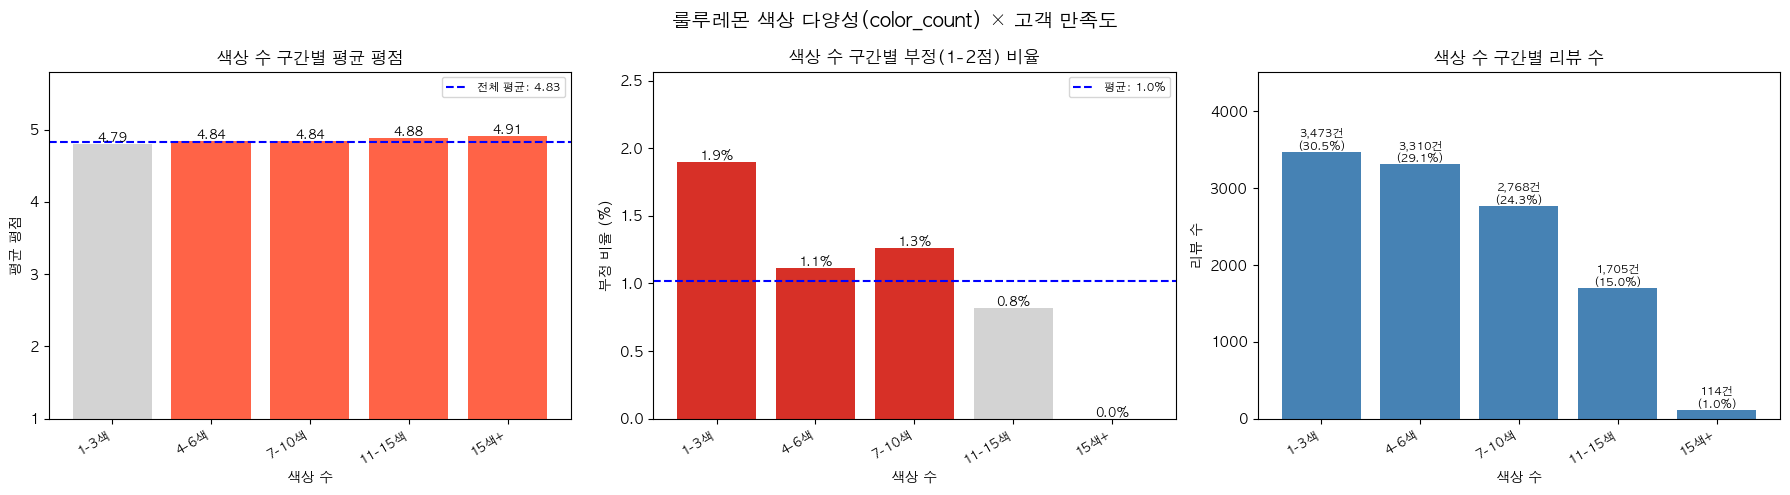

In [50]:
# ─────────────────────────────────────────────────────
# [13] 색상 다양성(color_count) × 만족도 분석
# → 색상 선택지가 많은 상품이 더 만족도 높은지 파악
# ─────────────────────────────────────────────────────

# color_count 구간 분류
df_lulu_review['color_band'] = pd.cut(
    df_lulu_review['color_count'],
    bins=[0, 3, 6, 10, 15, 100],
    labels=['1-3색', '4-6색', '7-10색', '11-15색', '15색+'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
overall_r = df_lulu_review['rating'].mean()

# ── (1) 색상 구간별 평균 평점 ─────────────────────────
cb_rating = df_lulu_review.groupby('color_band', observed=True)['rating'].mean()
colors    = ['tomato' if v >= overall_r else 'lightgray' for v in cb_rating.values]
bars      = axes[0].bar(cb_rating.index, cb_rating.values, color=colors)
axes[0].axhline(overall_r, color='blue', linestyle='--', linewidth=1.5,
                label=f'전체 평균: {overall_r:.2f}')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.2f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(1, 5.8)
axes[0].set_title('색상 수 구간별 평균 평점')
axes[0].set_xlabel('색상 수')
axes[0].set_ylabel('평균 평점')
axes[0].set_xticks(range(len(cb_rating)))
axes[0].set_xticklabels(cb_rating.index, rotation=30, ha='right', fontsize=9)
axes[0].legend(fontsize=8)

# ── (2) 색상 구간별 부정 비율 ─────────────────────────
cb_neg   = df_lulu_review.groupby('color_band', observed=True)['rating'].apply(
    lambda x: (x <= 2).mean() * 100)
mean_neg = cb_neg.mean()
colors2  = ['#d73027' if v >= mean_neg else 'lightgray' for v in cb_neg.values]
bars2    = axes[1].bar(cb_neg.index, cb_neg.values, color=colors2)
axes[1].axhline(mean_neg, color='blue', linestyle='--', linewidth=1.5,
                label=f'평균: {mean_neg:.1f}%')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, cb_neg.max() * 1.35)
axes[1].set_title('색상 수 구간별 부정(1-2점) 비율')
axes[1].set_xlabel('색상 수')
axes[1].set_ylabel('부정 비율 (%)')
axes[1].set_xticks(range(len(cb_neg)))
axes[1].set_xticklabels(cb_neg.index, rotation=30, ha='right', fontsize=9)
axes[1].legend(fontsize=8)

# ── (3) 색상 구간별 리뷰 수 ───────────────────────────
cb_cnt = df_lulu_review.groupby('color_band', observed=True).size()
bars3  = axes[2].bar(cb_cnt.index, cb_cnt.values, color='steelblue')
for bar in bars3:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, h,
                 f'{h:,}건\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[2].set_ylim(0, cb_cnt.max() * 1.3)
axes[2].set_title('색상 수 구간별 리뷰 수')
axes[2].set_xlabel('색상 수')
axes[2].set_ylabel('리뷰 수')
axes[2].set_xticks(range(len(cb_cnt)))
axes[2].set_xticklabels(cb_cnt.index, rotation=30, ha='right', fontsize=9)

plt.suptitle('룰루레몬 색상 다양성(color_count) × 고객 만족도', fontsize=14)
plt.tight_layout()
plt.show()

---
# 룰루레몬 가격 데이터

In [ ]:
# 데이터 로드
df_lulu_product = pd.read_csv("../data/final/lullu_product_info.csv", encoding='utf-8')
display(df_lulu_product.head())
display(df_lulu_product.info())

,collect_date,brand,product_id,product_name,cat1,cat2,cat3,gender,original_price,discount_price,color_count,raw_colors,review_count,is_new,is_best,is_wmtm
0,2026-04-20,룰루레몬,skakwz7iyb,"3D 자카드 페이즐리 트레인 하이라이즈 타이츠 25""",하의,레깅스,트레이닝,Women,169000,118000,1,페이즐리텍스처블랙,0,False,False,True
1,2026-04-21,룰루레몬,prod11870536,"ABC Warpstreme 풀온 쇼츠 7""",하의,반바지,일반,Men,125000,125000,2,"본, 윌로우리프",0,True,False,False
2,2026-04-20,룰루레몬,prod11700324,ABC Warpstreme 풀온 팬츠 *쇼터,하의,긴바지,일반,Men,184000,184000,4,"블랙, 옵시디언, 트루네이비, 와키카키",18,False,True,False
3,2026-04-20,룰루레몬,prod11870528,"ABC WovenAir 풀온 쇼츠 5""",하의,반바지,일반,Men,125000,125000,2,"블랙, 트루네이비",4,False,False,False
4,2026-04-20,룰루레몬,prod11870568,"ABC WovenAir 풀온 쇼츠 7""",하의,반바지,일반,Men,125000,125000,4,"블랙, 올리브브라운, 오닉스_그레이, 와키카키",5,False,False,True


<class 'pandas.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   collect_date    935 non-null    str  
 1   brand           935 non-null    str  
 2   product_id      935 non-null    str  
 3   product_name    935 non-null    str  
 4   cat1            933 non-null    str  
 5   cat2            933 non-null    str  
 6   cat3            935 non-null    str  
 7   gender          935 non-null    str  
 8   original_price  935 non-null    int64
 9   discount_price  935 non-null    int64
 10  color_count     935 non-null    int64
 11  raw_colors      935 non-null    str  
 12  review_count    935 non-null    int64
 13  is_new          935 non-null    bool 
 14  is_best         935 non-null    bool 
 15  is_wmtm         935 non-null    bool 
dtypes: bool(3), int64(4), str(9)
memory usage: 255.5 KB


None

---
# 클로드 자동 분석 - 상품 데이터

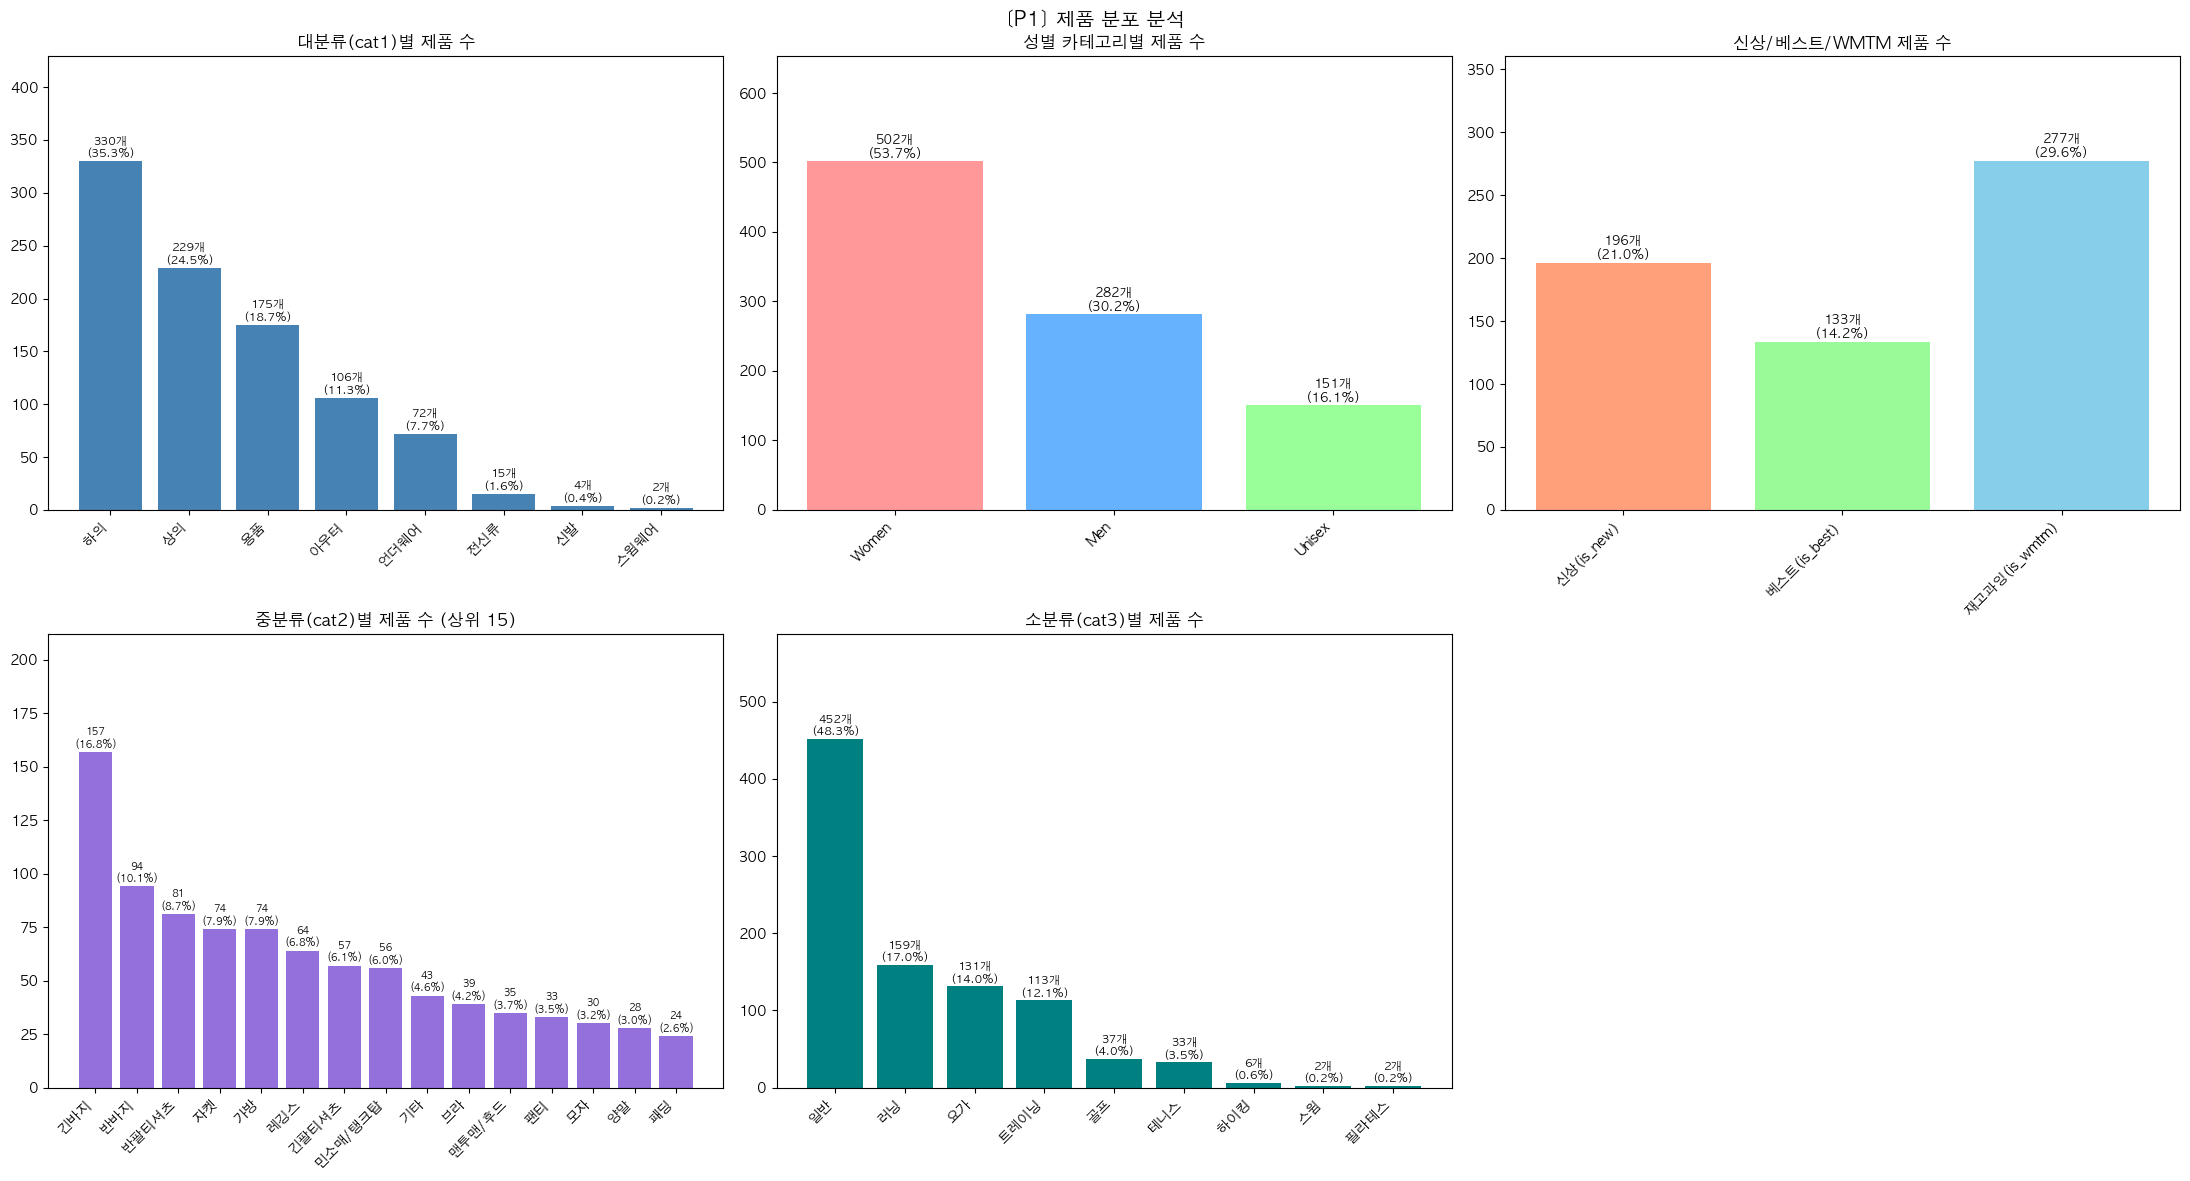

In [60]:
# ─────────────────────────────────────────────
# [P1] 제품 분포 분석
# → 대분류/중분류/소분류, 성별, 신상/베스트/WMTM 분포 확인
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('[P1] 제품 분포 분석', fontsize=14, fontweight='bold')
total = len(df_lulu_product)

# cat1별 제품 수
ax = axes[0, 0]
counts = df_lulu_product['cat1'].value_counts()
bars = ax.bar(counts.index, counts.values, color='steelblue')
ax.set_title('대분류(cat1)별 제품 수')
ax.set_xticklabels(counts.index, rotation=45, ha='right')
ax.set_ylim(0, counts.max() * 1.3)
for bar, h in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:,}개\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)

# gender별 제품 수
ax = axes[0, 1]
counts_g = df_lulu_product['gender'].value_counts()
bars = ax.bar(counts_g.index, counts_g.values, color=['#FF9999','#66B2FF','#99FF99'])
ax.set_title('성별 카테고리별 제품 수')
ax.set_xticklabels(counts_g.index, rotation=45, ha='right')
ax.set_ylim(0, counts_g.max() * 1.3)
for bar, h in zip(bars, counts_g.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:,}개\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# is_new / is_best / is_wmtm 제품 수
ax = axes[0, 2]
spec_lbls = ['신상(is_new)', '베스트(is_best)', '재고과잉(is_wmtm)']
spec_vals = [df_lulu_product['is_new'].sum(), df_lulu_product['is_best'].sum(), df_lulu_product['is_wmtm'].sum()]
bars = ax.bar(spec_lbls, spec_vals, color=['#FFA07A','#98FB98','#87CEEB'])
ax.set_title('신상/베스트/WMTM 제품 수')
ax.set_xticklabels(spec_lbls, rotation=45, ha='right')
ax.set_ylim(0, max(spec_vals) * 1.3)
for bar, h in zip(bars, spec_vals):
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:,}개\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# cat2 상위 15
ax = axes[1, 0]
counts_c2 = df_lulu_product['cat2'].value_counts().head(15)
bars = ax.bar(counts_c2.index, counts_c2.values, color='mediumpurple')
ax.set_title('중분류(cat2)별 제품 수 (상위 15)')
ax.set_xticklabels(counts_c2.index, rotation=45, ha='right')
ax.set_ylim(0, counts_c2.max() * 1.35)
for bar, h in zip(bars, counts_c2.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+1,
            f'{h:,}\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=7)

# cat3별 제품 수 (전체)
ax = axes[1, 1]
counts_c3 = df_lulu_product['cat3'].value_counts()
bars = ax.bar(counts_c3.index, counts_c3.values, color='teal')
ax.set_title('소분류(cat3)별 제품 수')
ax.set_xticklabels(counts_c3.index, rotation=45, ha='right')
ax.set_ylim(0, counts_c3.max() * 1.3)
for bar, h in zip(bars, counts_c3.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:,}개\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

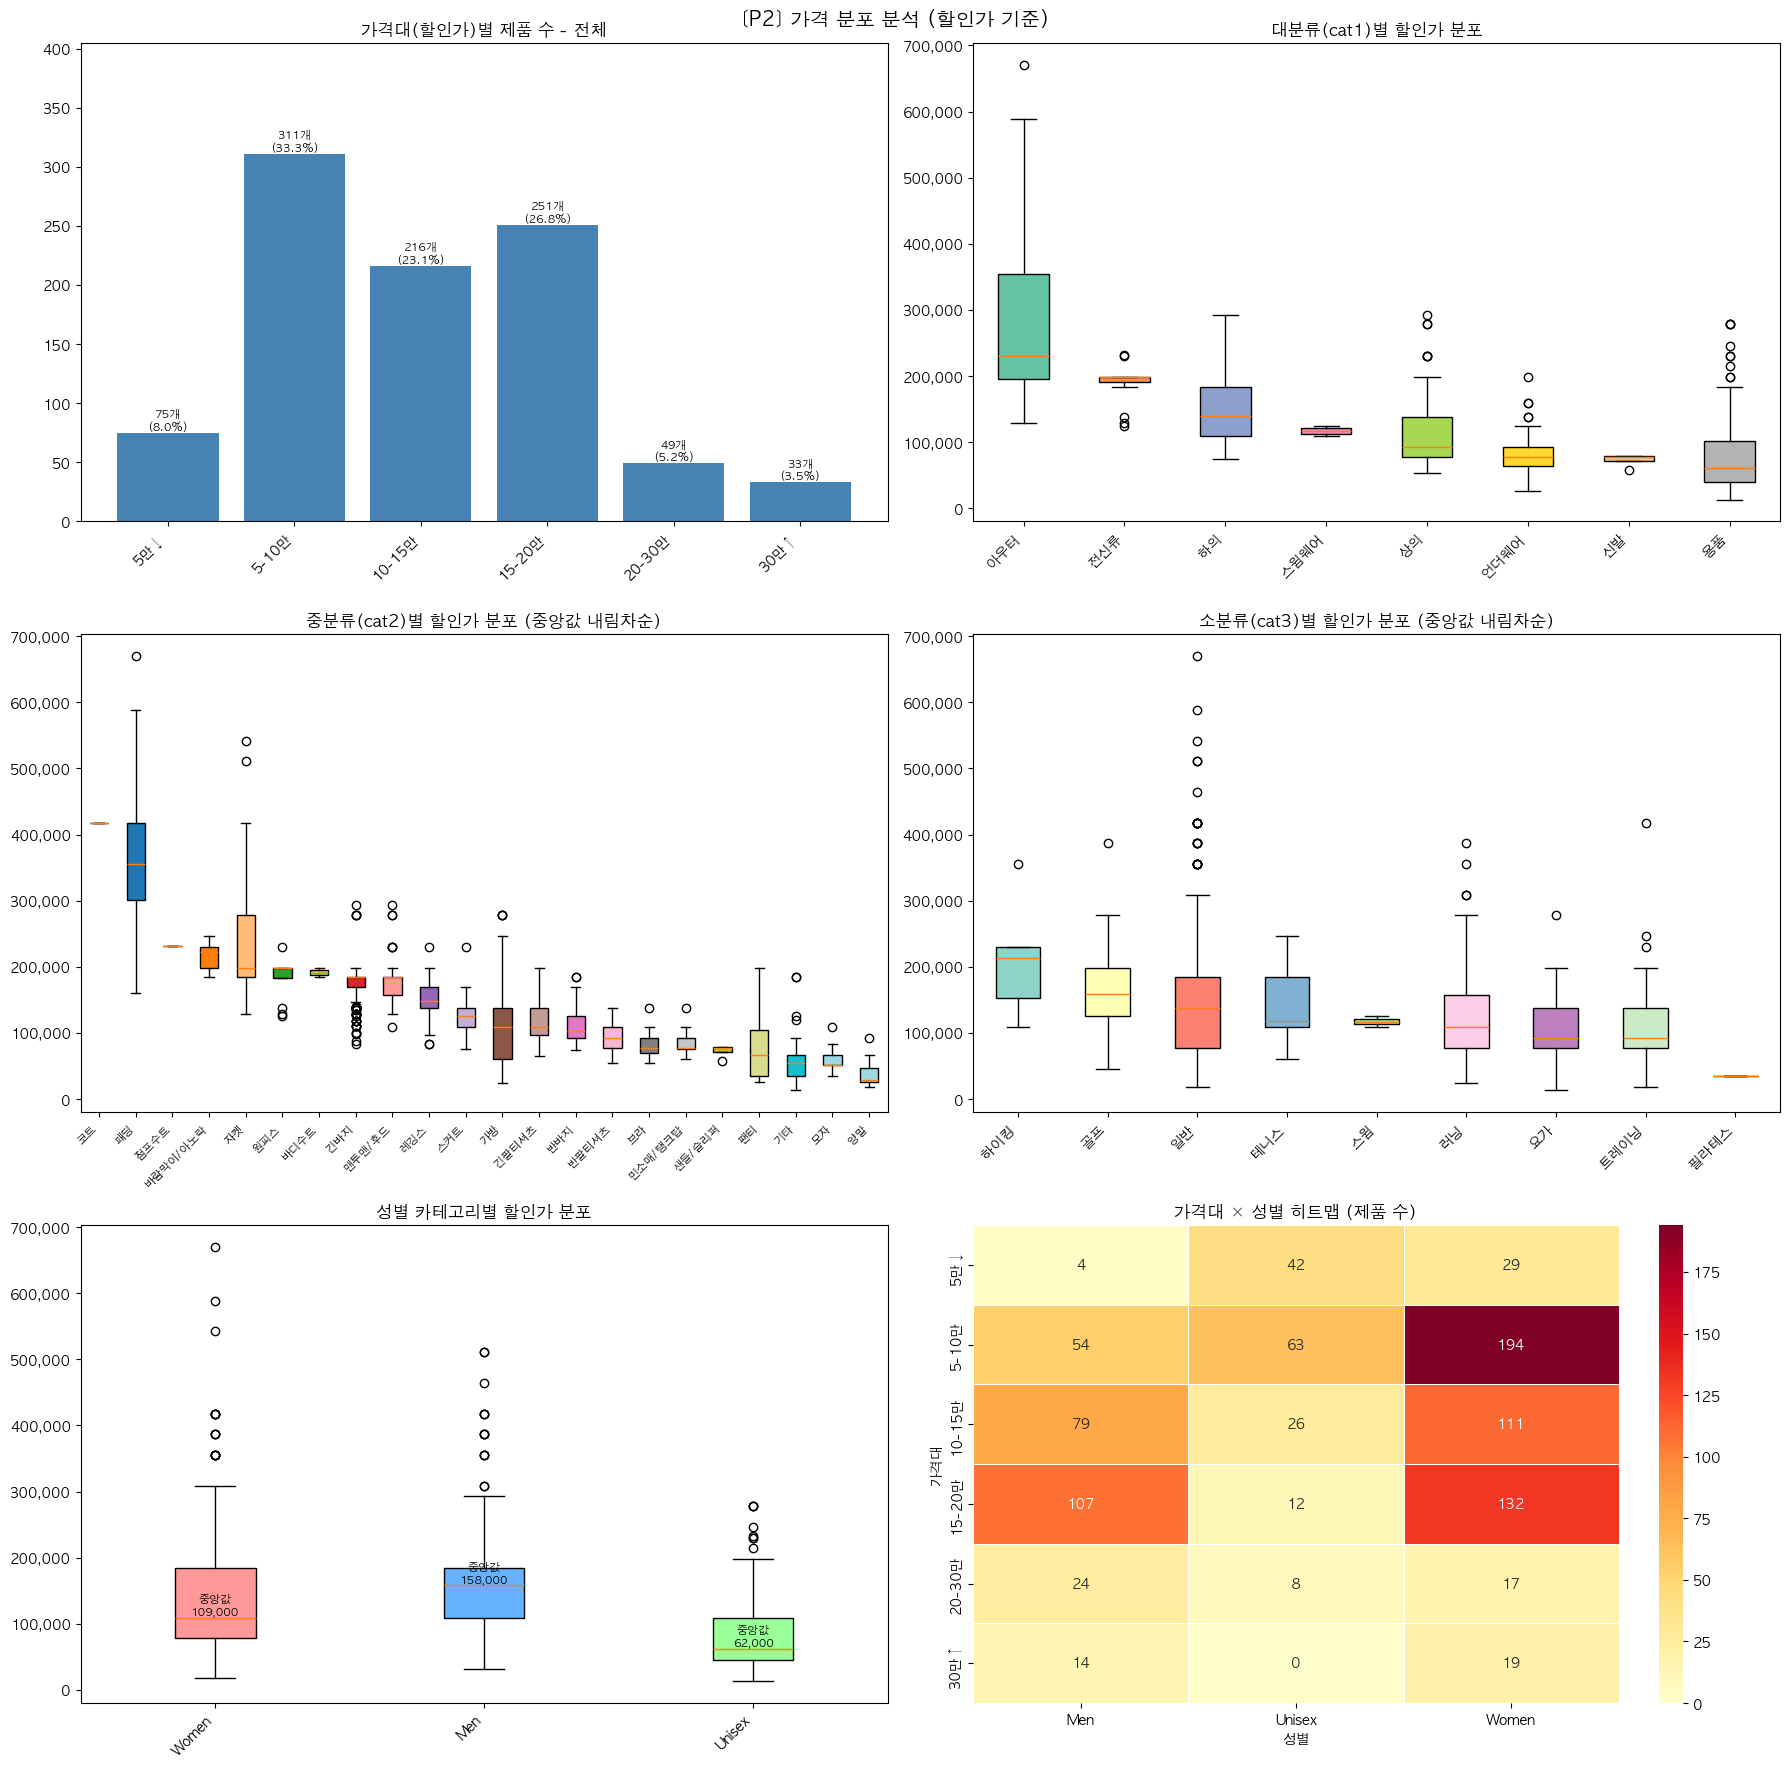

In [61]:
# ─────────────────────────────────────────────
# [P2] 가격 분포 분석
# → 가격대 구간별 전체 분포 + cat1/cat2/cat3/gender별 분포
# ─────────────────────────────────────────────
import seaborn as sns

# 할인가 기준 가격대 구간
price_bins = [0, 50000, 100000, 150000, 200000, 300000, float('inf')]
price_lbls = ['5만↓','5-10만','10-15만','15-20만','20-30만','30만↑']
df_lulu_product['price_band'] = pd.cut(
    df_lulu_product['discount_price'], bins=price_bins, labels=price_lbls)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('[P2] 가격 분포 분석 (할인가 기준)', fontsize=14, fontweight='bold')
total = len(df_lulu_product)

# 가격대별 전체 제품 수
ax = axes[0, 0]
counts_pb = df_lulu_product['price_band'].value_counts().reindex(price_lbls)
bars = ax.bar(price_lbls, counts_pb.values, color='steelblue')
ax.set_title('가격대(할인가)별 제품 수 - 전체')
ax.set_xticklabels(price_lbls, rotation=45, ha='right')
ax.set_ylim(0, counts_pb.max() * 1.3)
for bar, h in zip(bars, counts_pb.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+1,
            f'{h:,}개\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=8)

# cat1별 할인가 박스플롯
ax = axes[0, 1]
cat1_order = (df_lulu_product.groupby('cat1')['discount_price']
              .median().sort_values(ascending=False).index)
data_bp = [df_lulu_product[df_lulu_product['cat1']==c]['discount_price'].dropna() for c in cat1_order]
bp = ax.boxplot(data_bp, labels=cat1_order, patch_artist=True)
for patch, c in zip(bp['boxes'], plt.cm.Set2(np.linspace(0,1,len(cat1_order)))):
    patch.set_facecolor(c)
ax.set_title('대분류(cat1)별 할인가 분포')
ax.set_xticklabels(cat1_order, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# cat2별 할인가 박스플롯 (중앙값 기준 정렬)
ax = axes[1, 0]
cat2_order = (df_lulu_product.groupby('cat2')['discount_price']
              .median().sort_values(ascending=False).index)
data_c2 = [df_lulu_product[df_lulu_product['cat2']==c]['discount_price'].dropna() for c in cat2_order]
bp2 = ax.boxplot(data_c2, labels=cat2_order, patch_artist=True)
colors_c2 = plt.cm.tab20(np.linspace(0,1,len(cat2_order)))
for patch, c in zip(bp2['boxes'], colors_c2):
    patch.set_facecolor(c)
ax.set_title('중분류(cat2)별 할인가 분포 (중앙값 내림차순)')
ax.set_xticklabels(cat2_order, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# cat3별 할인가 박스플롯
ax = axes[1, 1]
cat3_order = (df_lulu_product.groupby('cat3')['discount_price']
              .median().sort_values(ascending=False).index)
data_c3 = [df_lulu_product[df_lulu_product['cat3']==c]['discount_price'].dropna() for c in cat3_order]
bp3 = ax.boxplot(data_c3, labels=cat3_order, patch_artist=True)
colors_c3 = plt.cm.Set3(np.linspace(0,1,len(cat3_order)))
for patch, c in zip(bp3['boxes'], colors_c3):
    patch.set_facecolor(c)
ax.set_title('소분류(cat3)별 할인가 분포 (중앙값 내림차순)')
ax.set_xticklabels(cat3_order, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# gender별 할인가 박스플롯
ax = axes[2, 0]
genders = ['Women', 'Men', 'Unisex']
data_g  = [df_lulu_product[df_lulu_product['gender']==g]['discount_price'].dropna() for g in genders]
bp4 = ax.boxplot(data_g, labels=genders, patch_artist=True)
for patch, c in zip(bp4['boxes'], ['#FF9999','#66B2FF','#99FF99']):
    patch.set_facecolor(c)
ax.set_title('성별 카테고리별 할인가 분포')
ax.set_xticklabels(genders, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, g in enumerate(genders):
    med = df_lulu_product[df_lulu_product['gender']==g]['discount_price'].median()
    ax.text(i+1, med+1000, f'중앙값\n{med:,.0f}', ha='center', va='bottom', fontsize=8)

# 가격대 × gender 히트맵
ax = axes[2, 1]
ct = pd.crosstab(df_lulu_product['price_band'], df_lulu_product['gender']).reindex(price_lbls).fillna(0)
sns.heatmap(ct, annot=True, fmt='g', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('가격대 × 성별 히트맵 (제품 수)')
ax.set_xlabel('성별'); ax.set_ylabel('가격대')

plt.tight_layout()
plt.show()

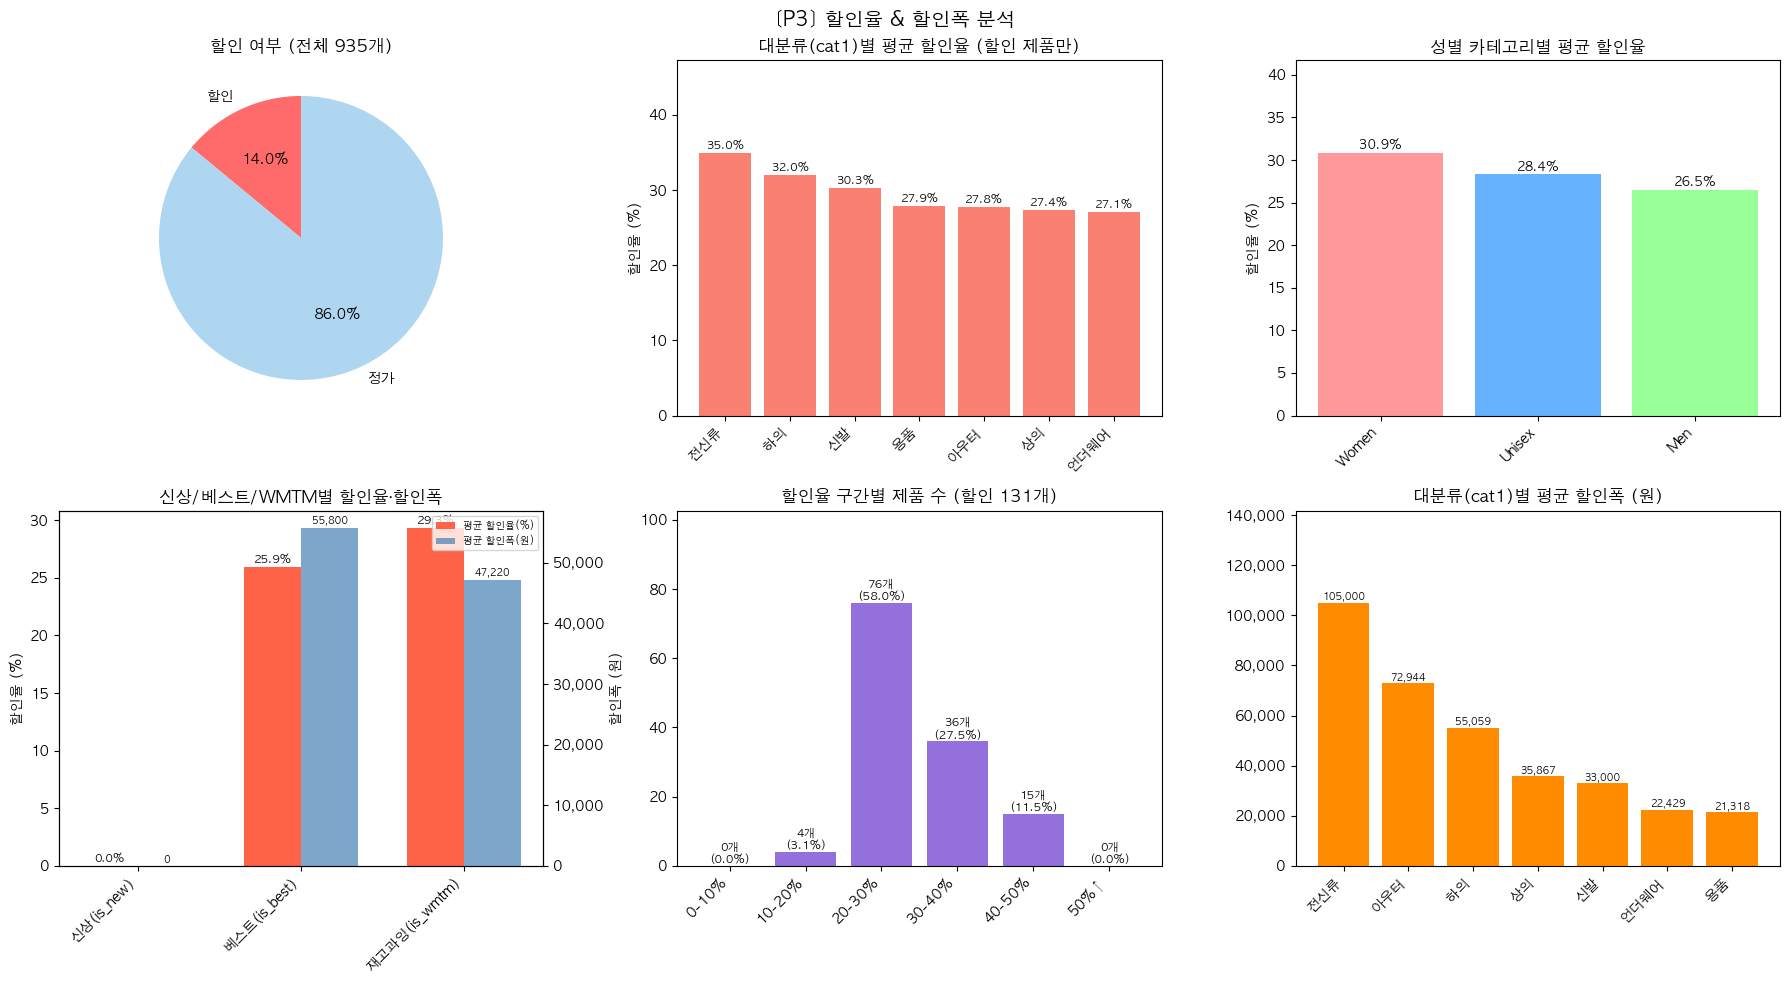

In [62]:
# ─────────────────────────────────────────────
# [P3] 할인율 & 할인폭 분석
# → 파생 컬럼 생성 후 카테고리/성별/신상/베스트/WMTM별 할인 특성 분석
# ─────────────────────────────────────────────

# 파생 컬럼
df_lulu_product['has_discount'] = df_lulu_product['discount_price'] < df_lulu_product['original_price']
df_lulu_product['discount_rate'] = (
    (df_lulu_product['original_price'] - df_lulu_product['discount_price'])
    / df_lulu_product['original_price'] * 100).round(1)
df_lulu_product['discount_amt'] = df_lulu_product['original_price'] - df_lulu_product['discount_price']
disc = df_lulu_product[df_lulu_product['has_discount']].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('[P3] 할인율 & 할인폭 분석', fontsize=14, fontweight='bold')
total = len(df_lulu_product)

# 할인 여부 파이
ax = axes[0, 0]
disc_cnt = df_lulu_product['has_discount'].sum()
ax.pie([disc_cnt, total-disc_cnt], labels=['할인','정가'],
       colors=['#FF6B6B','#AED6F1'], autopct='%1.1f%%', startangle=90)
ax.set_title(f'할인 여부 (전체 {total:,}개)')

# cat1별 평균 할인율
ax = axes[0, 1]
cat1_disc = disc.groupby('cat1')['discount_rate'].mean().sort_values(ascending=False)
bars = ax.bar(cat1_disc.index, cat1_disc.values, color='salmon')
ax.set_title('대분류(cat1)별 평균 할인율 (할인 제품만)')
ax.set_xticklabels(cat1_disc.index, rotation=45, ha='right')
ax.set_ylim(0, cat1_disc.max() * 1.35)
ax.set_ylabel('할인율 (%)')
for bar, h in zip(bars, cat1_disc.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

# gender별 평균 할인율
ax = axes[0, 2]
g_disc = disc.groupby('gender')['discount_rate'].mean().sort_values(ascending=False)
gc = ['#FF9999','#66B2FF','#99FF99'][:len(g_disc)]
bars = ax.bar(g_disc.index, g_disc.values, color=gc)
ax.set_title('성별 카테고리별 평균 할인율')
ax.set_xticklabels(g_disc.index, rotation=45, ha='right')
ax.set_ylim(0, g_disc.max() * 1.35)
ax.set_ylabel('할인율 (%)')
for bar, h in zip(bars, g_disc.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

# 신상/베스트/WMTM별 할인율·할인폭 (이중축)
ax = axes[1, 0]
grp_lbls = ['신상(is_new)', '베스트(is_best)', '재고과잉(is_wmtm)']
grp_cols = ['is_new','is_best','is_wmtm']
rates = [disc[disc[c]]['discount_rate'].mean() if disc[c].sum()>0 else 0 for c in grp_cols]
amts  = [disc[disc[c]]['discount_amt'].mean()  if disc[c].sum()>0 else 0 for c in grp_cols]
x = np.arange(len(grp_lbls)); w = 0.35
b1 = ax.bar(x-w/2, rates, w, label='평균 할인율(%)', color='tomato')
ax2r = ax.twinx()
b2 = ax2r.bar(x+w/2, amts, w, label='평균 할인폭(원)', color='steelblue', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(grp_lbls, rotation=45, ha='right')
ax.set_title('신상/베스트/WMTM별 할인율·할인폭')
ax.set_ylabel('할인율 (%)'); ax2r.set_ylabel('할인폭 (원)')
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
lns = ax.get_legend_handles_labels(); lns2 = ax2r.get_legend_handles_labels()
ax.legend(lns[0]+lns2[0], lns[1]+lns2[1], loc='upper right', fontsize=7)
for b, h in zip(b1, rates):
    ax.text(b.get_x()+b.get_width()/2, h+0.1, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
for b, h in zip(b2, amts):
    ax2r.text(b.get_x()+b.get_width()/2, h+200, f'{h:,.0f}', ha='center', va='bottom', fontsize=7)

# 할인율 구간별 제품 수
ax = axes[1, 1]
disc_bins = [0,10,20,30,40,50,100]
disc_bnd_lbls = ['0-10%','10-20%','20-30%','30-40%','40-50%','50%↑']
disc['disc_band'] = pd.cut(disc['discount_rate'], bins=disc_bins, labels=disc_bnd_lbls)
counts_db = disc['disc_band'].value_counts().reindex(disc_bnd_lbls).fillna(0)
total_disc = len(disc)
bars = ax.bar(disc_bnd_lbls, counts_db.values, color='mediumpurple')
ax.set_title(f'할인율 구간별 제품 수 (할인 {total_disc:,}개)')
ax.set_xticklabels(disc_bnd_lbls, rotation=45, ha='right')
ax.set_ylim(0, counts_db.max() * 1.35)
for bar, h in zip(bars, counts_db.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+0.2,
            f'{int(h):,}개\n({h/total_disc*100:.1f}%)', ha='center', va='bottom', fontsize=8)

# cat1별 평균 할인폭
ax = axes[1, 2]
cat1_amt = disc.groupby('cat1')['discount_amt'].mean().sort_values(ascending=False)
bars = ax.bar(cat1_amt.index, cat1_amt.values, color='darkorange')
ax.set_title('대분류(cat1)별 평균 할인폭 (원)')
ax.set_xticklabels(cat1_amt.index, rotation=45, ha='right')
ax.set_ylim(0, cat1_amt.max() * 1.35)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, h in zip(bars, cat1_amt.values):
    ax.text(bar.get_x()+bar.get_width()/2, h+200, f'{h:,.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

전체 상품: 935개 / 리뷰 매칭: 587개


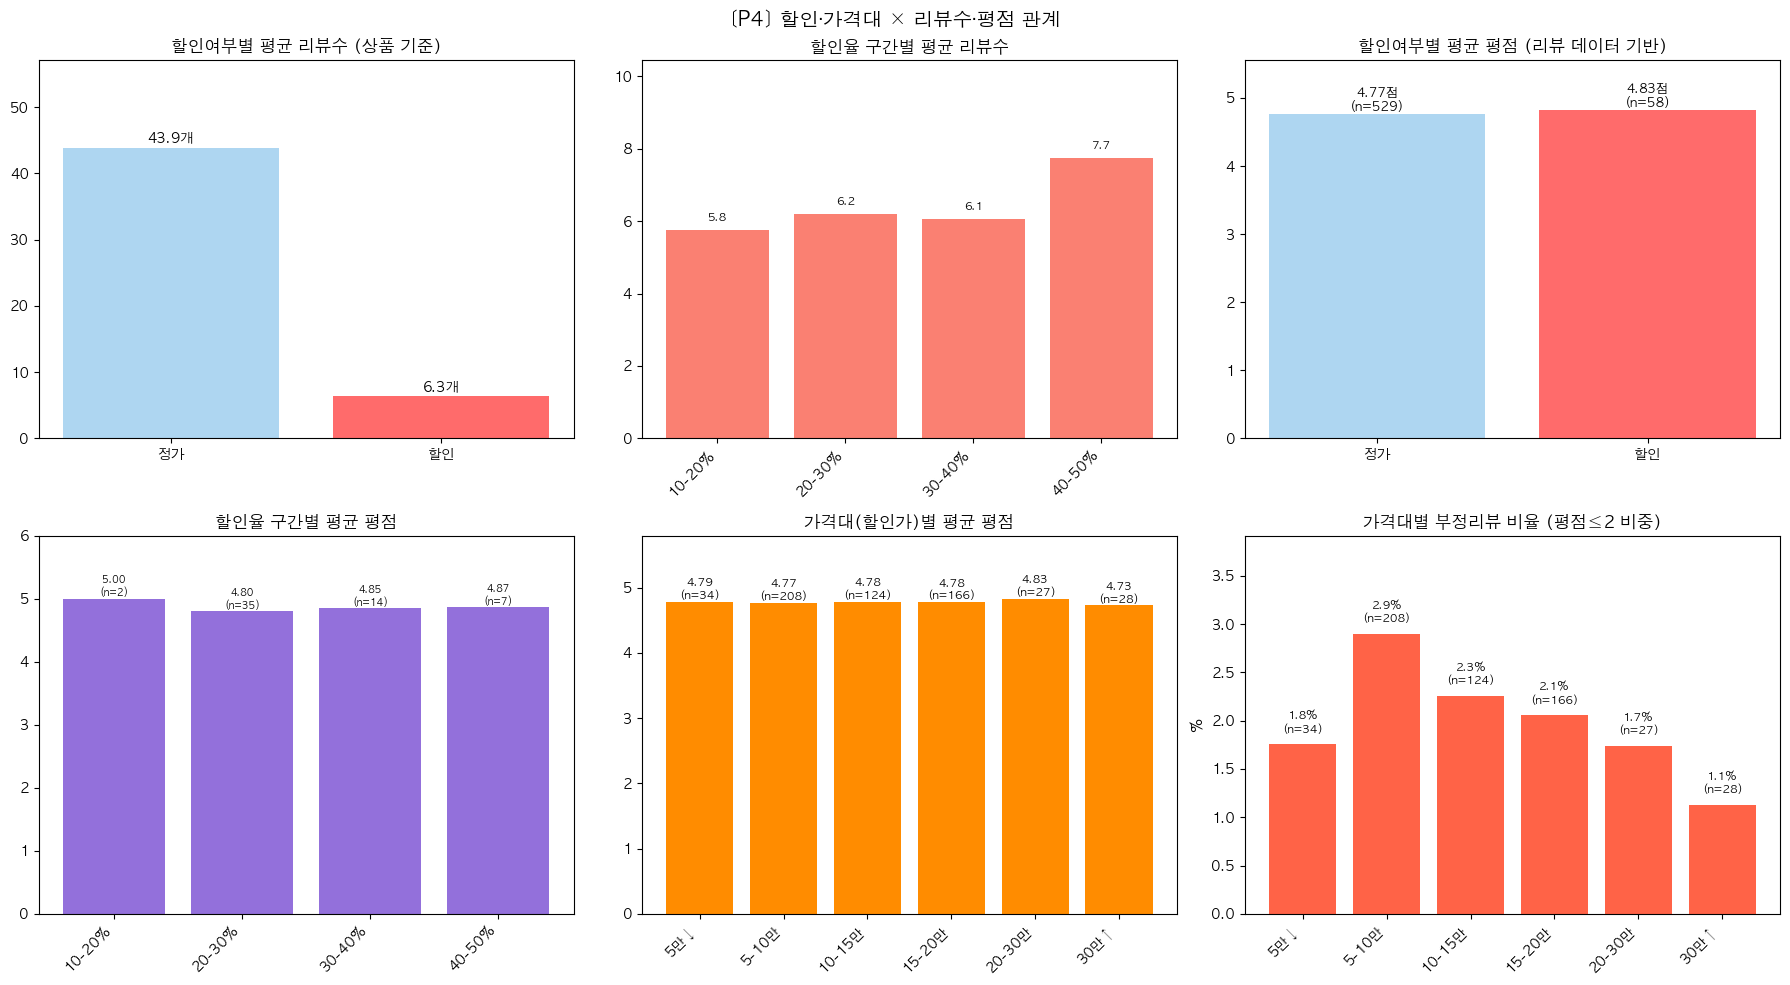

In [63]:
# ─────────────────────────────────────────────
# [P4] 할인·가격대 × 리뷰수·평점 관계
# → df_lulu_review와 product_id로 merge 후 분석
# ─────────────────────────────────────────────

# product_id별 리뷰 평균평점·리뷰수 집계
rating_by_prod = (df_lulu_review.groupby('product_id')['rating']
                  .agg(['mean','count']).reset_index())
rating_by_prod.columns = ['product_id','avg_rating','rev_cnt']

# 상품 데이터에 merge
df_pr = df_lulu_product.merge(rating_by_prod, on='product_id', how='left')
df_pr_has = df_pr.dropna(subset=['avg_rating'])  # 리뷰 있는 제품만
print(f'전체 상품: {len(df_lulu_product):,}개 / 리뷰 매칭: {len(df_pr_has):,}개')

price_lbls = ['5만↓','5-10만','10-15만','15-20만','20-30만','30만↑']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('[P4] 할인·가격대 × 리뷰수·평점 관계', fontsize=14, fontweight='bold')

# 할인여부 × 평균 리뷰수 (product.review_count 기준)
ax = axes[0, 0]
grp = df_pr.groupby('has_discount')['review_count'].mean()
vals = [grp.get(False,0), grp.get(True,0)]
bars = ax.bar(['정가','할인'], vals, color=['#AED6F1','#FF6B6B'])
ax.set_title('할인여부별 평균 리뷰수 (상품 기준)')
ax.set_ylim(0, max(vals) * 1.3)
for bar, h in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}개', ha='center', va='bottom', fontsize=10)

# 할인율 구간 × 평균 리뷰수
ax = axes[0, 1]
disc_bnd_lbls = ['0-10%','10-20%','20-30%','30-40%','40-50%','50%↑']
disc4 = df_pr[df_pr['has_discount']].copy()
disc4['disc_band'] = pd.cut(disc4['discount_rate'], bins=[0,10,20,30,40,50,100], labels=disc_bnd_lbls)
grp2 = disc4.groupby('disc_band', observed=True)['review_count'].mean().reindex(disc_bnd_lbls)
bars = ax.bar(disc_bnd_lbls, grp2.values, color='salmon')
ax.set_title('할인율 구간별 평균 리뷰수')
ax.set_xticklabels(disc_bnd_lbls, rotation=45, ha='right')
ax.set_ylim(0, grp2.max() * 1.35 if grp2.max() > 0 else 10)
for bar, h in zip(bars, grp2.values):
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

# 할인여부 × 평균 평점 (리뷰 데이터 기반)
ax = axes[0, 2]
grp3  = df_pr_has.groupby('has_discount')['avg_rating'].mean()
cnt3  = df_pr_has.groupby('has_discount').size()
vals3 = [grp3.get(False,0), grp3.get(True,0)]
cnts3 = [cnt3.get(False,0), cnt3.get(True,0)]
bars  = ax.bar(['정가','할인'], vals3, color=['#AED6F1','#FF6B6B'])
ax.set_title('할인여부별 평균 평점 (리뷰 데이터 기반)')
ax.set_ylim(0, max(vals3) * 1.15)
for bar, h, n in zip(bars, vals3, cnts3):
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
            f'{h:.2f}점\n(n={n:,})', ha='center', va='bottom', fontsize=9)

# 할인율 구간 × 평균 평점
ax = axes[1, 0]
disc5 = df_pr_has[df_pr_has['has_discount']].copy()
disc5['disc_band'] = pd.cut(disc5['discount_rate'], bins=[0,10,20,30,40,50,100], labels=disc_bnd_lbls)
grp4 = disc5.groupby('disc_band', observed=True)['avg_rating'].mean().reindex(disc_bnd_lbls)
cnt4 = disc5.groupby('disc_band', observed=True).size().reindex(disc_bnd_lbls).fillna(0)
bars = ax.bar(disc_bnd_lbls, grp4.values, color='mediumpurple')
ax.set_title('할인율 구간별 평균 평점')
ax.set_xticklabels(disc_bnd_lbls, rotation=45, ha='right')
mx = grp4.dropna().max()
ax.set_ylim(0, mx * 1.2 if mx > 0 else 5)
for bar, h, n in zip(bars, grp4.values, cnt4.values):
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.2f}\n(n={int(n)})', ha='center', va='bottom', fontsize=7)

# 가격대별 평균 평점
ax = axes[1, 1]
grp5 = df_pr_has.groupby('price_band', observed=True)['avg_rating'].mean().reindex(price_lbls)
cnt5 = df_pr_has.groupby('price_band', observed=True).size().reindex(price_lbls).fillna(0)
bars = ax.bar(price_lbls, grp5.values, color='darkorange')
ax.set_title('가격대(할인가)별 평균 평점')
ax.set_xticklabels(price_lbls, rotation=45, ha='right')
mx5 = grp5.dropna().max()
ax.set_ylim(0, mx5 * 1.2 if mx5 > 0 else 5)
for bar, h, n in zip(bars, grp5.values, cnt5.values):
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.2f}\n(n={int(n)})', ha='center', va='bottom', fontsize=8)

# 가격대별 부정리뷰 비율 (평점≤2)
ax = axes[1, 2]
neg_by_prod = (df_lulu_review.groupby('product_id')
               .apply(lambda x: (x['rating']<=2).mean()*100)
               .reset_index(name='neg_pct'))
df_pr_neg = df_lulu_product.merge(neg_by_prod, on='product_id', how='left').dropna(subset=['neg_pct'])
grp6 = df_pr_neg.groupby('price_band', observed=True)['neg_pct'].mean().reindex(price_lbls)
cnt6 = df_pr_neg.groupby('price_band', observed=True).size().reindex(price_lbls).fillna(0)
bars = ax.bar(price_lbls, grp6.values, color='tomato')
ax.set_title('가격대별 부정리뷰 비율 (평점≤2 비중)')
ax.set_xticklabels(price_lbls, rotation=45, ha='right')
ax.set_ylabel('%')
mx6 = grp6.dropna().max()
ax.set_ylim(0, mx6 * 1.35 if mx6 > 0 else 10)
for bar, h, n in zip(bars, grp6.values, cnt6.values):
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.1,
                f'{h:.1f}%\n(n={int(n)})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

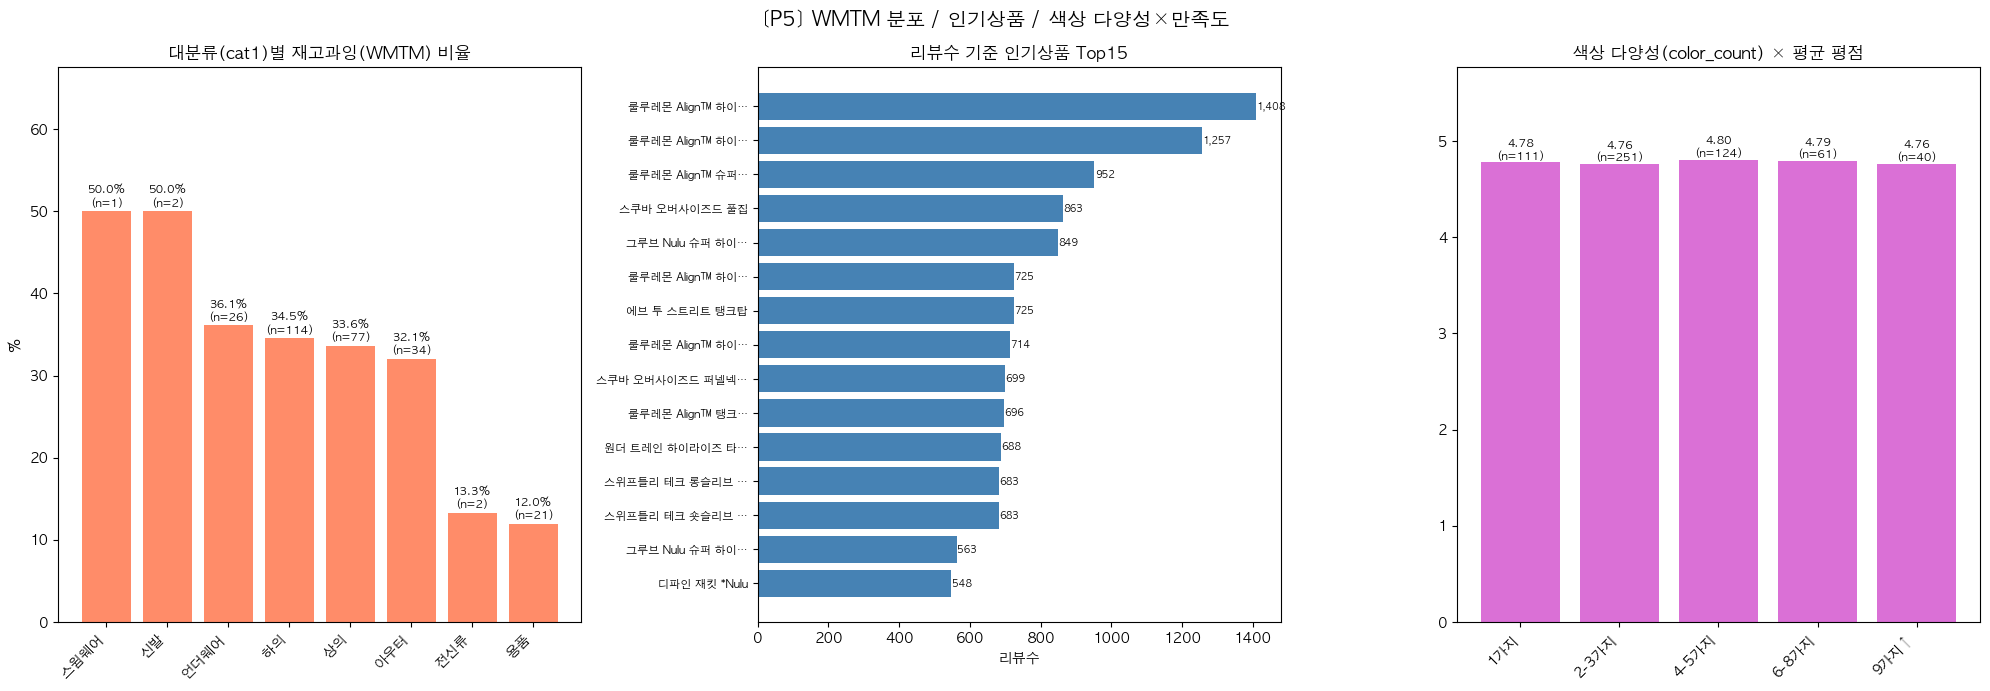

In [58]:
# ─────────────────────────────────────────────
# [P5] WMTM 분포 / 인기상품 Top15 / 색상 다양성×만족도
# → 재고 과잉 현황, 리뷰수 기준 인기 상품, 색상 수 vs 평점
# ─────────────────────────────────────────────

# df_pr 없으면 재생성
if 'df_pr' not in dir():
    rating_by_prod = (df_lulu_review.groupby('product_id')['rating']
                      .agg(['mean','count']).reset_index())
    rating_by_prod.columns = ['product_id','avg_rating','rev_cnt']
    df_pr = df_lulu_product.merge(rating_by_prod, on='product_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('[P5] WMTM 분포 / 인기상품 / 색상 다양성×만족도', fontsize=14, fontweight='bold')

# cat1별 WMTM 비율
ax = axes[0]
wmtm = df_lulu_product.groupby('cat1')['is_wmtm'].agg(['sum','count'])
wmtm['pct'] = wmtm['sum'] / wmtm['count'] * 100
wmtm = wmtm.sort_values('pct', ascending=False)
bars = ax.bar(wmtm.index, wmtm['pct'], color='#FF8C69')
ax.set_title('대분류(cat1)별 재고과잉(WMTM) 비율')
ax.set_xticklabels(wmtm.index, rotation=45, ha='right')
ax.set_ylim(0, wmtm['pct'].max() * 1.35)
ax.set_ylabel('%')
for bar, (_, row) in zip(bars, wmtm.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, row['pct']+0.3,
            f'{row["pct"]:.1f}%\n(n={int(row["sum"])})', ha='center', va='bottom', fontsize=8)

# 인기상품 Top15 (review_count 기준)
ax = axes[1]
top15 = df_lulu_product.nlargest(15, 'review_count')
short = [n[:14]+'…' if len(n)>14 else n for n in top15['product_name']]
bars = ax.barh(range(15), top15['review_count'].values, color='steelblue')
ax.set_yticks(range(15)); ax.set_yticklabels(short, fontsize=8)
ax.invert_yaxis()
ax.set_title('리뷰수 기준 인기상품 Top15')
ax.set_xlabel('리뷰수')
for bar, h in zip(bars, top15['review_count'].values):
    ax.text(h+1, bar.get_y()+bar.get_height()/2, f'{h:,}', va='center', fontsize=7)

# 색상 수 구간 × 평균 평점
ax = axes[2]
color_bins = [0,1,3,5,8,100]
color_lbls = ['1가지','2-3가지','4-5가지','6-8가지','9가지↑']
df_pr['color_band'] = pd.cut(df_pr['color_count'], bins=color_bins, labels=color_lbls)
cgrp = (df_pr.dropna(subset=['avg_rating'])
        .groupby('color_band', observed=True)['avg_rating']
        .agg(['mean','count']).reindex(color_lbls))
bars = ax.bar(color_lbls, cgrp['mean'], color='orchid')
ax.set_title('색상 다양성(color_count) × 평균 평점')
ax.set_xticklabels(color_lbls, rotation=45, ha='right')
mx = cgrp['mean'].dropna().max()
ax.set_ylim(0, mx * 1.2 if mx > 0 else 5)
for bar, (_, row) in zip(bars, cgrp.iterrows()):
    if not np.isnan(row['mean']):
        ax.text(bar.get_x()+bar.get_width()/2, row['mean']+0.01,
                f'{row["mean"]:.2f}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

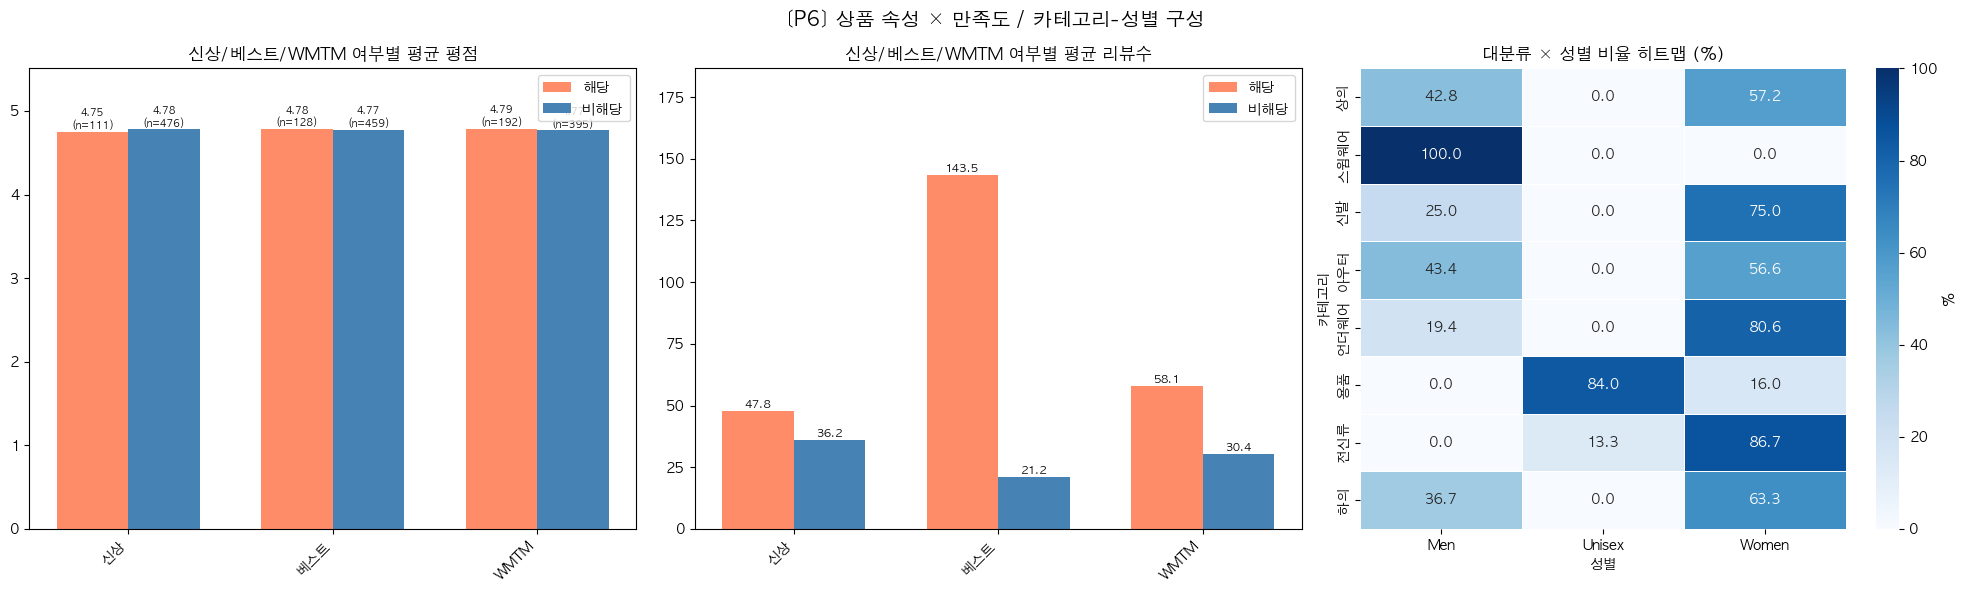

In [59]:
# ─────────────────────────────────────────────
# [P6] 상품 속성 × 평점·리뷰수 비교 / cat1×gender 크로스탭
# → 신상·베스트·WMTM 상품의 만족도 차이, 카테고리-성별 구성 파악
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('[P6] 상품 속성 × 만족도 / 카테고리-성별 구성', fontsize=14, fontweight='bold')

# 신상/베스트/WMTM별 평균 평점 (각 True vs False)
ax = axes[0]
cols_spec = ['is_new','is_best','is_wmtm']
lbls_spec = ['신상', '베스트', 'WMTM']
true_vals  = [df_pr[df_pr[c]]['avg_rating'].mean() for c in cols_spec]
false_vals = [df_pr[~df_pr[c]]['avg_rating'].mean() for c in cols_spec]
true_cnts  = [df_pr[df_pr[c]]['avg_rating'].notna().sum() for c in cols_spec]
false_cnts = [df_pr[~df_pr[c]]['avg_rating'].notna().sum() for c in cols_spec]
x = np.arange(len(lbls_spec)); w = 0.35
b1 = ax.bar(x-w/2, true_vals,  w, label='해당', color='#FF8C69')
b2 = ax.bar(x+w/2, false_vals, w, label='비해당', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(lbls_spec, rotation=45, ha='right')
ax.set_title('신상/베스트/WMTM 여부별 평균 평점')
ax.set_ylim(0, max(true_vals+false_vals) * 1.15)
ax.legend()
for b, h, n in zip(b1, true_vals, true_cnts):
    if not np.isnan(h):
        ax.text(b.get_x()+b.get_width()/2, h+0.01, f'{h:.2f}\n(n={n})', ha='center', va='bottom', fontsize=7)
for b, h, n in zip(b2, false_vals, false_cnts):
    if not np.isnan(h):
        ax.text(b.get_x()+b.get_width()/2, h+0.01, f'{h:.2f}\n(n={n})', ha='center', va='bottom', fontsize=7)

# 신상/베스트/WMTM별 평균 리뷰수 비교
ax = axes[1]
true_rc  = [df_lulu_product[df_lulu_product[c]]['review_count'].mean() for c in cols_spec]
false_rc = [df_lulu_product[~df_lulu_product[c]]['review_count'].mean() for c in cols_spec]
b1 = ax.bar(x-w/2, true_rc,  w, label='해당', color='#FF8C69')
b2 = ax.bar(x+w/2, false_rc, w, label='비해당', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(lbls_spec, rotation=45, ha='right')
ax.set_title('신상/베스트/WMTM 여부별 평균 리뷰수')
ax.set_ylim(0, max(true_rc+false_rc) * 1.3)
ax.legend()
for b, h in zip(b1, true_rc):
    ax.text(b.get_x()+b.get_width()/2, h+0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=8)
for b, h in zip(b2, false_rc):
    ax.text(b.get_x()+b.get_width()/2, h+0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

# cat1 × gender 크로스탭 히트맵
ax = axes[2]
ct = pd.crosstab(df_lulu_product['cat1'], df_lulu_product['gender'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax, linewidths=0.5,
            cbar_kws={'label': '%'})
ax.set_title('대분류 × 성별 비율 히트맵 (%)')
ax.set_xlabel('성별'); ax.set_ylabel('카테고리')

plt.tight_layout()
plt.show()